# Phase 4 — Baseline Model

## Objective

The objective of Phase 4 is to establish a reliable baseline machine learning model for predicting payment difficulties using the `application_train` dataset as the primary modeling dataset.

The baseline phase focuses on understanding the modeling dataset, performing exploratory data analysis, identifying data-quality issues, cleaning and preprocessing the data, handling missing values, building a baseline model, and evaluating its performance.

The baseline model will provide a benchmark against which the feature-engineered models developed in later phases can be compared.

### Phase 4 Workflow

1. Load and inspect the `application_train` dataset
2. Perform initial data quality assessment
3. Analyze the target variable
4. Identify missing values
5. Perform exploratory data analysis
6. Identify invalid values and potential outliers
7. Clean and preprocess the data
8. Handle missing values
9. Build a baseline machine learning model
10. Evaluate model performance
11. Document baseline findings and limitations

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
application_df=pd.read_csv(r'C:\Users\HomePC\Desktop\home_credit_dataset\application_train.csv')

In [3]:
application_df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
application_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [5]:
application_df.shape

(307511, 122)

In [6]:
application_df.isnull().sum()

SK_ID_CURR                        0
TARGET                            0
NAME_CONTRACT_TYPE                0
CODE_GENDER                       0
FLAG_OWN_CAR                      0
                              ...  
AMT_REQ_CREDIT_BUREAU_DAY     41519
AMT_REQ_CREDIT_BUREAU_WEEK    41519
AMT_REQ_CREDIT_BUREAU_MON     41519
AMT_REQ_CREDIT_BUREAU_QRT     41519
AMT_REQ_CREDIT_BUREAU_YEAR    41519
Length: 122, dtype: int64

## 1. Dataset Overview

The `application_train` dataset is used as the primary modeling dataset for the baseline model.

The dataset contains **307,511 observations and 122 columns**. It includes applicant-level information such as demographic characteristics, financial information, employment details, credit-related variables, and the target variable `TARGET`.

The dataset contains:

- **307,511 rows**
- **122 columns**
- **65 float columns**
- **41 integer columns**
- **16 categorical/object columns**

The dataset is therefore a high-dimensional tabular dataset containing both numerical and categorical features.

At this stage, the raw dataset has been loaded without applying any cleaning or transformation so that the underlying data-quality issues can be assessed before treatment.

In [7]:
df_target=pd.DataFrame({'target':application_df['TARGET'].value_counts(),
                        'target_percentage':(application_df['TARGET'].value_counts(normalize=True)*100).values})
df_target

                    

,target,target_percentage
TARGET,,
0,282686,91.927118
1,24825,8.072882


## 2. Target Variable Analysis

The target variable `TARGET` represents whether an applicant experienced payment difficulties.

- `TARGET = 0` → Applicant did not experience payment difficulties
- `TARGET = 1` → Applicant experienced payment difficulties

The target distribution is highly imbalanced.

Approximately **91.93% of applicants belong to class 0**, while only **8.07% belong to class 1**.

This class imbalance is an important consideration for the baseline modeling process. Accuracy alone would not be an appropriate primary evaluation metric because a model could achieve high accuracy simply by predicting the majority class for most applicants.

Therefore, model evaluation will focus particularly on **precision, recall, F1-score, ROC-AUC, and PR-AUC**, with special attention to recall for the risky class (`TARGET = 1`).

In [8]:
df_missing=pd.DataFrame({'missing':application_df.isnull().sum(),
                        'missing_pct':(application_df.isnull().sum()/application_df.shape[0]*100).values.round(2)})
df_missing=df_missing[df_missing['missing']>0].sort_values(by='missing',ascending=False)
df_missing

                    

,missing,missing_pct
COMMONAREA_MEDI,214865,69.87
COMMONAREA_AVG,214865,69.87
COMMONAREA_MODE,214865,69.87
NONLIVINGAPARTMENTS_MEDI,213514,69.43
NONLIVINGAPARTMENTS_MODE,213514,69.43
...,...,...
EXT_SOURCE_2,660,0.21
AMT_GOODS_PRICE,278,0.09
AMT_ANNUITY,12,0.00
CNT_FAM_MEMBERS,2,0.00


## 3. Missing Value Assessment

A missing-value assessment was performed across all 122 columns to understand the extent of incomplete information in the dataset.

The analysis identified **67 columns containing missing values**.

Several features have a substantial proportion of missing observations. For example:

- `COMMONAREA_MEDI` → 69.87% missing
- `COMMONAREA_AVG` → 69.87% missing
- `COMMONAREA_MODE` → 69.87% missing
- `NONLIVINGAPARTMENTS_MEDI` → 69.43% missing
- `NONLIVINGAPARTMENTS_MODE` → 69.43% missing

The percentage of missing values varies considerably across features, ranging from very small amounts of missing data to more than 69%.

At this stage, no missing values have been imputed or removed.

The purpose of this initial assessment is to understand the missingness pattern before deciding on an appropriate treatment strategy. Missing values will be addressed after completing the initial exploratory analysis.

In [9]:
application_df.duplicated().sum()

np.int64(0)

In [10]:
application_df['SK_ID_CURR'].duplicated().sum()

np.int64(0)

## 4. Duplicate Record Assessment

The dataset was checked for duplicate records to ensure that duplicate observations do not affect the baseline model.

Two types of duplication were considered:

1. Completely duplicated rows across all columns.
2. Duplicate applicant identifiers using `SK_ID_CURR`.

No completely duplicated records were identified in the dataset.

Additionally, `SK_ID_CURR` was checked to ensure that each applicant is represented only once in the `application_train` dataset.

Based on these checks, no duplicate-record treatment is required at this stage.

In [11]:
num_cols=application_df.select_dtypes(include=['int64','float64']).columns
len(num_cols)

106

In [12]:
application_df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,278180.518577,102790.175348,100002.0,189145.5,278202.0,367142.5,456255.0
TARGET,307511.0,0.080729,0.272419,0.0,0.0,0.0,0.0,1.0
CNT_CHILDREN,307511.0,0.417052,0.722121,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
...,...,...,...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,265992.0,0.007000,0.110757,0.0,0.0,0.0,0.0,9.0
AMT_REQ_CREDIT_BUREAU_WEEK,265992.0,0.034362,0.204685,0.0,0.0,0.0,0.0,8.0
AMT_REQ_CREDIT_BUREAU_MON,265992.0,0.267395,0.916002,0.0,0.0,0.0,0.0,27.0
AMT_REQ_CREDIT_BUREAU_QRT,265992.0,0.265474,0.794056,0.0,0.0,0.0,0.0,261.0


### Numerical Feature Summary

Descriptive statistics were generated for the 106 numerical columns to understand their distributions, ranges, and potential data-quality issues.

Several observations were identified during the initial numerical analysis:

- `SK_ID_CURR` is an applicant identifier and does not represent a meaningful predictive feature. It will be excluded from model training.
- `TARGET` is a binary variable with a mean of approximately 0.081, confirming the class imbalance identified earlier.
- `CNT_CHILDREN` has a median of 0 and a maximum value of 19, which requires further investigation before determining whether extreme values represent valid observations or data-quality issues.
- `AMT_INCOME_TOTAL` shows substantial right skew, with a median of 147,150 and a maximum of 117,000,000. This indicates the presence of potentially extreme income values that require further investigation.
- Several credit-bureau request variables are heavily concentrated around zero and contain relatively large maximum values, suggesting skewed distributions and potential extreme observations.

These observations do not automatically indicate erroneous data. Further investigation using distributions, frequency analysis, and domain context will be performed before deciding whether any values require treatment.

In [13]:
skewness = application_df[num_cols].skew().sort_values(ascending=False)

skewness.head(15)

FLAG_DOCUMENT_12             392.114779
AMT_INCOME_TOTAL             391.559654
FLAG_DOCUMENT_10             209.589054
FLAG_DOCUMENT_2              153.791817
AMT_REQ_CREDIT_BUREAU_QRT    134.365776
FLAG_DOCUMENT_4              110.894364
FLAG_DOCUMENT_7               72.174108
FLAG_DOCUMENT_17              61.214140
FLAG_DOCUMENT_21              54.612939
FLAG_DOCUMENT_20              44.364897
FLAG_DOCUMENT_19              40.956134
FLAG_DOCUMENT_15              28.699333
AMT_REQ_CREDIT_BUREAU_DAY     27.043505
FLAG_DOCUMENT_14              18.372533
FLAG_DOCUMENT_13              16.753746
dtype: float64

In [14]:
skewness.tail(15)

DAYS_BIRTH                       -0.115673
EXT_SOURCE_3                     -0.409390
DAYS_REGISTRATION                -0.590872
DAYS_LAST_PHONE_CHANGE           -0.713606
EXT_SOURCE_2                     -0.793576
FLAG_DOCUMENT_3                  -0.925725
YEARS_BUILD_AVG                  -0.962485
YEARS_BUILD_MEDI                 -0.962784
YEARS_BUILD_MODE                 -1.002305
FLAG_EMP_PHONE                   -1.664886
YEARS_BEGINEXPLUATATION_MODE    -14.755318
YEARS_BEGINEXPLUATATION_AVG     -15.515264
YEARS_BEGINEXPLUATATION_MEDI    -15.573124
FLAG_CONT_MOBILE                -23.081172
FLAG_MOBIL                     -554.536744
dtype: float64

### Skewness Analysis

Skewness was calculated for the numerical features to identify variables with highly asymmetric distributions.

Several features showed very high positive or negative skewness. However, high skewness does not necessarily indicate a data-quality problem.

Many of the highly skewed features are binary indicator variables such as `FLAG_DOCUMENT_*`, `FLAG_MOBIL`, and `FLAG_CONT_MOBILE`. These variables are expected to be highly imbalanced because most applicants have the same indicator value. Therefore, their high skewness should not be interpreted as evidence of outliers.

Among the continuous and count-based variables, `AMT_INCOME_TOTAL` and `AMT_REQ_CREDIT_BUREAU_QRT` show substantial positive skewness and require further investigation.

The skewness analysis will therefore be used as a screening step rather than as an automatic criterion for outlier removal or feature elimination.

In [15]:
application_df.columns=application_df.columns.str.lower()

In [16]:
application_df.columns

Index(['sk_id_curr', 'target', 'name_contract_type', 'code_gender',
       'flag_own_car', 'flag_own_realty', 'cnt_children', 'amt_income_total',
       'amt_credit', 'amt_annuity',
       ...
       'flag_document_18', 'flag_document_19', 'flag_document_20',
       'flag_document_21', 'amt_req_credit_bureau_hour',
       'amt_req_credit_bureau_day', 'amt_req_credit_bureau_week',
       'amt_req_credit_bureau_mon', 'amt_req_credit_bureau_qrt',
       'amt_req_credit_bureau_year'],
      dtype='object', length=122)

In [17]:
numerical_columns=application_df.select_dtypes(include=['float64','int64']).columns.tolist()
numerical_columns.remove('sk_id_curr')
numerical_columns.remove('target')
print('number of numerical columns is :',len(numerical_columns))

number of numerical columns is : 104


In [18]:
cont_variables=[col for col in numerical_columns if application_df[col].nunique(dropna=True)>2]
print('number of continuous columns is :',len(cont_variables))

number of continuous columns is : 72


In [19]:
continuous_skewness = (
    application_df[cont_variables]
    .skew()
    .sort_values(ascending=False)
)

continuous_skewness.head(15)

amt_income_total              391.559654
amt_req_credit_bureau_qrt     134.365776
amt_req_credit_bureau_day      27.043505
nonlivingapartments_mode       16.251819
nonlivingapartments_medi       15.671995
nonlivingapartments_avg        15.541185
amt_req_credit_bureau_hour     14.534062
obs_30_cnt_social_circle       12.139598
obs_60_cnt_social_circle       12.070829
amt_req_credit_bureau_week      9.293573
amt_req_credit_bureau_mon       7.804848
nonlivingarea_avg               6.559012
nonlivingarea_mode              6.522451
nonlivingarea_medi              6.508831
commonarea_mode                 5.620589
dtype: float64

In [20]:
continuous_skewness.tail(15)

region_rating_client             0.087468
region_rating_client_w_city      0.059730
hour_appr_process_start         -0.028024
ext_source_1                    -0.068755
days_birth                      -0.115673
ext_source_3                    -0.409390
days_registration               -0.590872
days_last_phone_change          -0.713606
ext_source_2                    -0.793576
years_build_avg                 -0.962485
years_build_medi                -0.962784
years_build_mode                -1.002305
years_beginexpluatation_mode   -14.755318
years_beginexpluatation_avg    -15.515264
years_beginexpluatation_medi   -15.573124
dtype: float64

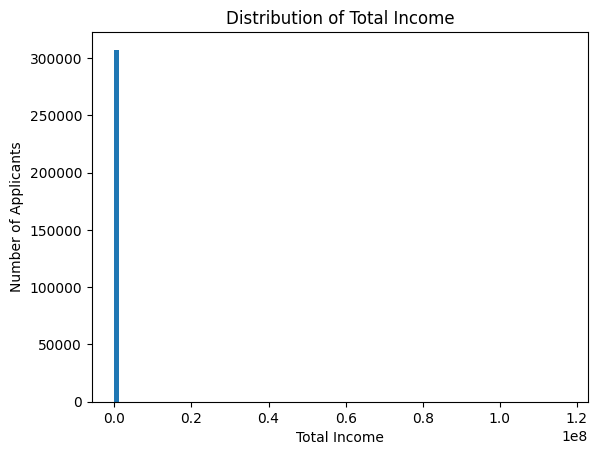

In [21]:
plt.hist(
    application_df['amt_income_total'].dropna(),
    bins=100
)

plt.title('Distribution of Total Income')
plt.xlabel('Total Income')
plt.ylabel('Number of Applicants')

plt.show()

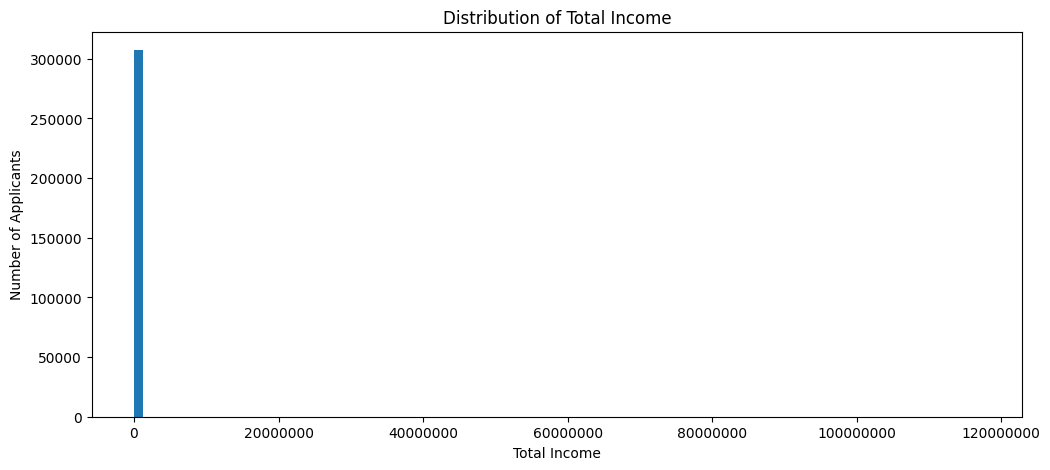

In [22]:
import matplotlib.ticker as ticker
plt.figure(figsize=(12, 5))

plt.hist(
    application_df['amt_income_total'].dropna(),
    bins=100
)

plt.title('Distribution of Total Income')
plt.xlabel('Total Income')
plt.ylabel('Number of Applicants')

plt.ticklabel_format(style='plain', axis='x')

plt.show()

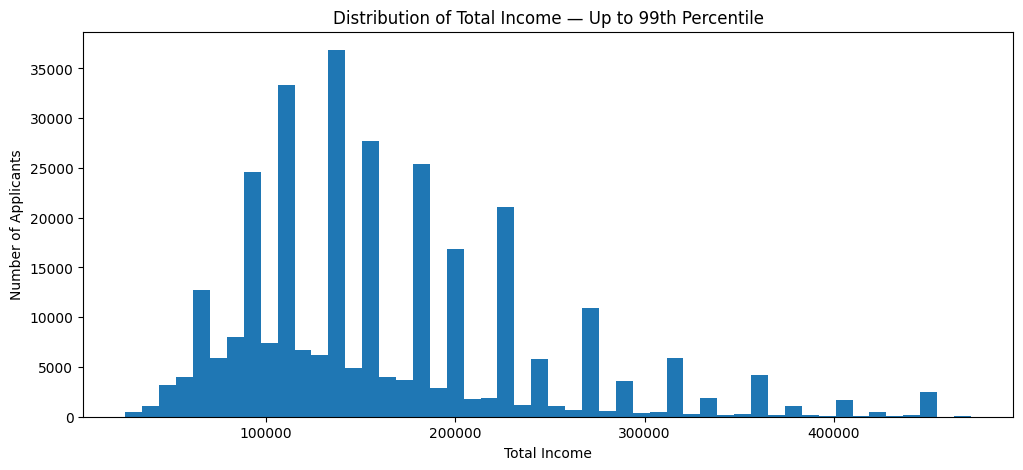

In [23]:
income_99 = application_df['amt_income_total'].quantile(0.99)

plt.figure(figsize=(12, 5))

plt.hist(
    application_df.loc[
        application_df['amt_income_total'] <= income_99,
        'amt_income_total'
    ].dropna(),
    bins=50
)

plt.title('Distribution of Total Income — Up to 99th Percentile')
plt.xlabel('Total Income')
plt.ylabel('Number of Applicants')

plt.ticklabel_format(style='plain', axis='x')

plt.show()

In [24]:
application_df['amt_income_total'].quantile([0.90,0.95,0.99,0.995,0.999])

0.900    270000.0
0.950    337500.0
0.990    472500.0
0.995    630000.0
0.999    900000.0
Name: amt_income_total, dtype: float64

## Numerical Variable EDA

### 1. `amt_income_total` — Applicant Income Distribution

The `amt_income_total` variable was examined to understand the income distribution of applicants.

Initial skewness analysis showed that `amt_income_total` has an extremely right-skewed distribution:

- Skewness: **391.56**
- Median income: **₹147,150**
- Maximum income: **₹117,000,000**

The histogram showed that most applicants are concentrated in the lower income range, while a small number of observations extend far into the upper tail.

#### Income Percentile Analysis

The following percentiles were calculated:

| Percentile | Income |
|------------|-------:|
| 90th | ₹270,000 |
| 95th | ₹337,500 |
| 99th | ₹472,500 |
| 99.5th | ₹630,000 |
| 99.9th | ₹900,000 |

#### Observations

- 90% of applicants have an income of **₹270,000 or less**.
- 95% of applicants have an income of **₹337,500 or less**.
- 99% of applicants have an income of **₹472,500 or less**.
- Only 0.5% of applicants have an income above **₹630,000**.
- Only 0.1% of applicants have an income above **₹900,000**.
- The maximum value of **₹117,000,000** is substantially higher than the 99.9th percentile, indicating a very long upper tail.

#### EDA Interpretation

`amt_income_total` is highly right-skewed, with the majority of applicants concentrated at relatively low-to-moderate income levels and a very small number of observations having exceptionally high income values.

The extreme values have not been removed or modified at this stage. Since EDA is being performed before data cleaning, these observations will be investigated further to determine whether they represent legitimate high-income applicants or potential data-quality issues.

The variable will therefore be revisited during the **Data Cleaning and Missing Value Handling** stage before finalizing the modeling dataset.

In [25]:
income_bins=[0,100000,150000,200000,250000,300000,400000,
             500000,float('inf')]
income_labels = [
    '<100K',
    '100K-150K',
    '150K-200K',
    '200K-250K',
    '250K-300K',
    '300K-400K',
    '400K-500K',
    '500K+'
]
application_df['income_bands']=pd.cut(application_df['amt_income_total'],
                                      bins=income_bins,
                                      labels=income_labels,
                                      include_lowest=True)
                                      

In [26]:
application_df.head()

,sk_id_curr,target,name_contract_type,code_gender,flag_own_car,flag_own_realty,cnt_children,amt_income_total,amt_credit,amt_annuity,...,flag_document_19,flag_document_20,flag_document_21,amt_req_credit_bureau_hour,amt_req_credit_bureau_day,amt_req_credit_bureau_week,amt_req_credit_bureau_mon,amt_req_credit_bureau_qrt,amt_req_credit_bureau_year,income_bands
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,200K-250K
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,250K-300K
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,<100K
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,100K-150K
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,100K-150K


In [27]:
application_df['income_bands'].unique()

['200K-250K', '250K-300K', '<100K', '100K-150K', '150K-200K', '300K-400K', '400K-500K', '500K+']
Categories (8, object): ['<100K' < '100K-150K' < '150K-200K' < '200K-250K' < '250K-300K' < '300K-400K' < '400K-500K' < '500K+']

In [28]:
income_default_rate = (
    application_df
    .groupby('income_bands', observed=True)['target']
    .agg(['count', 'mean'])
)

income_default_rate['default_rate_%'] = (
    income_default_rate['mean'] * 100
)

income_default_rate

,count,mean,default_rate_%
income_bands,,,
<100K,63698,0.082028,8.202769
100K-150K,91591,0.086188,8.618751
150K-200K,64307,0.084470,8.446981
200K-250K,48137,0.077446,7.744562
250K-300K,17039,0.070016,7.001585
300K-400K,14676,0.060303,6.030253
400K-500K,5361,0.060063,6.006342
500K+,2702,0.054034,5.403405


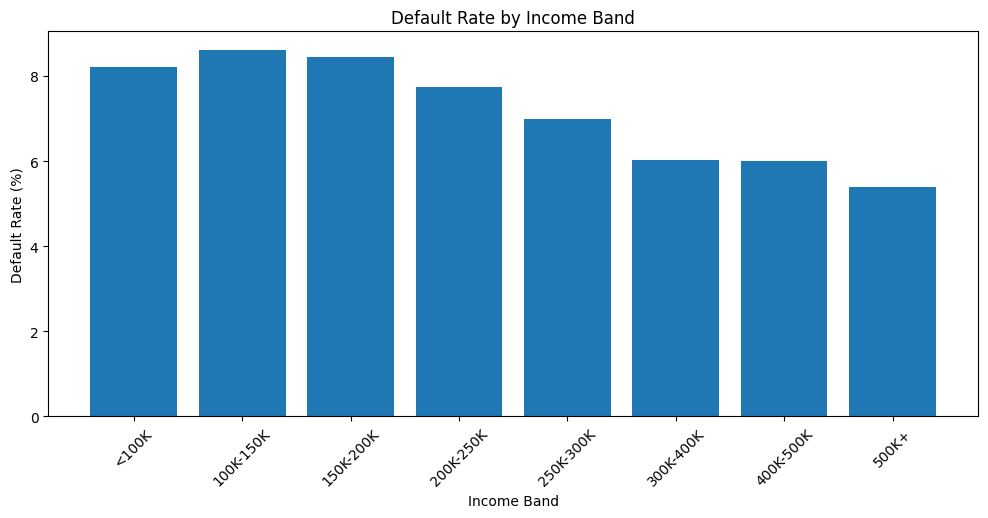

In [29]:
plt.figure(figsize=(12, 5))

plt.bar(
    income_default_rate.index.astype(str),
    income_default_rate['default_rate_%']
)

plt.title('Default Rate by Income Band')
plt.xlabel('Income Band')
plt.ylabel('Default Rate (%)')

plt.xticks(rotation=45)
plt.show()

### Income vs Default Rate

To investigate whether applicant income is associated with repayment difficulty, applicants were grouped into income bands and the default rate was calculated for each group.

The analysis shows a generally **negative relationship between income and default rate**:

- Lower-income applicants have relatively higher default rates.
- Default rates generally decrease as applicant income increases.
- This indicates that `AMT_INCOME_TOTAL` may contain useful predictive information for credit-risk modeling.
- The observed relationship should be interpreted as an association rather than causation.
- Higher-income bands contain fewer observations, so their default rates should be interpreted with greater caution.

**EDA Finding:**  
> Applicants with lower income levels tend to have higher default rates, while default rates generally decrease with increasing income.

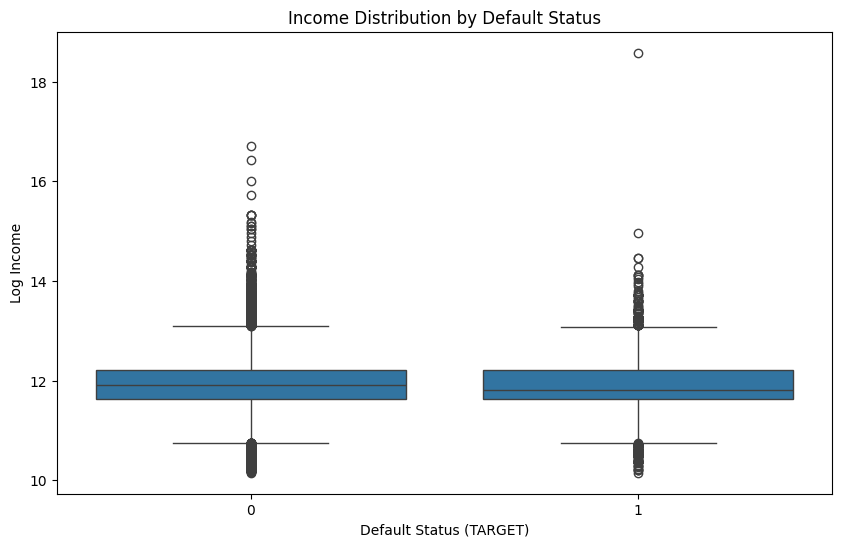

In [30]:
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=application_df,
    x='target',
    y=np.log1p(application_df['amt_income_total'])
)

plt.xlabel('Default Status (TARGET)')
plt.ylabel('Log Income')
plt.title('Income Distribution by Default Status')

plt.show()

### Income Distribution — Key Finding

> **`AMT_INCOME_TOTAL` shows substantial overlap between defaulters (`TARGET = 1`) and non-defaulters (`TARGET = 0`). This indicates that income alone does not provide strong separation between the two groups. Although income may still contribute to the model when combined with other features, it is unlikely to be a strong standalone predictor of default risk.**

In [31]:
application_df.dtypes.value_counts()

float64     65
int64       41
object      16
category     1
Name: count, dtype: int64

In [32]:
application_df.select_dtypes(include='number').shape

(307511, 106)

In [33]:
application_df.select_dtypes(include='object').shape

(307511, 16)

In [34]:
binary_features = [
    col for col in application_df.columns
    if application_df[col].nunique(dropna=True) == 2
]
print(len(binary_features))

37


In [35]:
cardinality = application_df.drop(columns='target').nunique(dropna=True)

cardinality.sort_values().head(20)

reg_city_not_work_city         2
flag_cont_mobile               2
flag_phone                     2
flag_email                     2
flag_document_6                2
flag_document_7                2
flag_document_8                2
reg_region_not_live_region     2
reg_region_not_work_region     2
live_region_not_work_region    2
reg_city_not_live_city         2
flag_document_9                2
live_city_not_work_city        2
flag_document_10               2
flag_document_18               2
flag_document_17               2
flag_document_16               2
flag_document_15               2
flag_document_14               2
flag_document_13               2
dtype: int64

In [36]:
cardinality.sort_values(ascending=False).head(20)

sk_id_curr                307511
ext_source_2              119831
ext_source_1              114584
days_birth                 17460
days_registration          15688
amt_annuity                13672
days_employed              12574
days_id_publish             6168
amt_credit                  5603
livingarea_mode             5301
livingarea_medi             5281
livingarea_avg              5199
totalarea_mode              5116
basementarea_mode           3841
basementarea_avg            3780
days_last_phone_change      3773
basementarea_medi           3772
landarea_mode               3563
landarea_medi               3560
landarea_avg                3527
dtype: int64

In [37]:
[col for col in application_df.columns if 'id' in col.lower()]

['sk_id_curr', 'days_id_publish']

In [38]:
num_cols

Index(['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
       'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object', length=106)

In [39]:
num_cols=application_df.select_dtypes(include=['int64','float64']).columns
numeric_profile = pd.DataFrame({
    'dtype': application_df[num_cols].dtypes,
    'unique': application_df[num_cols].nunique(),
    'missing': application_df[num_cols].isnull().sum(),
    'missing_pct': (
        application_df[num_cols].isnull().mean() * 100
    ).round(2),
    'mean': application_df[num_cols].mean(),
    'median': application_df[num_cols].median(),
    'std': application_df[num_cols].std(),
    'min': application_df[num_cols].min(),
    'max': application_df[num_cols].max(),
    'skewness': application_df[num_cols].skew().round(2),
    'zero_pct': (
        (application_df[num_cols] == 0).mean() * 100
    ).round(2)
})

numeric_profile

,dtype,unique,missing,missing_pct,mean,median,std,min,max,skewness,zero_pct
sk_id_curr,int64,307511,0,0.0,278180.518577,278202.0,102790.175348,100002.0,456255.0,-0.00,0.00
target,int64,2,0,0.0,0.080729,0.0,0.272419,0.0,1.0,3.08,91.93
cnt_children,int64,15,0,0.0,0.417052,0.0,0.722121,0.0,19.0,1.97,70.04
amt_income_total,float64,2548,0,0.0,168797.919297,147150.0,237123.146279,25650.0,117000000.0,391.56,0.00
amt_credit,float64,5603,0,0.0,599025.999706,513531.0,402490.776996,45000.0,4050000.0,1.23,0.00
...,...,...,...,...,...,...,...,...,...,...,...
amt_req_credit_bureau_day,float64,9,41519,13.5,0.007000,0.0,0.110757,0.0,9.0,27.04,86.01
amt_req_credit_bureau_week,float64,9,41519,13.5,0.034362,0.0,0.204685,0.0,8.0,9.29,83.72
amt_req_credit_bureau_mon,float64,24,41519,13.5,0.267395,0.0,0.916002,0.0,27.0,7.80,72.27
amt_req_credit_bureau_qrt,float64,11,41519,13.5,0.265474,0.0,0.794056,0.0,261.0,134.37,70.05


In [40]:
numeric_profile['high_missing']=numeric_profile['missing_pct']>30
numeric_profile['high_skew']=numeric_profile['skewness'].abs()>2
numeric_profile['low_unique']=numeric_profile['unique']<=10
numeric_profile['high_zeropct']=numeric_profile['zero_pct']>50

In [41]:
numeric_profile[['high_missing','high_skew','low_unique','high_zeropct']].sum()

high_missing    45
high_skew       72
low_unique      40
high_zeropct    39
dtype: int64

In [42]:
numeric_profile['profile_flags'] = (
    numeric_profile[['high_missing',
                     'high_skew',
                     'low_unique',
                     'high_zeropct']]
    .sum(axis=1)
)

numeric_profile.sort_values(
    by='profile_flags',
    ascending=False
)[[
    'profile_flags',
    'missing_pct',
    'skewness',
    'zero_pct',
    'unique'
]].head(30)

,profile_flags,missing_pct,skewness,zero_pct,unique
flag_document_12,3,0.00,392.11,100.00,2
flag_document_2,3,0.00,153.79,100.00,2
target,3,0.00,3.08,91.93,2
flag_document_13,3,0.00,16.75,99.65,2
flag_document_15,3,0.00,28.70,99.88,2
flag_document_16,3,0.00,9.89,99.01,2
def_30_cnt_social_circle,3,0.33,5.18,88.23,10
reg_city_not_live_city,3,0.00,3.14,92.18,2
reg_region_not_work_region,3,0.00,4.09,94.92,2
reg_region_not_live_region,3,0.00,7.94,98.49,2


In [43]:
binary_cols = [
    col for col in num_cols
    if application_df[col].nunique(dropna=True) == 2
]

len(binary_cols), binary_cols

(33,
 ['target',
  'flag_mobil',
  'flag_emp_phone',
  'flag_work_phone',
  'flag_cont_mobile',
  'flag_phone',
  'flag_email',
  'reg_region_not_live_region',
  'reg_region_not_work_region',
  'live_region_not_work_region',
  'reg_city_not_live_city',
  'reg_city_not_work_city',
  'live_city_not_work_city',
  'flag_document_2',
  'flag_document_3',
  'flag_document_4',
  'flag_document_5',
  'flag_document_6',
  'flag_document_7',
  'flag_document_8',
  'flag_document_9',
  'flag_document_10',
  'flag_document_11',
  'flag_document_12',
  'flag_document_13',
  'flag_document_14',
  'flag_document_15',
  'flag_document_16',
  'flag_document_17',
  'flag_document_18',
  'flag_document_19',
  'flag_document_20',
  'flag_document_21'])

In [44]:
binary_features = [col for col in binary_cols if col != 'target']

len(binary_features)

32

In [45]:
non_binary_cols = [
    col for col in num_cols
    if col not in binary_cols
]

len(non_binary_cols)

73

In [46]:
non_binary_profile = pd.DataFrame({
    'dtype': application_df[non_binary_cols].dtypes,
    'unique': application_df[non_binary_cols].nunique(),
    'missing': application_df[non_binary_cols].isnull().sum(),
    'missing_pct': (
        application_df[non_binary_cols].isnull().mean() * 100
    ).round(2),
    'mean': application_df[non_binary_cols].mean(),
    'median': application_df[non_binary_cols].median(),
    'std': application_df[non_binary_cols].std(),
    'min': application_df[non_binary_cols].min(),
    'max': application_df[non_binary_cols].max(),
    'skewness': application_df[non_binary_cols].skew().round(2),
    'zero_pct': (
        (application_df[non_binary_cols] == 0).mean() * 100
    ).round(2)
})

non_binary_profile

,dtype,unique,missing,missing_pct,mean,median,std,min,max,skewness,zero_pct
sk_id_curr,int64,307511,0,0.0,278180.518577,278202.0,102790.175348,100002.0,456255.0,-0.00,0.00
cnt_children,int64,15,0,0.0,0.417052,0.0,0.722121,0.0,19.0,1.97,70.04
amt_income_total,float64,2548,0,0.0,168797.919297,147150.0,237123.146279,25650.0,117000000.0,391.56,0.00
amt_credit,float64,5603,0,0.0,599025.999706,513531.0,402490.776996,45000.0,4050000.0,1.23,0.00
amt_annuity,float64,13672,12,0.0,27108.573909,24903.0,14493.737315,1615.5,258025.5,1.58,0.00
...,...,...,...,...,...,...,...,...,...,...,...
amt_req_credit_bureau_day,float64,9,41519,13.5,0.007000,0.0,0.110757,0.0,9.0,27.04,86.01
amt_req_credit_bureau_week,float64,9,41519,13.5,0.034362,0.0,0.204685,0.0,8.0,9.29,83.72
amt_req_credit_bureau_mon,float64,24,41519,13.5,0.267395,0.0,0.916002,0.0,27.0,7.80,72.27
amt_req_credit_bureau_qrt,float64,11,41519,13.5,0.265474,0.0,0.794056,0.0,261.0,134.37,70.05


In [47]:
high_skew_features=non_binary_profile[non_binary_profile['skewness'].abs()>2]
high_skew_features=high_skew_features.sort_values(by='skewness',ascending=False)
high_skew_features.head(15)

,dtype,unique,missing,missing_pct,mean,median,std,min,max,skewness,zero_pct
amt_income_total,float64,2548,0,0.00,168797.919297,147150.0000,237123.146279,25650.0,117000000.0,391.56,0.00
amt_req_credit_bureau_qrt,float64,11,41519,13.50,0.265474,0.0000,0.794056,0.0,261.0,134.37,70.05
amt_req_credit_bureau_day,float64,9,41519,13.50,0.007000,0.0000,0.110757,0.0,9.0,27.04,86.01
nonlivingapartments_mode,float64,167,213514,69.43,0.008076,0.0000,0.046276,0.0,1.0,16.25,19.27
nonlivingapartments_medi,float64,214,213514,69.43,0.008651,0.0000,0.047415,0.0,1.0,15.67,18.24
nonlivingapartments_avg,float64,386,213514,69.43,0.008809,0.0000,0.047732,0.0,1.0,15.54,17.74
amt_req_credit_bureau_hour,float64,5,41519,13.50,0.006402,0.0000,0.083849,0.0,4.0,14.53,85.97
obs_30_cnt_social_circle,float64,33,1021,0.33,1.422245,0.0000,2.400989,0.0,348.0,12.14,53.30
obs_60_cnt_social_circle,float64,33,1021,0.33,1.405292,0.0000,2.379803,0.0,344.0,12.07,53.55
amt_req_credit_bureau_week,float64,9,41519,13.50,0.034362,0.0000,0.204685,0.0,8.0,9.29,83.72


In [48]:
high_skew_features.tail(15)

,dtype,unique,missing,missing_pct,mean,median,std,min,max,skewness,zero_pct
livingarea_avg,float64,5199,154350,50.19,0.107399,0.0745,0.110565,0.0,1.0,2.85,0.09
totalarea_mode,float64,5116,148431,48.27,0.102547,0.0688,0.107462,0.0,1.0,2.80,0.19
own_car_age,float64,62,202929,65.99,12.061091,9.0000,11.944812,0.0,91.0,2.75,0.69
apartments_mode,float64,760,156061,50.75,0.114231,0.0840,0.107936,0.0,1.0,2.70,0.32
apartments_avg,float64,2339,156061,50.75,0.117440,0.0876,0.108240,0.0,1.0,2.64,0.24
apartments_medi,float64,1148,156061,50.75,0.117850,0.0864,0.109076,0.0,1.0,2.64,0.25
elevators_mode,float64,26,163891,53.30,0.074490,0.0000,0.132256,0.0,1.0,2.55,29.10
elevators_medi,float64,46,163891,53.30,0.078078,0.0000,0.134467,0.0,1.0,2.46,28.30
elevators_avg,float64,257,163891,53.30,0.078942,0.0000,0.134576,0.0,1.0,2.44,27.87
entrances_avg,float64,285,154828,50.35,0.149725,0.1379,0.100049,0.0,1.0,2.40,0.11


In [49]:
# Missingness groups
low_missing = non_binary_profile[
    non_binary_profile['missing_pct'] < 20
]

moderate_missing = non_binary_profile[
    (non_binary_profile['missing_pct'] >= 20) &
    (non_binary_profile['missing_pct'] < 50)
]

high_missing = non_binary_profile[
    non_binary_profile['missing_pct'] >= 50
]

In [50]:

low_skew = non_binary_profile[
    non_binary_profile['skewness'].abs() < 1
]

moderate_skew = non_binary_profile[
    (non_binary_profile['skewness'].abs() >= 1) &
    (non_binary_profile['skewness'].abs() < 2)
]

high_skew = non_binary_profile[
    non_binary_profile['skewness'].abs() >= 2
]

In [51]:
low_zero = non_binary_profile[
    non_binary_profile['zero_pct'] < 20
]

moderate_zero = non_binary_profile[
    (non_binary_profile['zero_pct'] >= 20) &
    (non_binary_profile['zero_pct'] < 50)
]

high_zero = non_binary_profile[
    non_binary_profile['zero_pct'] >= 50
]

In [52]:
print(low_missing.index)
print(moderate_missing.index)
print(high_missing.index)
print(low_skew.index)
print(moderate_skew.index)
print(high_skew.index)
print(low_zero.index)
print(moderate_zero.index)
print(high_zero.index)

Index(['sk_id_curr', 'cnt_children', 'amt_income_total', 'amt_credit',
       'amt_annuity', 'amt_goods_price', 'region_population_relative',
       'days_birth', 'days_employed', 'days_registration', 'days_id_publish',
       'cnt_fam_members', 'region_rating_client',
       'region_rating_client_w_city', 'hour_appr_process_start',
       'ext_source_2', 'ext_source_3', 'obs_30_cnt_social_circle',
       'def_30_cnt_social_circle', 'obs_60_cnt_social_circle',
       'def_60_cnt_social_circle', 'days_last_phone_change',
       'amt_req_credit_bureau_hour', 'amt_req_credit_bureau_day',
       'amt_req_credit_bureau_week', 'amt_req_credit_bureau_mon',
       'amt_req_credit_bureau_qrt', 'amt_req_credit_bureau_year'],
      dtype='object')
Index(['years_beginexpluatation_avg', 'floorsmax_avg',
       'years_beginexpluatation_mode', 'floorsmax_mode',
       'years_beginexpluatation_medi', 'floorsmax_medi', 'totalarea_mode'],
      dtype='object')
Index(['own_car_age', 'ext_source_1', 'apar

In [53]:
non_binary_profile[
    (non_binary_profile['missing_pct'] >= 50) &
    (non_binary_profile['skewness'].abs() >= 2)
].index

Index(['own_car_age', 'apartments_avg', 'basementarea_avg', 'commonarea_avg',
       'elevators_avg', 'entrances_avg', 'landarea_avg',
       'livingapartments_avg', 'livingarea_avg', 'nonlivingapartments_avg',
       'nonlivingarea_avg', 'apartments_mode', 'basementarea_mode',
       'commonarea_mode', 'elevators_mode', 'entrances_mode', 'landarea_mode',
       'livingapartments_mode', 'livingarea_mode', 'nonlivingapartments_mode',
       'nonlivingarea_mode', 'apartments_medi', 'basementarea_medi',
       'commonarea_medi', 'elevators_medi', 'entrances_medi', 'landarea_medi',
       'livingapartments_medi', 'livingarea_medi', 'nonlivingapartments_medi',
       'nonlivingarea_medi'],
      dtype='object')

In [54]:
non_binary_profile[
    (non_binary_profile['skewness'].abs() >= 2) &
    (non_binary_profile['zero_pct'] >= 50)
].index

Index(['obs_30_cnt_social_circle', 'def_30_cnt_social_circle',
       'obs_60_cnt_social_circle', 'def_60_cnt_social_circle',
       'amt_req_credit_bureau_hour', 'amt_req_credit_bureau_day',
       'amt_req_credit_bureau_week', 'amt_req_credit_bureau_mon',
       'amt_req_credit_bureau_qrt'],
      dtype='object')

In [55]:
non_binary_profile[
    (non_binary_profile['missing_pct'] >= 50) &
    (non_binary_profile['zero_pct'] >= 50)
].index

Index([], dtype='object')

In [56]:
non_binary_profile[
    (non_binary_profile['missing_pct'] >= 50) &
    (non_binary_profile['skewness'].abs() >= 2) &
    (non_binary_profile['zero_pct'] >= 50)
].index

Index([], dtype='object')

In [57]:
bureau_req_cols=[col for col in non_binary_profile.index if col.startswith('amt_req_credit_bureau')]
bureau_req_cols

['amt_req_credit_bureau_hour',
 'amt_req_credit_bureau_day',
 'amt_req_credit_bureau_week',
 'amt_req_credit_bureau_mon',
 'amt_req_credit_bureau_qrt',
 'amt_req_credit_bureau_year']

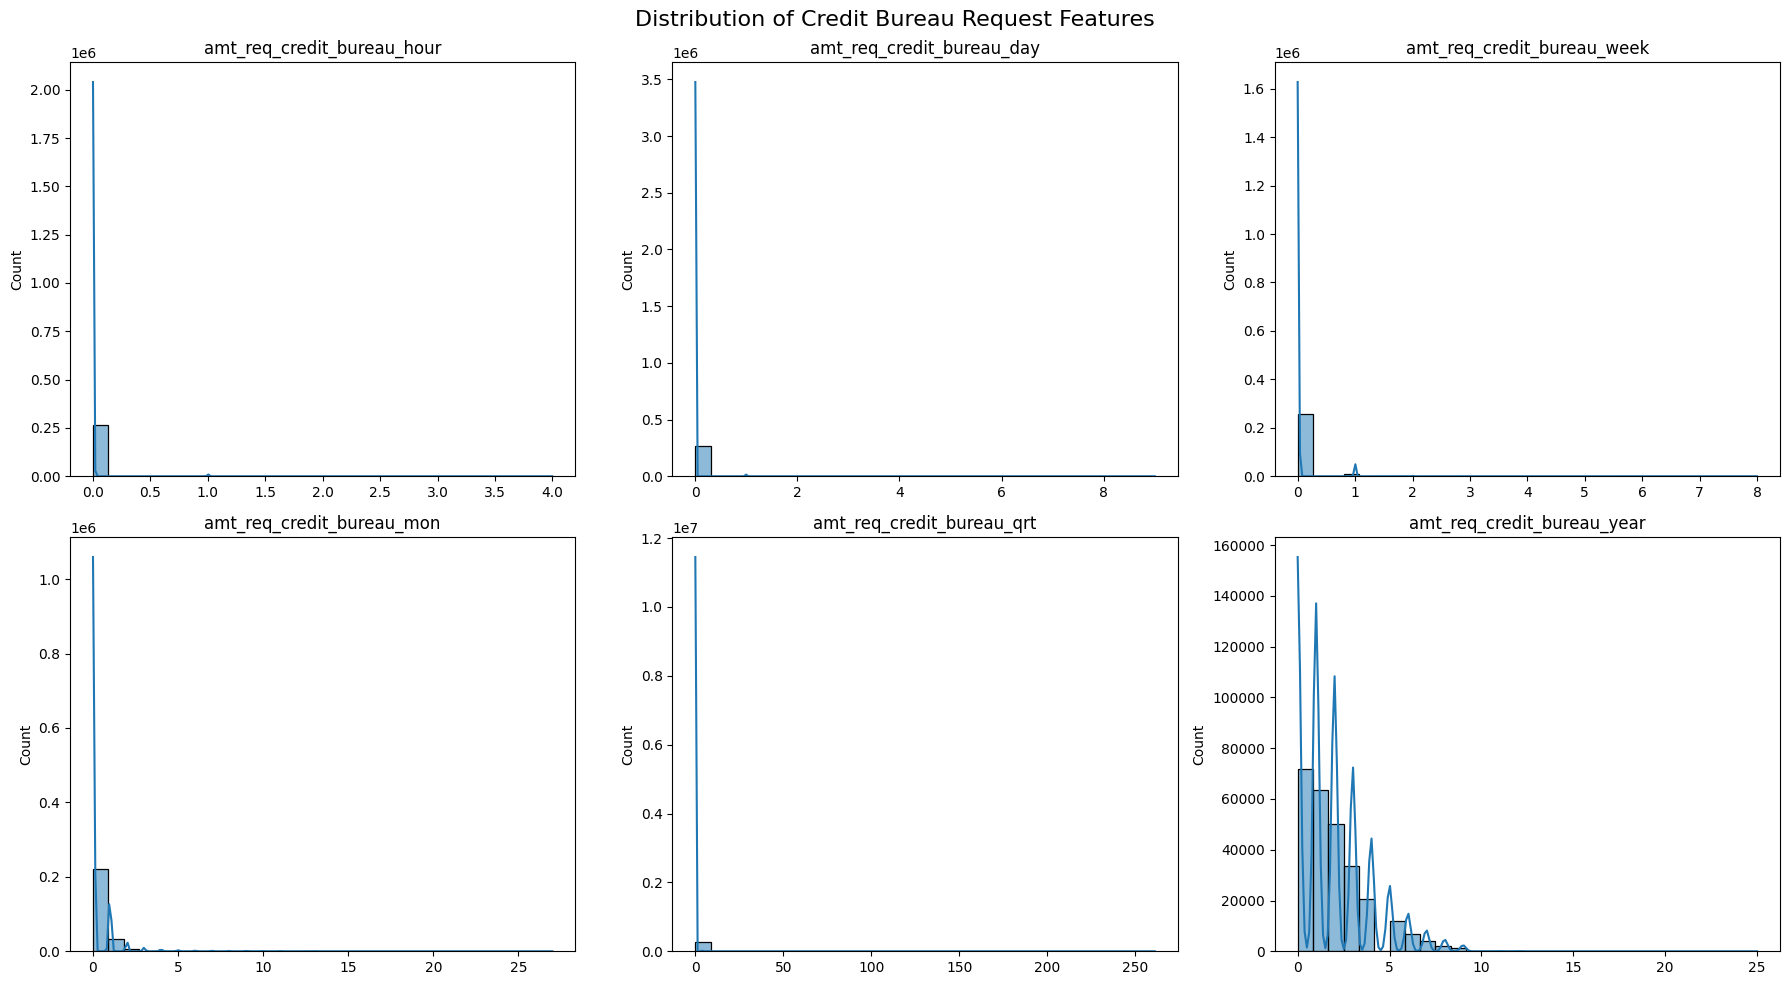

In [58]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, col in zip(axes.flatten(), bureau_req_cols):
    sns.histplot(
        application_df[col],
        bins=30,
        kde=True,
        ax=ax
    )
    ax.set_title(col)
    ax.set_xlabel('')
    ax.set_ylabel('Count')

plt.suptitle(
    'Distribution of Credit Bureau Request Features',
    fontsize=16
)

plt.tight_layout()
plt.show()

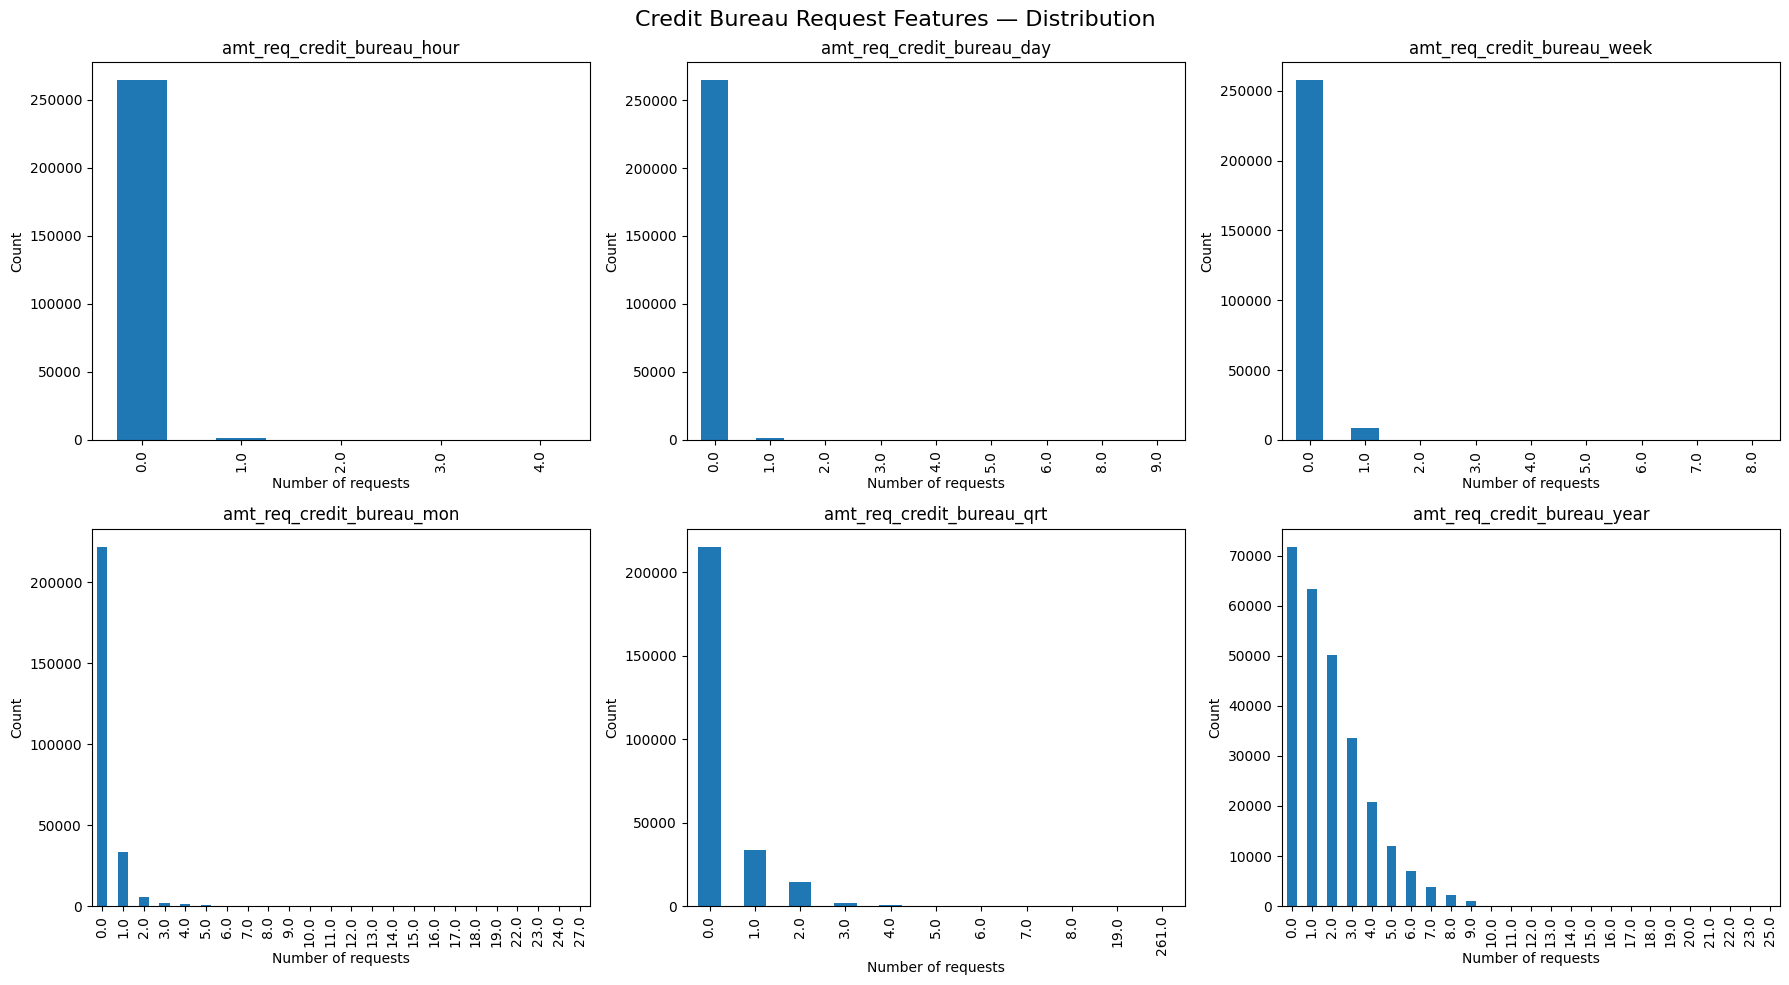

In [59]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, col in zip(axes.flatten(), bureau_req_cols):
    application_df[col].value_counts().sort_index().plot(
        kind='bar',
        ax=ax
    )
    
    ax.set_title(col)
    ax.set_xlabel('Number of requests')
    ax.set_ylabel('Count')
    ax.ticklabel_format(style='plain', axis='y')

plt.suptitle(
    'Credit Bureau Request Features — Distribution',
    fontsize=16
)

plt.tight_layout()
plt.show()

## Credit Bureau Request Features — EDA Findings

The `AMT_REQ_CREDIT_BUREAU_*` features represent the number of credit-bureau inquiries made by an applicant over different time periods:

- `AMT_REQ_CREDIT_BUREAU_HOUR`
- `AMT_REQ_CREDIT_BUREAU_DAY`
- `AMT_REQ_CREDIT_BUREAU_WEEK`
- `AMT_REQ_CREDIT_BUREAU_MON`
- `AMT_REQ_CREDIT_BUREAU_QRT`
- `AMT_REQ_CREDIT_BUREAU_YEAR`

### Distribution Findings

1. **Strong zero inflation** is observed in the short-term credit-bureau request variables. Most applicants have zero recorded inquiries.

2. The percentage of zero values is particularly high for:
   - `HOUR` → approximately **86%**
   - `DAY` → approximately **86%**
   - `WEEK` → approximately **84%**
   - `MON` → approximately **72%**
   - `QRT` → approximately **70%**

3. The variables are **strongly right-skewed**, with most observations concentrated at zero or at a small number of requests and relatively few applicants having a large number of inquiries.

4. The skewness is particularly high for:
   - `HOUR` → **14.53**
   - `DAY` → **27.04**
   - `WEEK` → **9.29**
   - `MON` → **7.80**
   - `QRT` → **134.37**

5. `AMT_REQ_CREDIT_BUREAU_YEAR` shows a different pattern. It has considerably more variation across request counts and is less dominated by zero compared with the shorter time-period variables.

6. The shorter-period variables have relatively few unique values, indicating that they behave as **discrete count variables** rather than continuous numerical variables.

### Overall EDA Interpretation

The credit-bureau request variables form a related feature family and should therefore be analyzed together rather than independently.

The distributions show that most applicants have little or no recent credit-bureau inquiry activity, while a smaller group has substantially more inquiries. This results in **zero-inflated and right-skewed distributions**.

Because these are discrete count variables, frequency/bar plots are appropriate for understanding their distributions.

### Modeling Consideration

High skewness and zero inflation do **not automatically mean that these features should be removed or transformed**.

Their usefulness should be determined by examining their relationship with the target variable (`TARGET`) and their eventual contribution to the baseline model.

Therefore, the next step is to analyze whether different levels of credit-bureau inquiry activity are associated with different **default rates**.

In [60]:
default_rate_qtr=application_df.groupby('amt_req_credit_bureau_qrt')['target'].agg(['count','mean']).reset_index()
default_rate_qtr

,amt_req_credit_bureau_qrt,count,mean
0,0.0,215417,0.078476
1,1.0,33862,0.065767
2,2.0,14412,0.083472
3,3.0,1717,0.073384
4,4.0,476,0.119748
5,5.0,64,0.093750
6,6.0,28,0.250000
7,7.0,7,0.142857
8,8.0,7,0.000000
9,19.0,1,1.000000


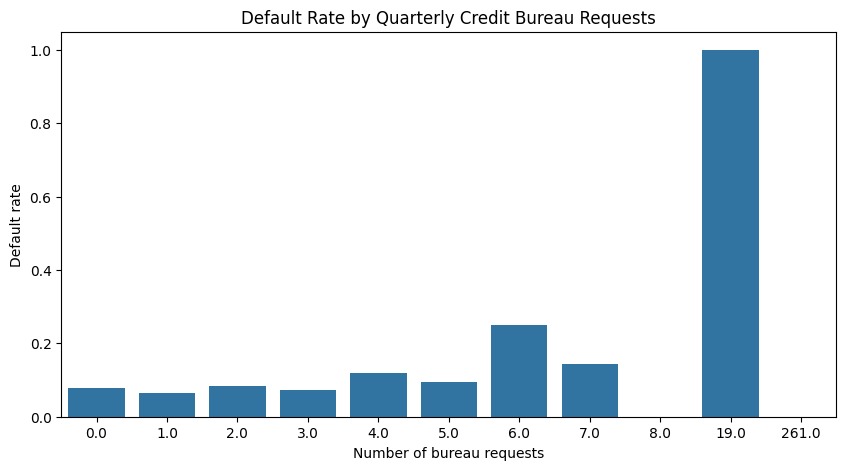

In [61]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=default_rate_qtr,
    x='amt_req_credit_bureau_qrt',
    y='mean'
)

plt.title(
    'Default Rate by Quarterly Credit Bureau Requests'
)

plt.xlabel('Number of bureau requests')
plt.ylabel('Default rate')

plt.show()

## Credit Bureau Requests — Relationship with Target

The relationship between `AMT_REQ_CREDIT_BUREAU_QRT` and `TARGET` was examined using the default rate for each number of quarterly credit-bureau requests.

For the well-populated categories (0–4 requests), the default rates range approximately from **6.6% to 12.0%**. There is no clear monotonic relationship between the number of quarterly bureau requests and default rate across these categories.

The categories with higher request counts show large fluctuations in default rate. However, these categories contain very few observations. For example, the value `19` has only **1 applicant** and a default rate of **100%**, while the value `261` also has only **1 applicant** and a default rate of **0%**. These extreme rates are therefore statistically unstable and should not be interpreted as meaningful evidence of increased or decreased credit risk.

Similarly, categories with only a small number of applicants should be interpreted cautiously because their observed default rates can vary substantially due to sample size.

### EDA Conclusion

`AMT_REQ_CREDIT_BUREAU_QRT` is strongly zero-inflated and right-skewed, but the target relationship does not show a strong or consistent pattern in the well-represented categories.

The analysis also demonstrates the importance of considering **sample size together with default rate** when analyzing categorical or discrete numerical variables.

For modeling, the feature should not be removed solely because of its skewness or zero inflation. Its usefulness will ultimately be evaluated using model performance and other feature-selection techniques.

In [62]:
default_rate_qtr.sort_values(by='count',ascending=False)

,amt_req_credit_bureau_qrt,count,mean
0,0.0,215417,0.078476
1,1.0,33862,0.065767
2,2.0,14412,0.083472
3,3.0,1717,0.073384
4,4.0,476,0.119748
5,5.0,64,0.093750
6,6.0,28,0.250000
7,7.0,7,0.142857
8,8.0,7,0.000000
9,19.0,1,1.000000


In [63]:
application_df[
    application_df['amt_req_credit_bureau_qrt'] > 8
][[
    'sk_id_curr',
    'amt_req_credit_bureau_qrt',
    'target'
]]

,sk_id_curr,amt_req_credit_bureau_qrt,target
239474,377322,261.0,0
253541,393383,19.0,1


In [64]:
application_df['amt_req_credit_bureau_qrt'].describe()

count    265992.000000
mean          0.265474
std           0.794056
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         261.000000
Name: amt_req_credit_bureau_qrt, dtype: float64

In [65]:
application_df['amt_req_credit_bureau_qrt'].isna().sum()

np.int64(41519)

In [66]:
bureau_req_cols

['amt_req_credit_bureau_hour',
 'amt_req_credit_bureau_day',
 'amt_req_credit_bureau_week',
 'amt_req_credit_bureau_mon',
 'amt_req_credit_bureau_qrt',
 'amt_req_credit_bureau_year']

In [67]:
application_df[bureau_req_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
amt_req_credit_bureau_hour,265992.0,0.006402,0.083849,0.0,0.0,0.0,0.0,4.0
amt_req_credit_bureau_day,265992.0,0.007000,0.110757,0.0,0.0,0.0,0.0,9.0
amt_req_credit_bureau_week,265992.0,0.034362,0.204685,0.0,0.0,0.0,0.0,8.0
amt_req_credit_bureau_mon,265992.0,0.267395,0.916002,0.0,0.0,0.0,0.0,27.0
amt_req_credit_bureau_qrt,265992.0,0.265474,0.794056,0.0,0.0,0.0,0.0,261.0
amt_req_credit_bureau_year,265992.0,1.899974,1.869295,0.0,0.0,1.0,3.0,25.0


In [68]:
(application_df[bureau_req_cols].isnull().mean()*100).sort_values(ascending=False)

amt_req_credit_bureau_hour    13.501631
amt_req_credit_bureau_day     13.501631
amt_req_credit_bureau_week    13.501631
amt_req_credit_bureau_mon     13.501631
amt_req_credit_bureau_qrt     13.501631
amt_req_credit_bureau_year    13.501631
dtype: float64

In [69]:
application_df[bureau_req_cols].corr()

,amt_req_credit_bureau_hour,amt_req_credit_bureau_day,amt_req_credit_bureau_week,amt_req_credit_bureau_mon,amt_req_credit_bureau_qrt,amt_req_credit_bureau_year
amt_req_credit_bureau_hour,1.000000,0.230374,0.004706,-0.000018,-0.002716,-0.004597
amt_req_credit_bureau_day,0.230374,1.000000,0.217412,-0.005258,-0.004416,-0.003355
amt_req_credit_bureau_week,0.004706,0.217412,1.000000,-0.014096,-0.015115,0.018917
amt_req_credit_bureau_mon,-0.000018,-0.005258,-0.014096,1.000000,-0.007789,-0.004975
amt_req_credit_bureau_qrt,-0.002716,-0.004416,-0.015115,-0.007789,1.000000,0.076208
amt_req_credit_bureau_year,-0.004597,-0.003355,0.018917,-0.004975,0.076208,1.000000


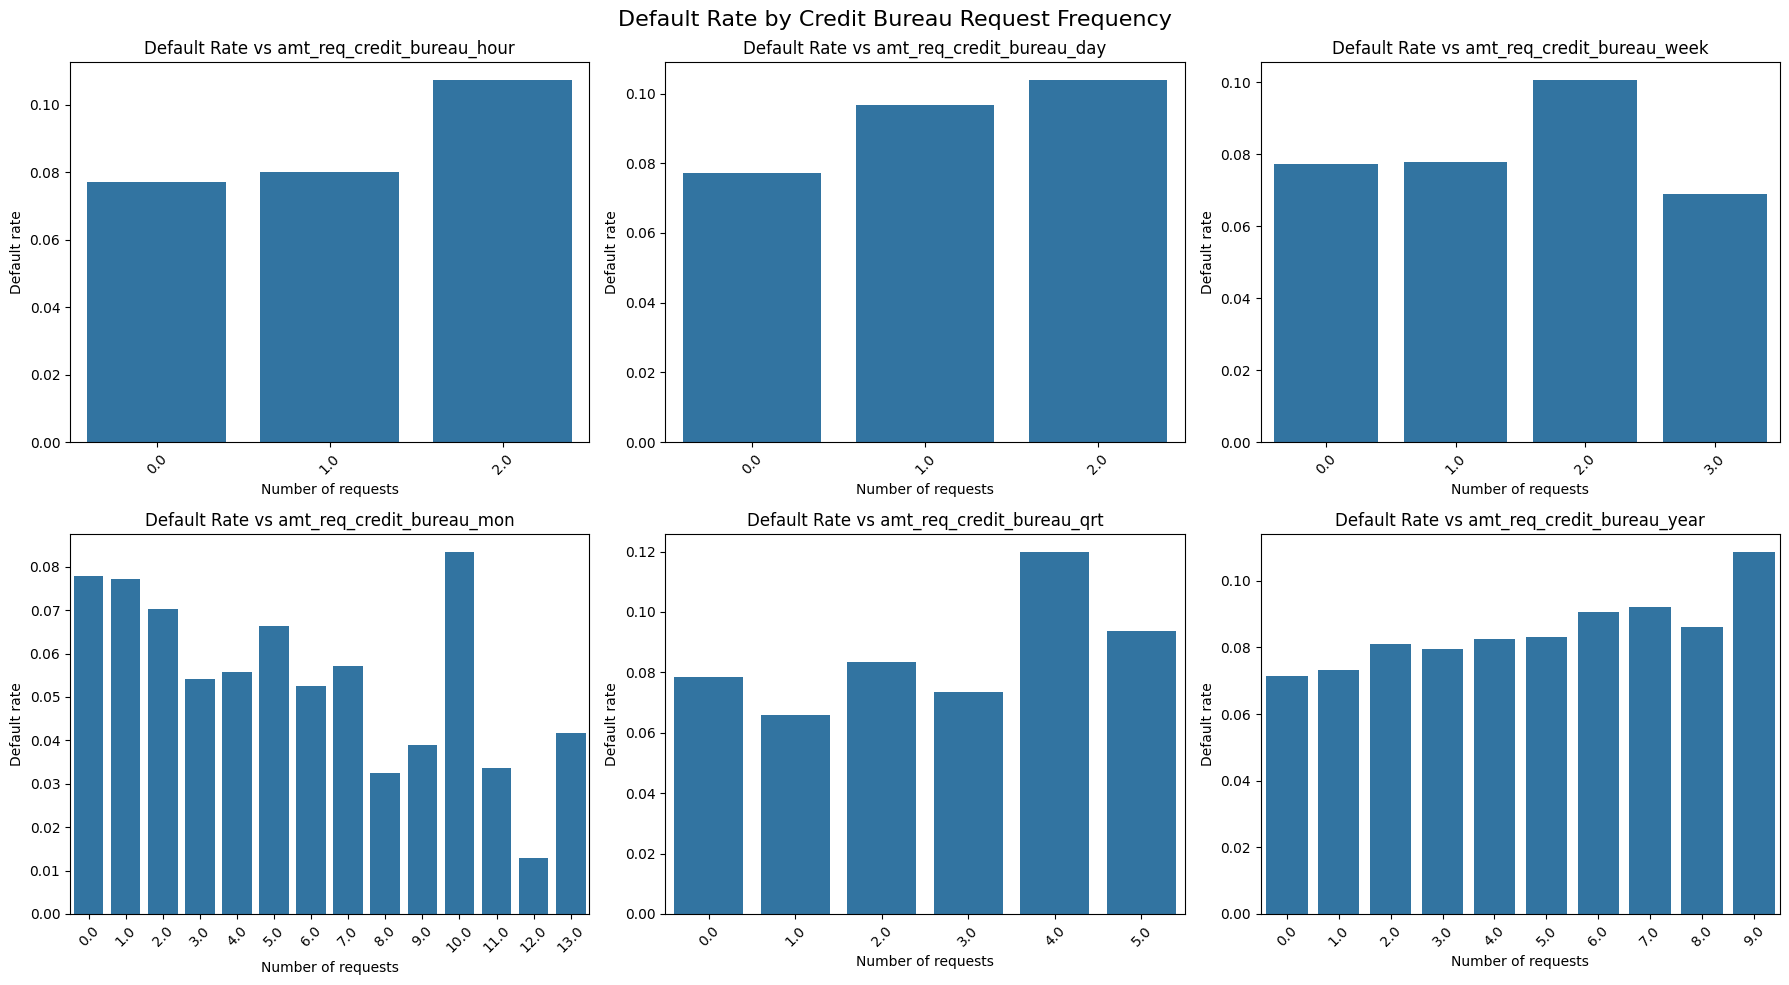

In [70]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, col in zip(axes.flatten(), bureau_req_cols):

    default_rate = (
        application_df
        .groupby(col)['target']
        .agg(['count', 'mean'])
        .reset_index()
    )

    # Keep only groups with at least 50 observations
    default_rate = default_rate[default_rate['count'] >= 50]

    sns.barplot(
        data=default_rate,
        x=col,
        y='mean',
        ax=ax
    )

    ax.set_title(f'Default Rate vs {col}')
    ax.set_xlabel('Number of requests')
    ax.set_ylabel('Default rate')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle(
    'Default Rate by Credit Bureau Request Frequency',
    fontsize=16
)

plt.tight_layout()
plt.show()

## Credit Bureau Request Features — EDA Findings

### Features Analyzed

- `amt_req_credit_bureau_hour`
- `amt_req_credit_bureau_day`
- `amt_req_credit_bureau_week`
- `amt_req_credit_bureau_mon`
- `amt_req_credit_bureau_qrt`
- `amt_req_credit_bureau_year`

### Distribution & Missing Values

- All six features contain approximately **13.5% missing values**.
- `hour`, `day`, `week`, `month`, and `quarter` are highly **zero-inflated**, with the median and 75th percentile equal to 0.
- `year` has a higher frequency of requests, with a median of 1 and 75th percentile of 3.
- The features are generally **right-skewed**, with a small number of customers having unusually high bureau-request counts.
- `amt_req_credit_bureau_qrt` contains an extreme value of **261**, while `amt_req_credit_bureau_year` has a maximum of 25.
- Extreme values were retained during EDA and will be considered during preprocessing.

### Relationship with Target

- `hour` and `day` show relatively weak relationships with the target.
- `week` shows some variation in default rate but no clear monotonic pattern.
- `month` shows noticeable but non-linear variation in default rates across request counts.
- `quarter` shows increased default rates at some higher request levels.
  - Customers with **0 quarterly requests** had a default rate of approximately **7.85%**.
  - Customers with **4 quarterly requests** had a default rate of approximately **11.97%**.
- `year` shows the clearest overall upward tendency in default rate as annual bureau requests increase.
- Extremely sparse request-count groups were excluded from the target-rate visualization because their default rates are statistically unstable.

### Correlation

- Correlation among the six bureau-request features is generally low.
- The strongest relationships are:
  - `hour` and `day`: **0.23**
  - `day` and `week`: **0.22**
  - `quarter` and `year`: **0.08**
- There is no strong linear correlation between most features in this group.
- Low correlation between features does **not** mean that a feature has no predictive relationship with the target.

### Overall EDA Conclusion

The credit-bureau request features are highly sparse and right-skewed, with consistent missingness across the feature group. Their relationship with default risk is generally weak for shorter time windows but becomes more noticeable for monthly, quarterly, and especially annual request activity.

`amt_req_credit_bureau_year` appears to show the strongest potential target relationship, while the remaining features may still provide useful information when combined with other predictors.

### Modeling Note

No features were removed based solely on this EDA.

Missing values, extreme values, and feature usefulness will be addressed during the **data-cleaning and baseline-modeling stages**.

In [71]:
application_df.columns


Index(['sk_id_curr', 'target', 'name_contract_type', 'code_gender',
       'flag_own_car', 'flag_own_realty', 'cnt_children', 'amt_income_total',
       'amt_credit', 'amt_annuity',
       ...
       'flag_document_19', 'flag_document_20', 'flag_document_21',
       'amt_req_credit_bureau_hour', 'amt_req_credit_bureau_day',
       'amt_req_credit_bureau_week', 'amt_req_credit_bureau_mon',
       'amt_req_credit_bureau_qrt', 'amt_req_credit_bureau_year',
       'income_bands'],
      dtype='object', length=123)

In [72]:
days_related_features=[col for col in application_df.columns if col.startswith('days')]
days_related_features

['days_birth',
 'days_employed',
 'days_registration',
 'days_id_publish',
 'days_last_phone_change']

In [73]:
application_df[days_related_features].describe().T

,count,mean,std,min,25%,50%,75%,max
days_birth,307511.0,-16036.995067,4363.988632,-25229.0,-19682.0,-15750.0,-12413.0,-7489.0
days_employed,307511.0,63815.045904,141275.766519,-17912.0,-2760.0,-1213.0,-289.0,365243.0
days_registration,307511.0,-4986.120328,3522.886321,-24672.0,-7479.5,-4504.0,-2010.0,0.0
days_id_publish,307511.0,-2994.202373,1509.450419,-7197.0,-4299.0,-3254.0,-1720.0,0.0
days_last_phone_change,307510.0,-962.858788,826.808487,-4292.0,-1570.0,-757.0,-274.0,0.0


In [74]:
application_df[days_related_features].isna().sum()

days_birth                0
days_employed             0
days_registration         0
days_id_publish           0
days_last_phone_change    1
dtype: int64

In [75]:
(application_df[days_related_features]==365243).sum()

days_birth                    0
days_employed             55374
days_registration             0
days_id_publish               0
days_last_phone_change        0
dtype: int64

In [76]:
(application_df.loc[:,days_related_features]==365243).sum()

days_birth                    0
days_employed             55374
days_registration             0
days_id_publish               0
days_last_phone_change        0
dtype: int64

In [77]:
application_df.groupby('target')['days_birth'].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,282686.0,-16138.176397,4364.200856,-25229.0,-19793.75,-15877.0,-12536.0,-7489.0
1,24825.0,-14884.828077,4192.844583,-25168.0,-18037.00,-14282.0,-11396.0,-7678.0


In [78]:
application_df['age_years_eda']=(abs(application_df['days_birth'])/365).round(2)
application_df['age_years_eda'].head()

0    25.92
1    45.93
2    52.18
3    52.07
4    54.61
Name: age_years_eda, dtype: float64

In [79]:
application_df.groupby('target')['age_years_eda'].mean()


target
0    44.214185
1    40.780352
Name: age_years_eda, dtype: float64

In [80]:
application_df['age_group_eda'] = pd.cut(
    application_df['age_years_eda'],
    bins=[20, 25, 30, 35, 40, 45, 50, 60, 100],
    labels=['20-25','25-30','30-35','35-40','40-45','45-50','50-60','60-100'],
    include_lowest=True
)
application_df['age_group_eda'].head()

0    25-30
1    45-50
2    50-60
3    50-60
4    50-60
Name: age_group_eda, dtype: category
Categories (8, object): ['20-25' < '25-30' < '30-35' < '35-40' < '40-45' < '45-50' < '50-60' < '60-100']

In [81]:
age_default_rate=application_df.groupby('age_group_eda')['target'].mean()*100
age_default_rate

C:\Users\HomePC\AppData\Local\Temp\ipykernel_22004\998862545.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_default_rate=application_df.groupby('age_group_eda')['target'].mean()*100


age_group_eda
20-25     12.295688
25-30     11.142214
30-35     10.280066
35-40      8.947528
40-45      7.846169
45-50      7.415315
50-60      6.127876
60-100     4.923795
Name: target, dtype: float64

In [82]:
application_df.groupby('target')['days_employed'].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,282686.0,65696.146123,142877.810161,-17912.0,-2813.0,-1235.0,-278.0,365243.0
1,24825.0,42394.675448,119484.634253,-16069.0,-2156.0,-1034.0,-379.0,365243.0


In [83]:
application_df.groupby('days_employed')['target'].agg(['count','mean']).sort_values(by='count',ascending=False)

,count,mean
days_employed,,
365243,55374,0.053996
-200,156,0.134615
-224,152,0.085526
-199,151,0.125828
-230,151,0.099338
...,...,...
-11027,1,0.000000
-11030,1,0.000000
-11031,1,0.000000


In [84]:
application_df.loc[
    application_df['days_employed'] != 365243,
    'days_employed'
].describe()

count    252137.000000
mean      -2384.169325
std        2338.360162
min      -17912.000000
25%       -3175.000000
50%       -1648.000000
75%        -767.000000
max           0.000000
Name: days_employed, dtype: float64

In [85]:
application_df['days_years_employed']=np.where(application_df['days_employed']==365243,np.nan,
                                               (abs(application_df['days_employed'])/365).round(2))
application_df['days_years_employed'].head()

0    1.75
1    3.25
2    0.62
3    8.33
4    8.32
Name: days_years_employed, dtype: float64

In [86]:
application_df['days_years_employed'].isna().sum()

np.int64(55374)

In [87]:
application_df['days_group_employed']=pd.cut(application_df['days_years_employed'],
                                            bins=[0,2,5,10,20,30,40,50],
                                            labels=['0-2','2-5','5-10', '10-20','20-30','30-40','40-50'],
                                            include_lowest=True)
application_df['days_group_employed'].head()

0     0-2
1     2-5
2     0-2
3    5-10
4    5-10
Name: days_group_employed, dtype: category
Categories (7, object): ['0-2' < '2-5' < '5-10' < '10-20' < '20-30' < '30-40' < '40-50']

In [88]:
employment_default_rate=application_df.groupby('days_group_employed')['target'].mean()*100
employment_default_rate

C:\Users\HomePC\AppData\Local\Temp\ipykernel_22004\3063206019.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  employment_default_rate=application_df.groupby('days_group_employed')['target'].mean()*100


days_group_employed
0-2      11.206263
2-5      10.071679
5-10      7.372625
10-20     5.512714
20-30     4.483553
30-40     3.466956
40-50     0.427350
Name: target, dtype: float64

In [89]:
employment_default_summary = (
    application_df.groupby('days_group_employed', observed=True)['target']
    .agg(['count', 'mean'])
)

employment_default_summary['default_rate'] = (
    employment_default_summary['mean'] * 100
)

employment_default_summary

,count,mean,default_rate
days_group_employed,,,
0-2,59904,0.112063,11.206263
2-5,76452,0.100717,10.071679
5-10,64848,0.073726,7.372625
10-20,38384,0.055127,5.512714
20-30,9546,0.044836,4.483553
30-40,2769,0.034670,3.466956
40-50,234,0.004274,0.427350


In [90]:
remaining_days_features = [
    'days_registration',
    'days_id_publish',
    'days_last_phone_change'
]

for col in remaining_days_features:
    print(f"\n{'='*50}")
    print(f"{col}")
    print('='*50)
    print(application_df[col].describe())


days_registration
count    307511.000000
mean      -4986.120328
std        3522.886321
min      -24672.000000
25%       -7479.500000
50%       -4504.000000
75%       -2010.000000
max           0.000000
Name: days_registration, dtype: float64

days_id_publish
count    307511.000000
mean      -2994.202373
std        1509.450419
min       -7197.000000
25%       -4299.000000
50%       -3254.000000
75%       -1720.000000
max           0.000000
Name: days_id_publish, dtype: float64

days_last_phone_change
count    307510.000000
mean       -962.858788
std         826.808487
min       -4292.000000
25%       -1570.000000
50%        -757.000000
75%        -274.000000
max           0.000000
Name: days_last_phone_change, dtype: float64


In [91]:
for col in remaining_days_features:
    print(f"{col}: {application_df[col].isna().sum()} missing values")

days_registration: 0 missing values
days_id_publish: 0 missing values
days_last_phone_change: 1 missing values


In [92]:
application_df.groupby('days_registration')['target'].agg(
    ['count', 'mean']
).sort_values('count', ascending=False).head(10)

,count,mean
days_registration,,
-1.0,113,0.150442
-7.0,98,0.122449
-6.0,96,0.135417
-2.0,92,0.173913
-4.0,92,0.108696
-5.0,86,0.127907
-9.0,84,0.119048
-3.0,84,0.107143
0.0,80,0.112500


In [93]:
application_df['days_registration_years']=abs(application_df['days_registration'])/365
application_df['days_registration_years'].head()

0     9.994521
1     3.249315
2    11.671233
3    26.939726
4    11.810959
Name: days_registration_years, dtype: float64

In [94]:
application_df['days_registration_group']=pd.cut(application_df['days_registration_years'], 
                                                 bins=[0,2,5,10,20,30,40,50,70], 
                                                 labels=['0-2','2-5','5-10','10-20','20-30','30-40','40-50','50-70'], 
                                                 include_lowest=True) 
application_df['days_registration_group'].head()

0     5-10
1      2-5
2    10-20
3    20-30
4    10-20
Name: days_registration_group, dtype: category
Categories (8, object): ['0-2' < '2-5' < '5-10' < '10-20' < '20-30' < '30-40' < '40-50' < '50-70']

In [95]:
registration_default_rate=application_df.groupby('days_registration_group')['target'].mean()*100 
registration_default_rate

C:\Users\HomePC\AppData\Local\Temp\ipykernel_22004\767750666.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  registration_default_rate=application_df.groupby('days_registration_group')['target'].mean()*100


days_registration_group
0-2      9.645530
2-5      8.793764
5-10     8.719376
10-20    8.316362
20-30    6.611356
30-40    5.659179
40-50    3.815869
50-70    5.000000
Name: target, dtype: float64

In [96]:
application_df['days_published_years']=abs(application_df['days_id_publish'])/365
application_df['days_published_years'].head()

0    5.808219
1    0.797260
2    6.934247
3    6.676712
4    9.473973
Name: days_published_years, dtype: float64

In [97]:
application_df['days_published_years'].describe()

count    307511.000000
mean          8.203294
std           4.135481
min           0.000000
25%           4.712329
50%           8.915068
75%          11.778082
max          19.717808
Name: days_published_years, dtype: float64

In [98]:
application_df['days_published_group']=pd.cut(application_df['days_published_years'], 
                                                 bins=[0,2,5,10,20], 
                                                 labels=['0-2','2-5','5-10','10-20'],
                                                 include_lowest=True) 
application_df['days_published_group'].head()

0    5-10
1     0-2
2    5-10
3    5-10
4    5-10
Name: days_published_group, dtype: category
Categories (4, object): ['0-2' < '2-5' < '5-10' < '10-20']

In [99]:
published_default_rate=application_df.groupby('days_published_group')['target'].mean()*100
published_default_rate

C:\Users\HomePC\AppData\Local\Temp\ipykernel_22004\856215310.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  published_default_rate=application_df.groupby('days_published_group')['target'].mean()*100


days_published_group
0-2      10.180283
2-5       9.684120
5-10      8.455414
10-20     6.700202
Name: target, dtype: float64

In [100]:
application_df.groupby('days_published_group')['target'].agg(['count','mean'])

C:\Users\HomePC\AppData\Local\Temp\ipykernel_22004\2389368336.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  application_df.groupby('days_published_group')['target'].agg(['count','mean'])


,count,mean
days_published_group,,
0-2,30785,0.101803
2-5,51032,0.096841
5-10,92698,0.084554
10-20,132996,0.067002


In [101]:
application_df['days_phone_change_years'] = (
    abs(application_df['days_last_phone_change']) / 365
)

In [102]:
application_df['days_phone_change_years'].describe()

count    307510.000000
mean          2.637969
std           2.265229
min           0.000000
25%           0.750685
50%           2.073973
75%           4.301370
max          11.758904
Name: days_phone_change_years, dtype: float64

In [103]:
application_df['phone_change_group_eda'] = pd.cut(
    application_df['days_phone_change_years'],
    bins=[0, 1, 2, 3, 5, 8, 12],
    labels=['0-1', '1-2', '2-3', '3-5', '5-8', '8-12'],
    include_lowest=True
)

In [104]:
phone_change_group = application_df.groupby('phone_change_group_eda')['target'].mean()*100
    
phone_change_group

C:\Users\HomePC\AppData\Local\Temp\ipykernel_22004\1623727043.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  phone_change_group = application_df.groupby('phone_change_group_eda')['target'].mean()*100


phone_change_group_eda
0-1     9.576765
1-2     9.296958
2-3     8.269089
3-5     6.710393
5-8     5.789531
8-12    4.546234
Name: target, dtype: float64

In [105]:
phone_change_summary = (
    application_df.groupby(
        'phone_change_group_eda',
        observed=True
    )['target']
    .agg(['count', 'mean'])
)

phone_change_summary['default_rate'] = (
    phone_change_summary['mean'] * 100
)

phone_change_summary

,count,mean,default_rate
phone_change_group_eda,,,
0-1,92620,0.095768,9.576765
1-2,57621,0.092970,9.296958
2-3,37876,0.082691,8.269089
3-5,67999,0.067104,6.710393
5-8,45565,0.057895,5.789531
8-12,5829,0.045462,4.546234


In [106]:
days_related_features

['days_birth',
 'days_employed',
 'days_registration',
 'days_id_publish',
 'days_last_phone_change']

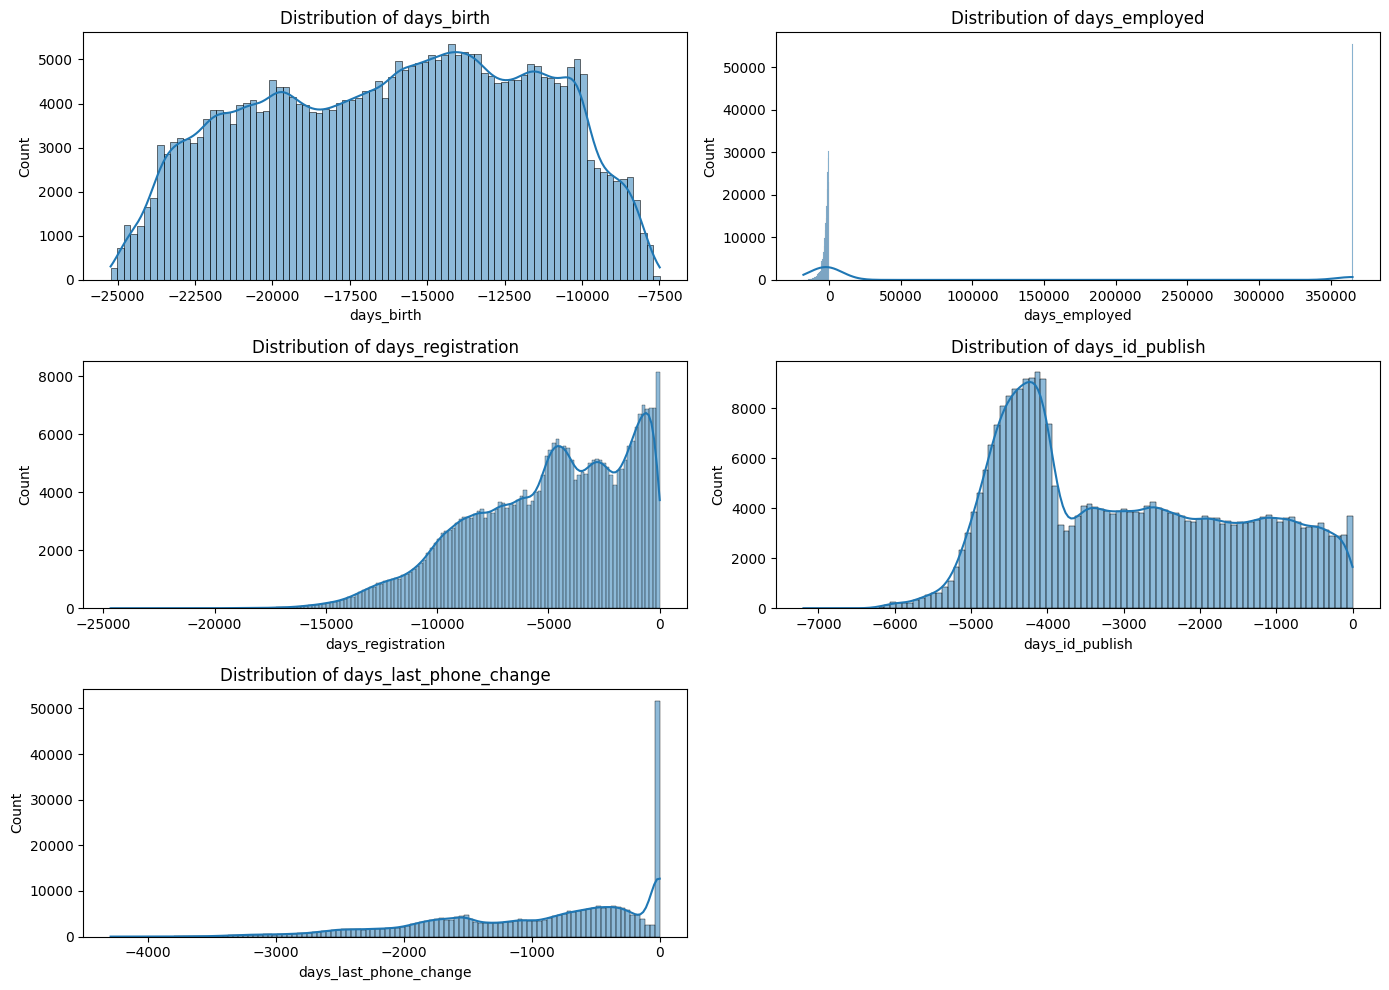

In [107]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3, 2, figsize=(14, 10))

for ax, feature in zip(axes.flat, days_related_features):
    sns.histplot(data=application_df, x=feature, kde=True, ax=ax)
    ax.set_title(f'Distribution of {feature}')
    ax.set_xlabel(feature)
    ax.set_ylabel('Count')
axes.flat[-1].set_visible(False)

plt.tight_layout()
plt.show()

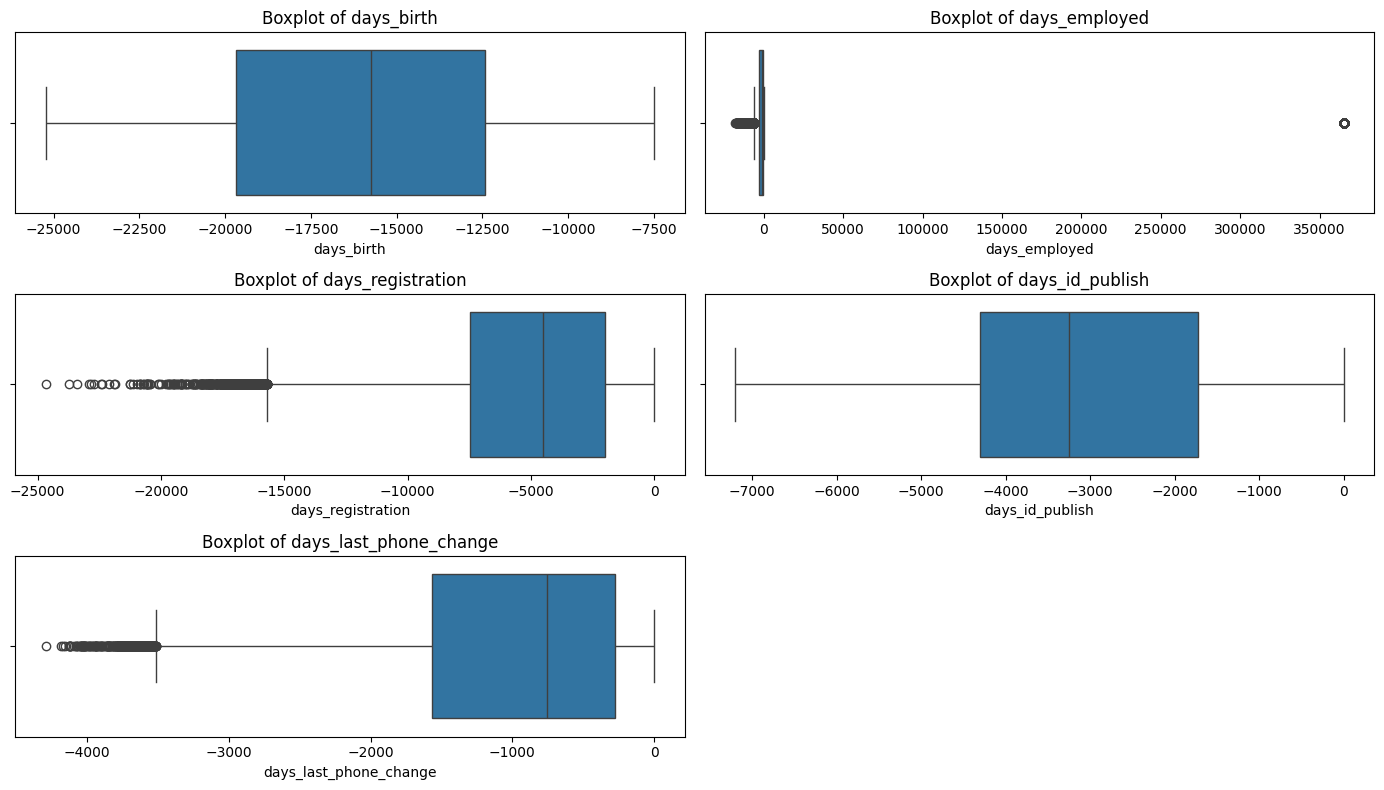

In [108]:
fig, axes = plt.subplots(3, 2, figsize=(14, 8))

for ax, feature in zip(axes.flat, days_related_features):
    sns.boxplot(x=application_df[feature], ax=ax)
    ax.set_title(f'Boxplot of {feature}')
    ax.set_xlabel(feature)
axes.flat[-1].set_visible(False)
plt.tight_layout()
plt.show()

In [109]:
days_employed_valid = application_df.loc[
    application_df['days_employed'] != 365243,
    'days_employed'
]

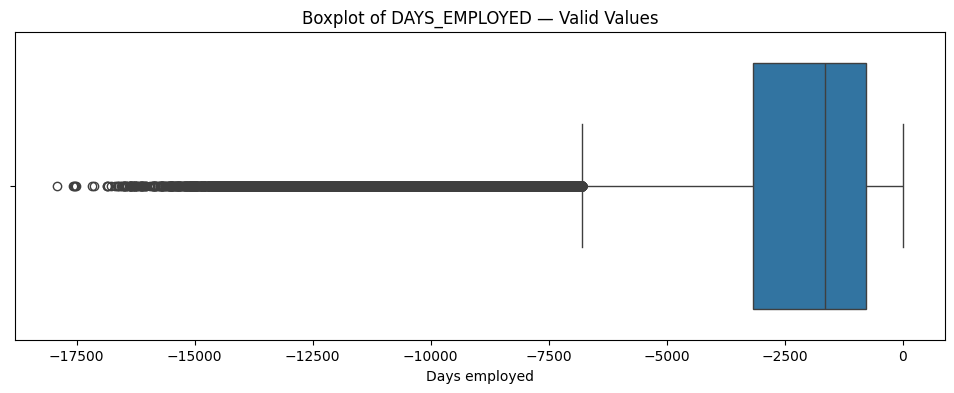

In [110]:
plt.figure(figsize=(12, 4))

sns.boxplot(x=days_employed_valid)

plt.title('Boxplot of DAYS_EMPLOYED — Valid Values')
plt.xlabel('Days employed')

plt.show()

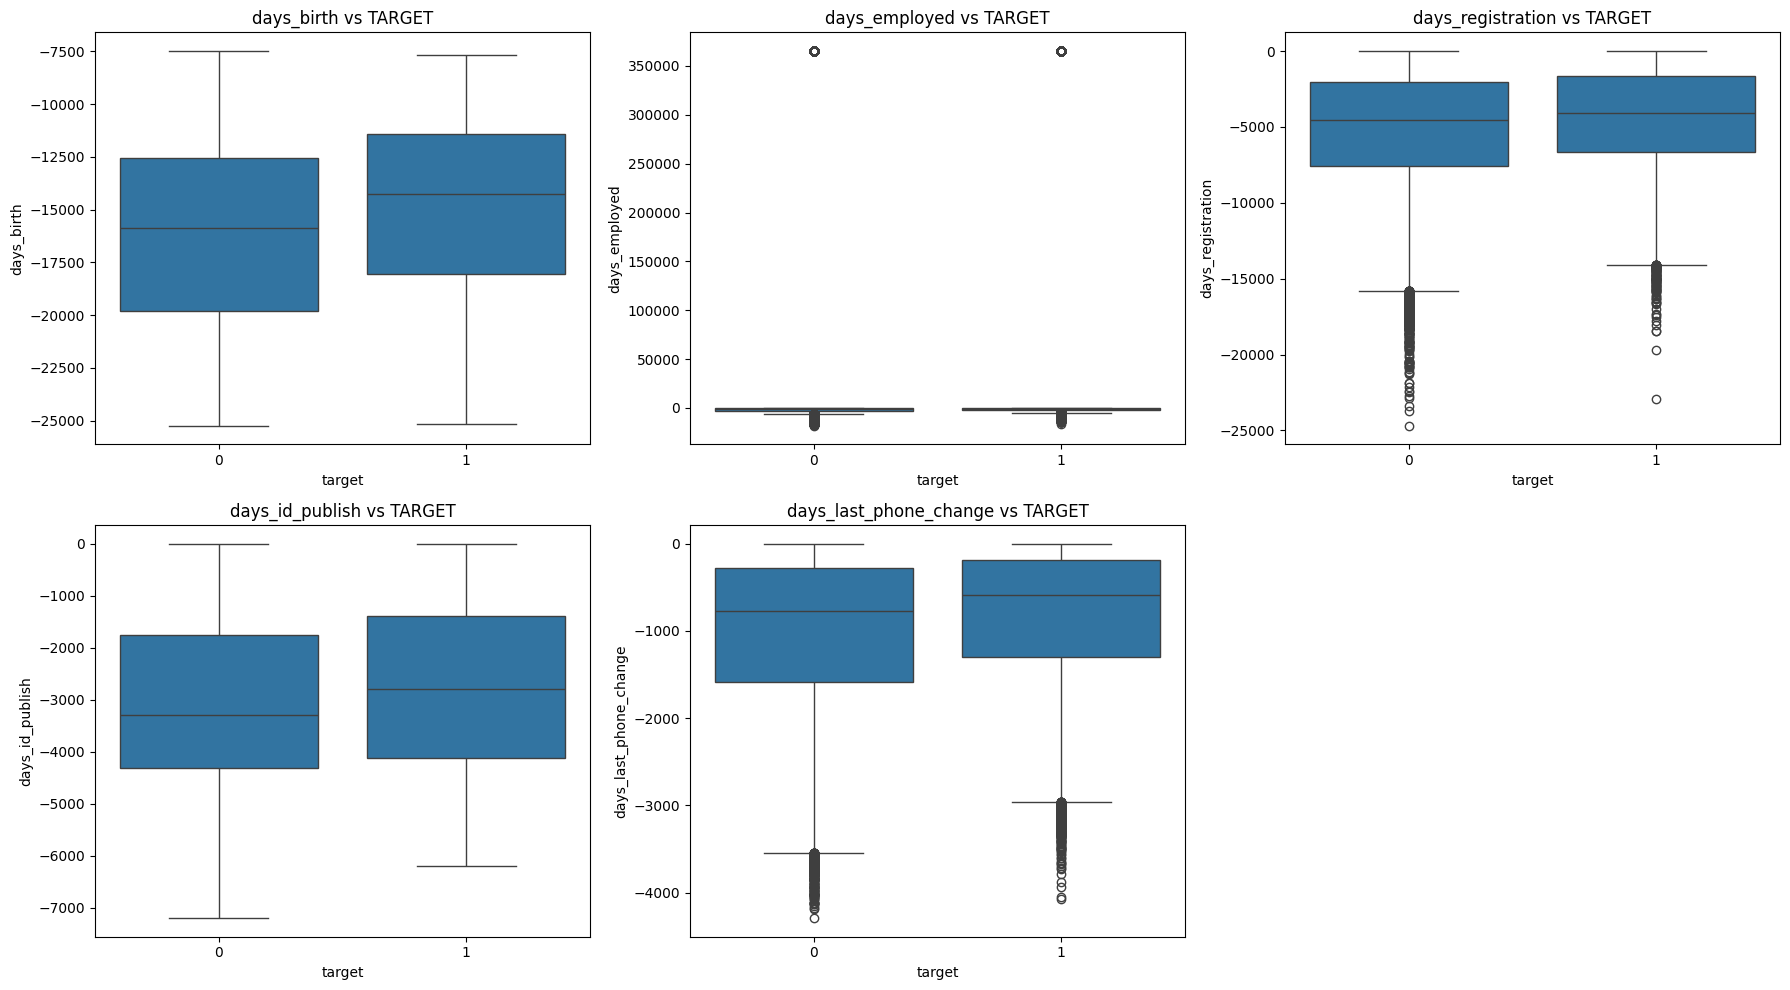

In [111]:


fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, feature in zip(axes.flat, days_related_features):
    sns.boxplot(
        data=application_df,
        x='target',
        y=feature,
        ax=ax
    )
    
    ax.set_title(f'{feature} vs TARGET')
    ax.set_xlabel('target')
    ax.set_ylabel(feature)

# Hide unused subplot
axes.flat[-1].set_visible(False)

plt.tight_layout()
plt.show()

In [112]:
days_related_group=[age_default_rate,employment_default_rate,registration_default_rate,
                    published_default_rate,phone_change_group]
names = [
    'Age Group',
    'Employment Duration',
    'Registration Duration',
    'ID Publication Duration',
    'Phone Change Duration'
]

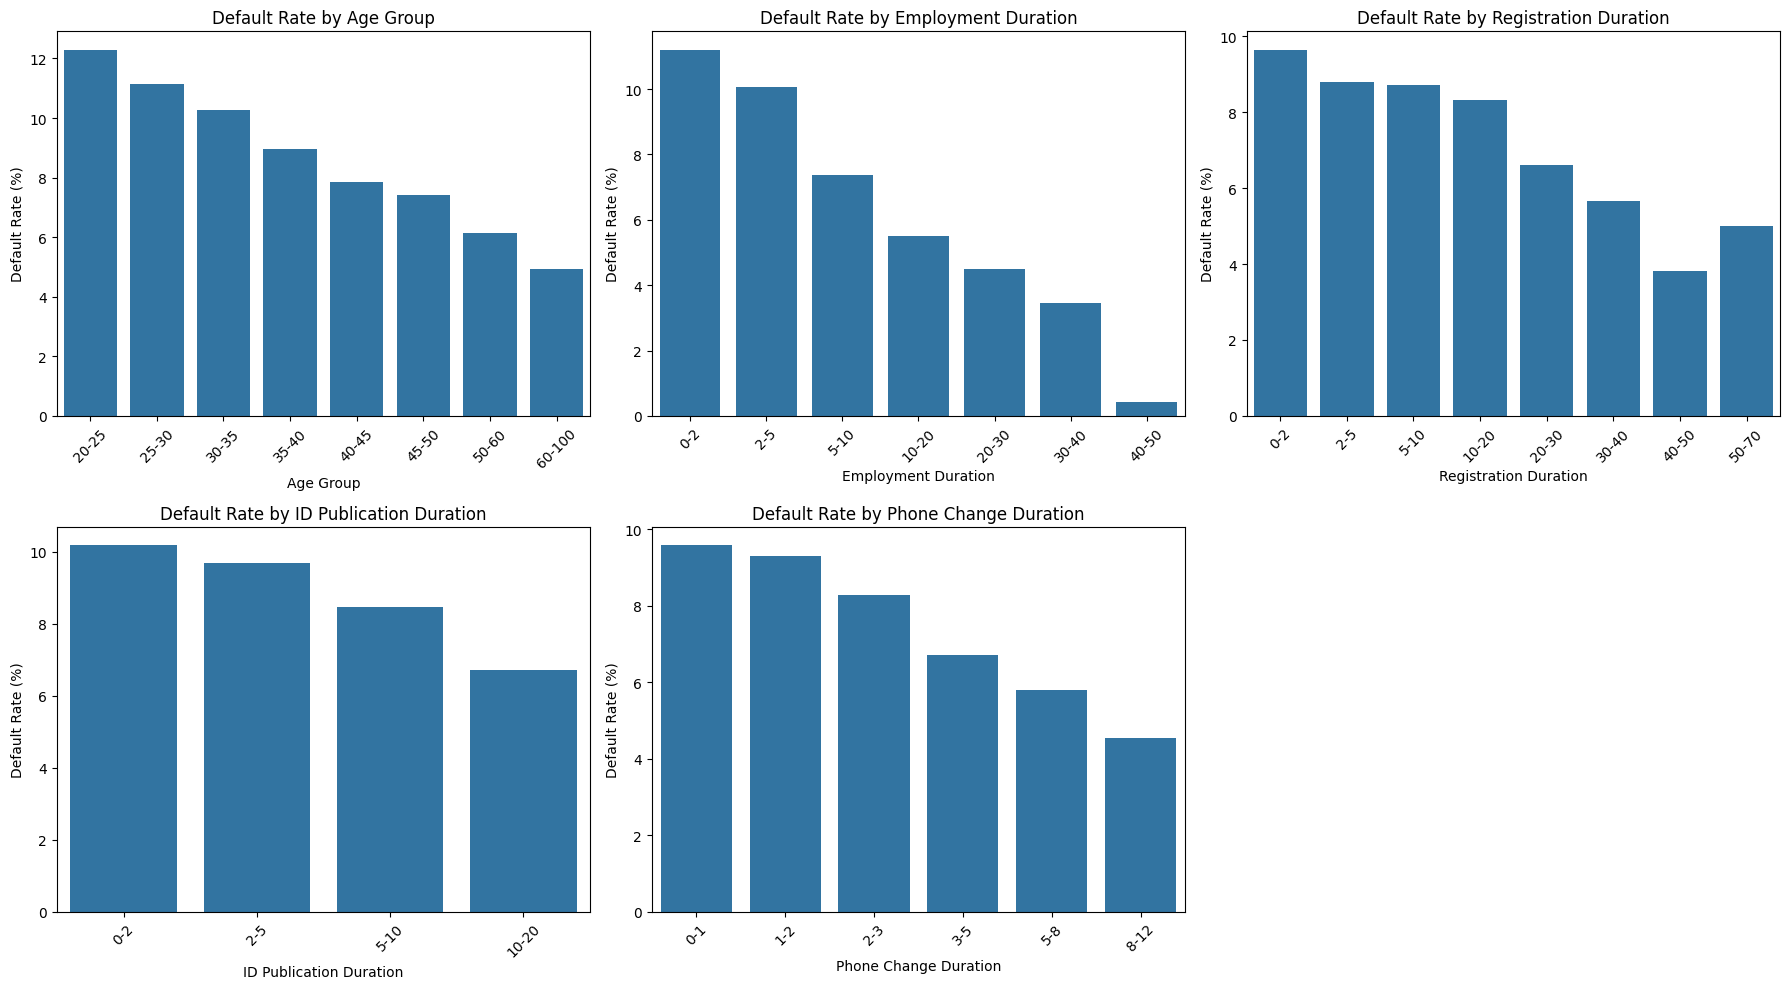

In [113]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, group, name in zip(axes.flat, days_related_group, names):

    sns.barplot(
        x=group.index,
        y=group.values,
        ax=ax
    )

    ax.set_title(f'Default Rate by {name}')
    ax.set_xlabel(name)
    ax.set_ylabel('Default Rate (%)')
    ax.tick_params(axis='x', rotation=45)

# Hide the unused 6th subplot
axes.flat[-1].set_visible(False)

plt.tight_layout()
plt.show()

## Day-Related Features — EDA Findings

The day-related features were analyzed using distribution plots, boxplots, feature-vs-target boxplots, and grouped default-rate analysis.

### 1. Age (`days_birth`)

- The distribution of `days_birth` is broad, with no major data-quality anomaly observed.
- The boxplot shows a noticeable difference between defaulters and non-defaulters.
- Default rate decreases consistently as applicant age increases.
- Default rate decreases from approximately **12.30% for applicants aged 20–25** to **4.92% for applicants aged 60–100**.
- This indicates a strong negative relationship between applicant age and default risk.
- Younger applicants represent a higher observed default-risk segment in the dataset.

### 2. Employment Duration (`days_employed`)

- `days_employed` has a highly skewed distribution.
- The value **365243** is an extreme/special value and does not represent a realistic employment duration.
- This value needs to be handled separately during data cleaning/feature engineering rather than being treated as a normal employment duration.
- After excluding the special value for visualization, the feature shows a long tail toward longer employment durations.
- Default rate decreases substantially as employment duration increases:
  - **11.21%** for 0–2 years
  - **10.07%** for 2–5 years
  - **7.37%** for 5–10 years
  - **5.51%** for 10–20 years
  - **4.48%** for 20–30 years
  - **3.47%** for 30–40 years
  - **0.43%** for 40–50 years
- This indicates a strong negative relationship between employment duration and default risk.
- The 40–50 year group has an unusually low default rate and should be checked for sample size before drawing a strong conclusion.

### 3. Registration History (`days_registration`)

- `days_registration` is strongly skewed toward more recent values, with a long tail toward older registration history.
- The boxplot shows numerous observations outside the lower whisker, reflecting the skewed distribution rather than necessarily invalid data.
- Default rate generally decreases as the registration history becomes older.
- Default rate decreases from **9.65% for 0–2 years** to **3.82% for 40–50 years**.
- The final 50–70 year group increases to **5.00%**, indicating that the relationship is not perfectly monotonic at the extreme end.
- Overall, the feature shows a moderate negative relationship with default risk.

### 4. ID Publication History (`days_id_publish`)

- `days_id_publish` shows a non-normal distribution with a strong concentration around earlier values and a broader secondary pattern.
- The boxplot indicates a shift in the distribution between defaulters and non-defaulters.
- Default rate decreases consistently across the available groups:
  - **10.18%** for 0–2 years
  - **9.68%** for 2–5 years
  - **8.46%** for 5–10 years
  - **6.70%** for 10–20 years
- This indicates a clear negative relationship between the time since ID publication and default risk.

### 5. Last Phone Change (`days_last_phone_change`)

- The distribution is strongly skewed with a large concentration around zero and a long negative tail.
- The value zero is not automatically considered an error because it can represent a phone change occurring on or around the application date.
- The boxplot shows that defaulters tend to have more recent phone-change dates.
- Default rate decreases consistently as the time since the last phone change increases:
  - **9.58%** for 0–1 years
  - **9.30%** for 1–2 years
  - **8.27%** for 2–3 years
  - **6.71%** for 3–5 years
  - **5.79%** for 5–8 years
  - **4.55%** for 8–12 years
- This indicates a strong negative relationship between time since the last phone change and default risk.

### Overall Conclusion

The day-related features show meaningful relationships with credit default risk.

- **`days_birth`**: younger applicants have higher observed default rates.
- **`days_employed`**: longer employment duration is associated with lower default rates.
- **`days_registration`**: older registration history generally corresponds to lower default rates, although the relationship is slightly non-monotonic at the extreme end.
- **`days_id_publish`**: longer time since ID publication is associated with lower default rates.
- **`days_last_phone_change`**: longer time since the last phone change is associated with lower default rates.

Overall, these features appear to contain useful predictive information and should be retained for further modeling analysis.

The special value **365243 in `days_employed`** requires dedicated treatment during the data-cleaning stage. Statistical outliers identified through boxplots should not be removed automatically because they may represent legitimate applicants and can potentially contain predictive information.

In [114]:
col_list=application_df.columns.tolist()
col_list

['sk_id_curr',
 'target',
 'name_contract_type',
 'code_gender',
 'flag_own_car',
 'flag_own_realty',
 'cnt_children',
 'amt_income_total',
 'amt_credit',
 'amt_annuity',
 'amt_goods_price',
 'name_type_suite',
 'name_income_type',
 'name_education_type',
 'name_family_status',
 'name_housing_type',
 'region_population_relative',
 'days_birth',
 'days_employed',
 'days_registration',
 'days_id_publish',
 'own_car_age',
 'flag_mobil',
 'flag_emp_phone',
 'flag_work_phone',
 'flag_cont_mobile',
 'flag_phone',
 'flag_email',
 'occupation_type',
 'cnt_fam_members',
 'region_rating_client',
 'region_rating_client_w_city',
 'weekday_appr_process_start',
 'hour_appr_process_start',
 'reg_region_not_live_region',
 'reg_region_not_work_region',
 'live_region_not_work_region',
 'reg_city_not_live_city',
 'reg_city_not_work_city',
 'live_city_not_work_city',
 'organization_type',
 'ext_source_1',
 'ext_source_2',
 'ext_source_3',
 'apartments_avg',
 'basementarea_avg',
 'years_beginexpluatation_a

In [115]:
print(len(col_list))

133


In [116]:
application_df.drop(['income_bands','age_years_eda','age_group_eda','days_years_employed',
 'days_group_employed','days_registration_years','days_registration_group','days_published_years',
 'days_published_group','days_phone_change_years','phone_change_group_eda'],axis=1,inplace=True)

In [117]:
application_df.shape

(307511, 122)

In [118]:
amt_related_features=[ 'amt_income_total','amt_credit','amt_annuity','amt_goods_price']
amt_related_features

['amt_income_total', 'amt_credit', 'amt_annuity', 'amt_goods_price']

In [119]:
application_df[amt_related_features].describe().T

,count,mean,std,min,25%,50%,75%,max
amt_income_total,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
amt_credit,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
amt_annuity,307499.0,27108.573909,14493.737315,1615.5,16524.0,24903.0,34596.0,258025.5
amt_goods_price,307233.0,538396.207429,369446.460540,40500.0,238500.0,450000.0,679500.0,4050000.0


In [120]:
application_df[amt_related_features].isnull().sum()

amt_income_total      0
amt_credit            0
amt_annuity          12
amt_goods_price     278
dtype: int64

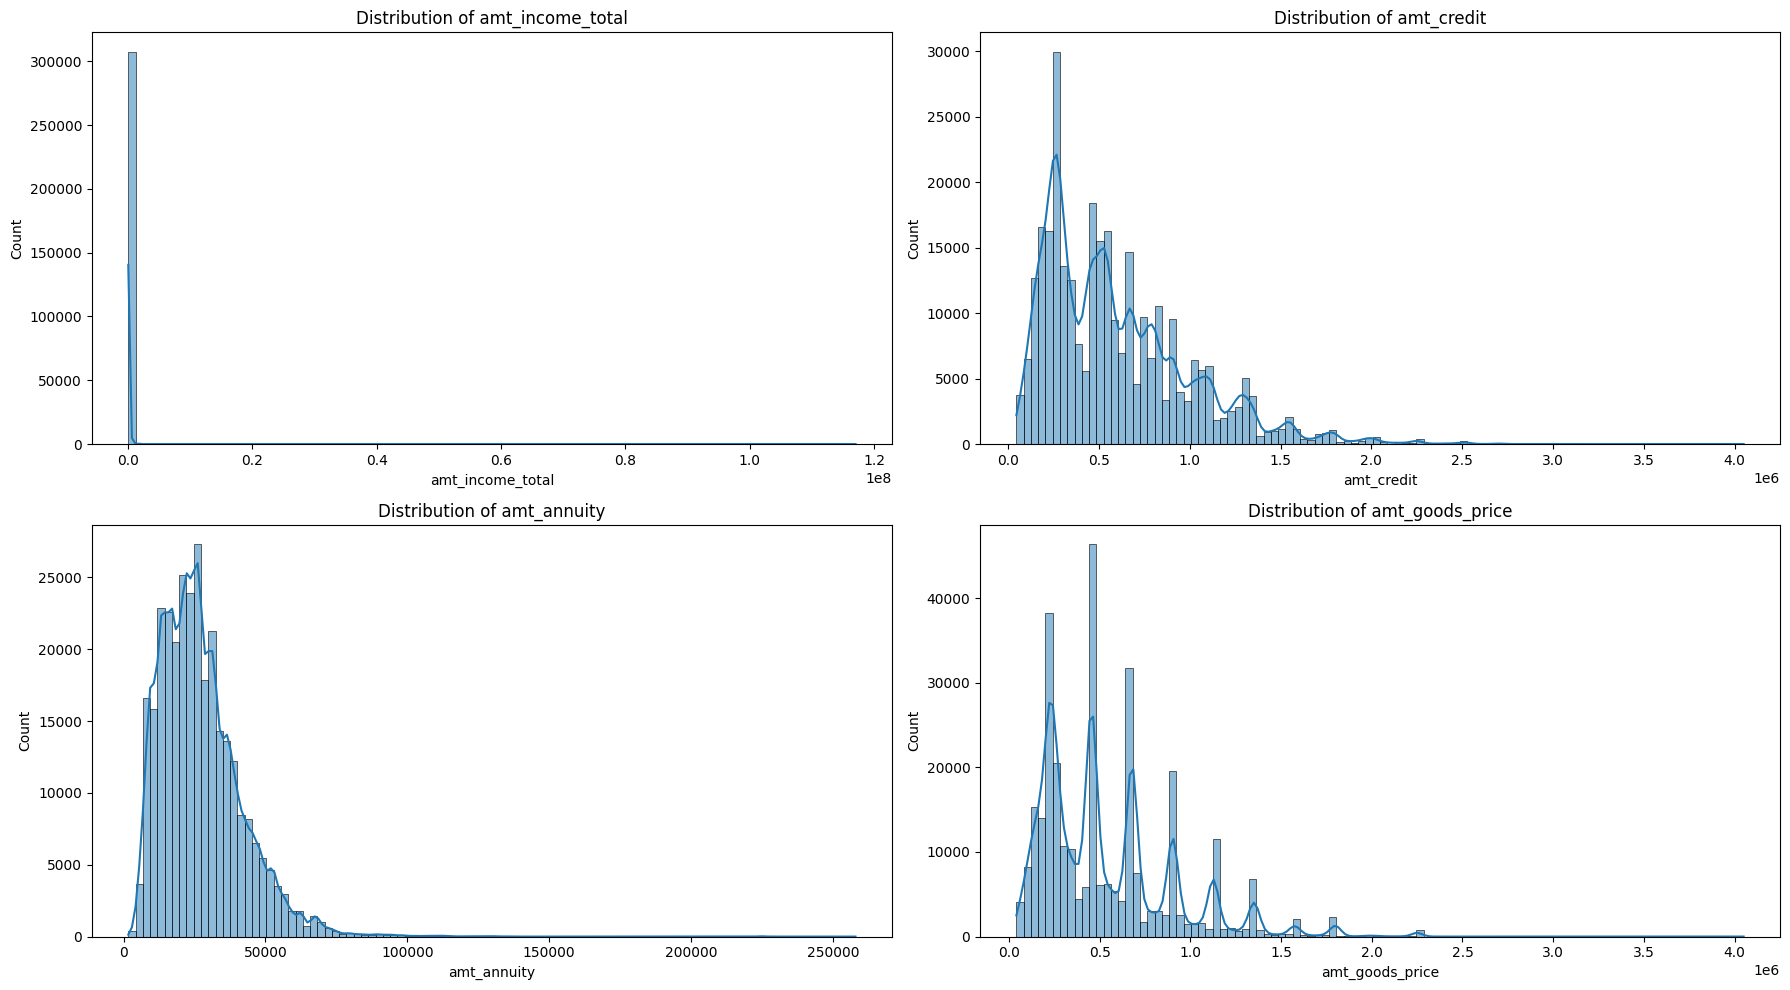

In [121]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
for ax, feature in zip(axes.flat, amt_related_features):
    sns.histplot(data=application_df, x=feature, kde=True,bins=100,ax=ax)
    ax.set_title(f'Distribution of {feature}')
    ax.set_xlabel(feature)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

In [122]:
application_df[amt_related_features].quantile([0.90,0.95,0.99,0.999])

,amt_income_total,amt_credit,amt_annuity,amt_goods_price
0.900,270000.0,1133748.0,45954.0,1093500.0
0.950,337500.0,1350000.0,53325.0,1305000.0
0.990,472500.0,1854000.0,70006.5,1800000.0
0.999,900000.0,2517300.0,110047.5,2250000.0


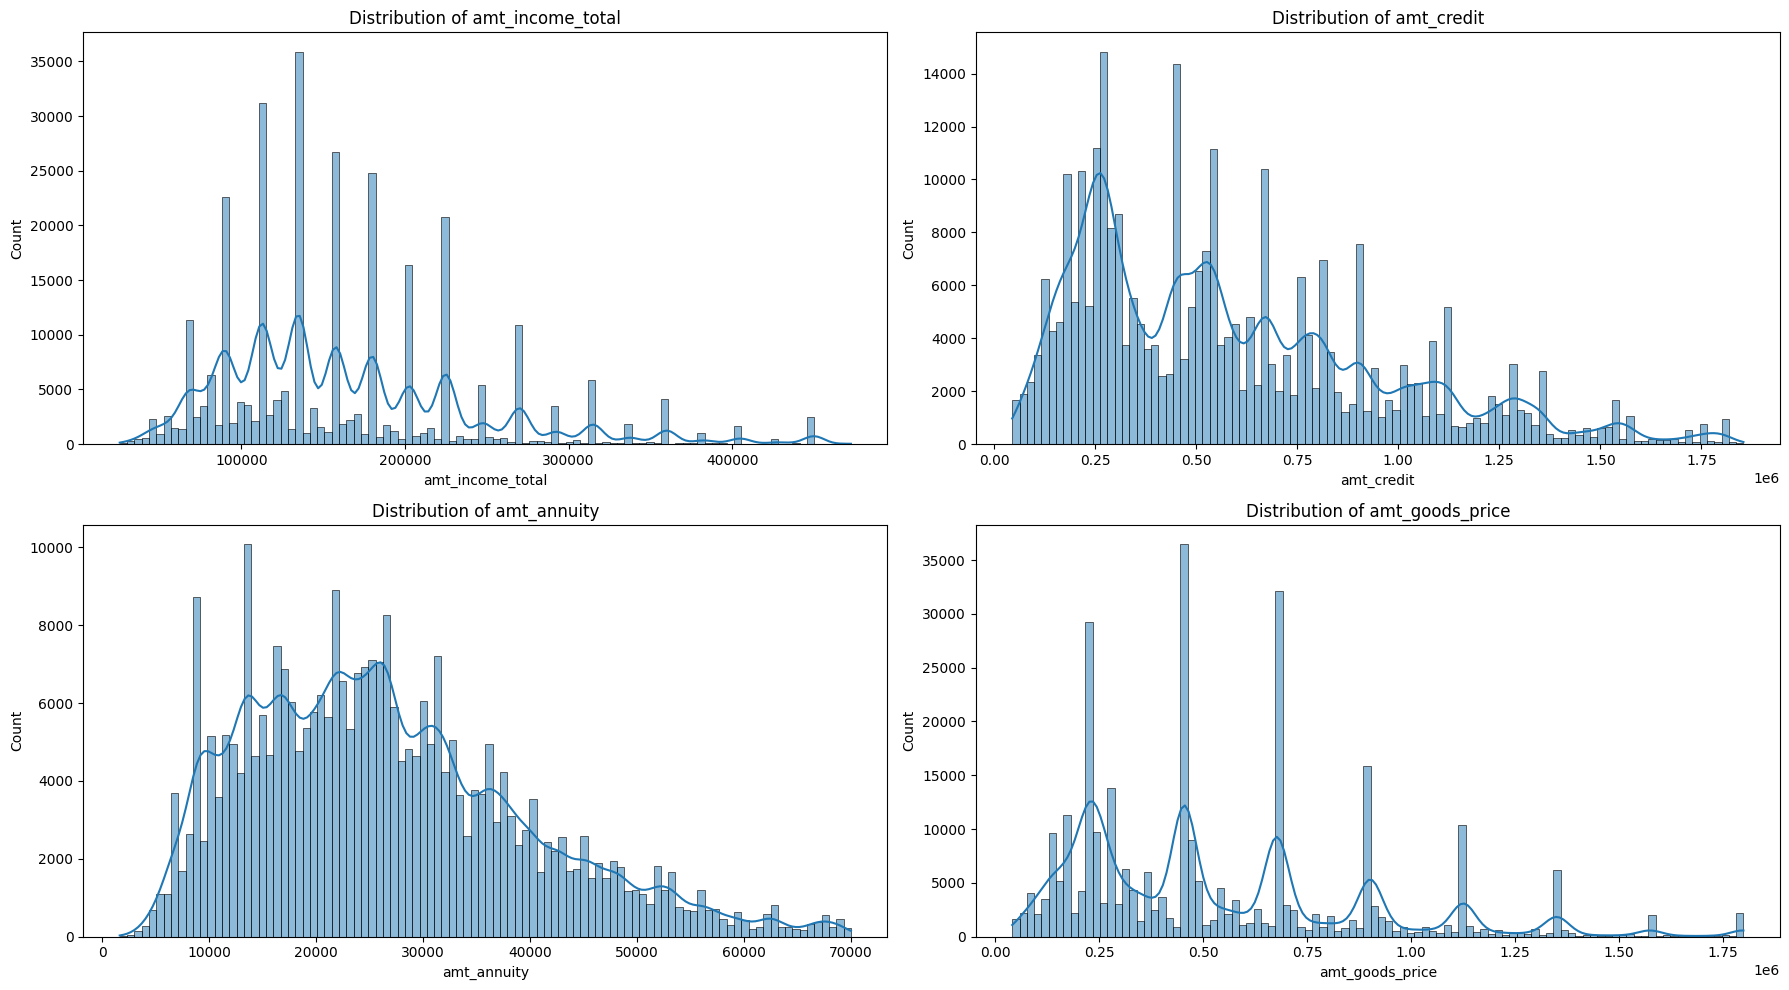

In [123]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
for ax, feature in zip(axes.flat, amt_related_features):
    quantile_99=application_df[feature].quantile(0.99)
    sns.histplot(x=application_df[feature][application_df[feature]<=quantile_99], kde=True,bins=100,ax=ax)
    ax.set_title(f'Distribution of {feature}')
    ax.set_xlabel(feature)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

In [124]:
quantile_99=application_df[amt_related_features].quantile([0.99])
quantile_99

,amt_income_total,amt_credit,amt_annuity,amt_goods_price
0.99,472500.0,1854000.0,70006.5,1800000.0


In [125]:
for feature in amt_related_features:
    quantile_99 = application_df[feature].quantile(0.99)

    count = (application_df[feature] >= quantile_99).sum()
    percentage=round((count/application_df.shape[0])*100,2)

    print(
        f'{feature}: '
        f'99th percentile = {quantile_99:.2f}, '
        f'count above = {count},'
        f'percentage={percentage}'
    )

amt_income_total: 99th percentile = 472500.00, count above = 3094,percentage=1.01
amt_credit: 99th percentile = 1854000.00, count above = 3077,percentage=1.0
amt_annuity: 99th percentile = 70006.50, count above = 3081,percentage=1.0
amt_goods_price: 99th percentile = 1800000.00, count above = 3577,percentage=1.16


In [126]:
application_df['income_bands']=pd.qcut(application_df['amt_income_total'],
                                       q=5,duplicates='drop')
application_df['income_bands'].nunique()

5

In [127]:
income_default_rate=application_df.groupby('income_bands')['target'].mean()*100
income_default_rate

C:\Users\HomePC\AppData\Local\Temp\ipykernel_22004\1070597910.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  income_default_rate=application_df.groupby('income_bands')['target'].mean()*100


income_bands
(25649.999, 99000.0]       8.206248
(99000.0, 135000.0]        8.588320
(135000.0, 162000.0]       8.684738
(162000.0, 225000.0]       8.056891
(225000.0, 117000000.0]    6.519801
Name: target, dtype: float64

In [128]:
application_df.groupby('income_bands')['target'].agg(['count','mean'])

C:\Users\HomePC\AppData\Local\Temp\ipykernel_22004\2564246920.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  application_df.groupby('income_bands')['target'].agg(['count','mean'])


,count,mean
income_bands,,
"(25649.999, 99000.0]",63671,0.082062
"(99000.0, 135000.0]",85756,0.085883
"(135000.0, 162000.0]",35453,0.086847
"(162000.0, 225000.0]",75513,0.080569
"(225000.0, 117000000.0]",47118,0.065198


In [129]:
income_summary=application_df.groupby('income_bands')['target'].agg(['count','mean','sum'])
income_summary

C:\Users\HomePC\AppData\Local\Temp\ipykernel_22004\730949703.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  income_summary=application_df.groupby('income_bands')['target'].agg(['count','mean','sum'])


,count,mean,sum
income_bands,,,
"(25649.999, 99000.0]",63671,0.082062,5225
"(99000.0, 135000.0]",85756,0.085883,7365
"(135000.0, 162000.0]",35453,0.086847,3079
"(162000.0, 225000.0]",75513,0.080569,6084
"(225000.0, 117000000.0]",47118,0.065198,3072


In [130]:
application_df['income_high_bands'] = pd.cut(
    application_df['amt_income_total'],
    bins=[225000, 300000, 500000, 1000000, float('inf')]
)

application_df.groupby(
    'income_high_bands',
    observed=True
)['target'].agg(['count', 'mean', 'sum'])

,count,mean,sum
income_high_bands,,,
"(225000.0, 300000.0]",24379,0.070512,1719
"(300000.0, 500000.0]",20037,0.060239,1207
"(500000.0, 1000000.0]",2452,0.054241,133
"(1000000.0, inf]",250,0.052000,13


In [131]:
application_df['credit_bands']=pd.qcut(application_df['amt_credit'],
                                       q=5,duplicates='drop')
application_df['credit_bands'].nunique()

5

In [132]:
application_df.groupby(
    'credit_bands',
    observed=True
)['target'].agg(['count', 'mean', 'sum'])

,count,mean,sum
credit_bands,,,
"(44999.999, 254700.0]",64925,0.072376,4699
"(254700.0, 432000.0]",58098,0.091724,5329
"(432000.0, 604152.0]",61552,0.100549,6189
"(604152.0, 900000.0]",64024,0.078549,5029
"(900000.0, 4050000.0]",58912,0.060752,3579


In [133]:
credit_default_rate=round(application_df.groupby('credit_bands')['target'].mean()*100,2)
credit_default_rate

C:\Users\HomePC\AppData\Local\Temp\ipykernel_22004\880012043.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  credit_default_rate=round(application_df.groupby('credit_bands')['target'].mean()*100,2)


credit_bands
(44999.999, 254700.0]     7.24
(254700.0, 432000.0]      9.17
(432000.0, 604152.0]     10.05
(604152.0, 900000.0]      7.85
(900000.0, 4050000.0]     6.08
Name: target, dtype: float64

In [134]:
income_default_rate=round(application_df.groupby('income_bands')['target'].mean()*100,2)
income_default_rate

C:\Users\HomePC\AppData\Local\Temp\ipykernel_22004\1437078014.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  income_default_rate=round(application_df.groupby('income_bands')['target'].mean()*100,2)


income_bands
(25649.999, 99000.0]       8.21
(99000.0, 135000.0]        8.59
(135000.0, 162000.0]       8.68
(162000.0, 225000.0]       8.06
(225000.0, 117000000.0]    6.52
Name: target, dtype: float64

In [135]:
overall_default_rate = application_df['target'].mean() * 100

credit_summary = application_df.groupby('credit_bands')['target'].agg(
    count='count',
    defaulters='sum',
    default_rate='mean'
)

credit_summary['default_rate'] *= 100

print("Overall default rate:", overall_default_rate)
credit_summary

C:\Users\HomePC\AppData\Local\Temp\ipykernel_22004\1708212270.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  credit_summary = application_df.groupby('credit_bands')['target'].agg(


Overall default rate: 8.072881945686495


,count,defaulters,default_rate
credit_bands,,,
"(44999.999, 254700.0]",64925,4699,7.237582
"(254700.0, 432000.0]",58098,5329,9.172433
"(432000.0, 604152.0]",61552,6189,10.054913
"(604152.0, 900000.0]",64024,5029,7.854867
"(900000.0, 4050000.0]",58912,3579,6.075163


In [136]:
application_df['annuity_bands'] = pd.qcut(
    application_df['amt_annuity'],
    q=5,
    duplicates='drop'
)


In [137]:
annuity_summary = application_df.groupby(
    'annuity_bands'
)['target'].agg(['count', 'sum', 'mean'])

annuity_summary['default_rate'] = annuity_summary['mean'] * 100

annuity_summary

C:\Users\HomePC\AppData\Local\Temp\ipykernel_22004\3089730354.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  annuity_summary = application_df.groupby(


,count,sum,mean,default_rate
annuity_bands,,,,
"(1615.499, 14701.5]",61507,4274,0.069488,6.948803
"(14701.5, 21865.5]",61494,5278,0.085830,8.582951
"(21865.5, 28062.0]",61562,5412,0.087911,8.791137
"(28062.0, 37516.5]",61452,5739,0.093390,9.338996
"(37516.5, 258025.5]",61484,4122,0.067042,6.704183


In [138]:
annuity_default_rate=round(application_df.groupby('annuity_bands')['target'].mean()*100,2)
annuity_default_rate

C:\Users\HomePC\AppData\Local\Temp\ipykernel_22004\2701105240.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  annuity_default_rate=round(application_df.groupby('annuity_bands')['target'].mean()*100,2)


annuity_bands
(1615.499, 14701.5]    6.95
(14701.5, 21865.5]     8.58
(21865.5, 28062.0]     8.79
(28062.0, 37516.5]     9.34
(37516.5, 258025.5]    6.70
Name: target, dtype: float64

In [139]:
application_df['goodsprice_bands'] = pd.qcut(
    application_df['amt_goods_price'],
    q=5,
    duplicates='drop'
)


In [140]:
goodsprice_summary = application_df.groupby(
    'goodsprice_bands'
)['target'].agg(['count', 'sum', 'mean'])

goodsprice_summary['default_rate'] = goodsprice_summary['mean'] * 100

goodsprice_summary

C:\Users\HomePC\AppData\Local\Temp\ipykernel_22004\2790497643.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  goodsprice_summary = application_df.groupby(


,count,sum,mean,default_rate
goodsprice_bands,,,,
"(40499.999, 225000.0]",71454,5725,0.080121,8.012148
"(225000.0, 373500.0]",51473,4526,0.087930,8.792959
"(373500.0, 522000.0]",61527,6384,0.103759,10.375933
"(522000.0, 814500.0]",61349,4650,0.075796,7.579586
"(814500.0, 4050000.0]",61430,3519,0.057285,5.728471


In [141]:
goodsprice_default_rate=round(application_df.groupby('goodsprice_bands')['target'].mean()*100,2)
goodsprice_default_rate

C:\Users\HomePC\AppData\Local\Temp\ipykernel_22004\2016693815.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  goodsprice_default_rate=round(application_df.groupby('goodsprice_bands')['target'].mean()*100,2)


goodsprice_bands
(40499.999, 225000.0]     8.01
(225000.0, 373500.0]      8.79
(373500.0, 522000.0]     10.38
(522000.0, 814500.0]      7.58
(814500.0, 4050000.0]     5.73
Name: target, dtype: float64

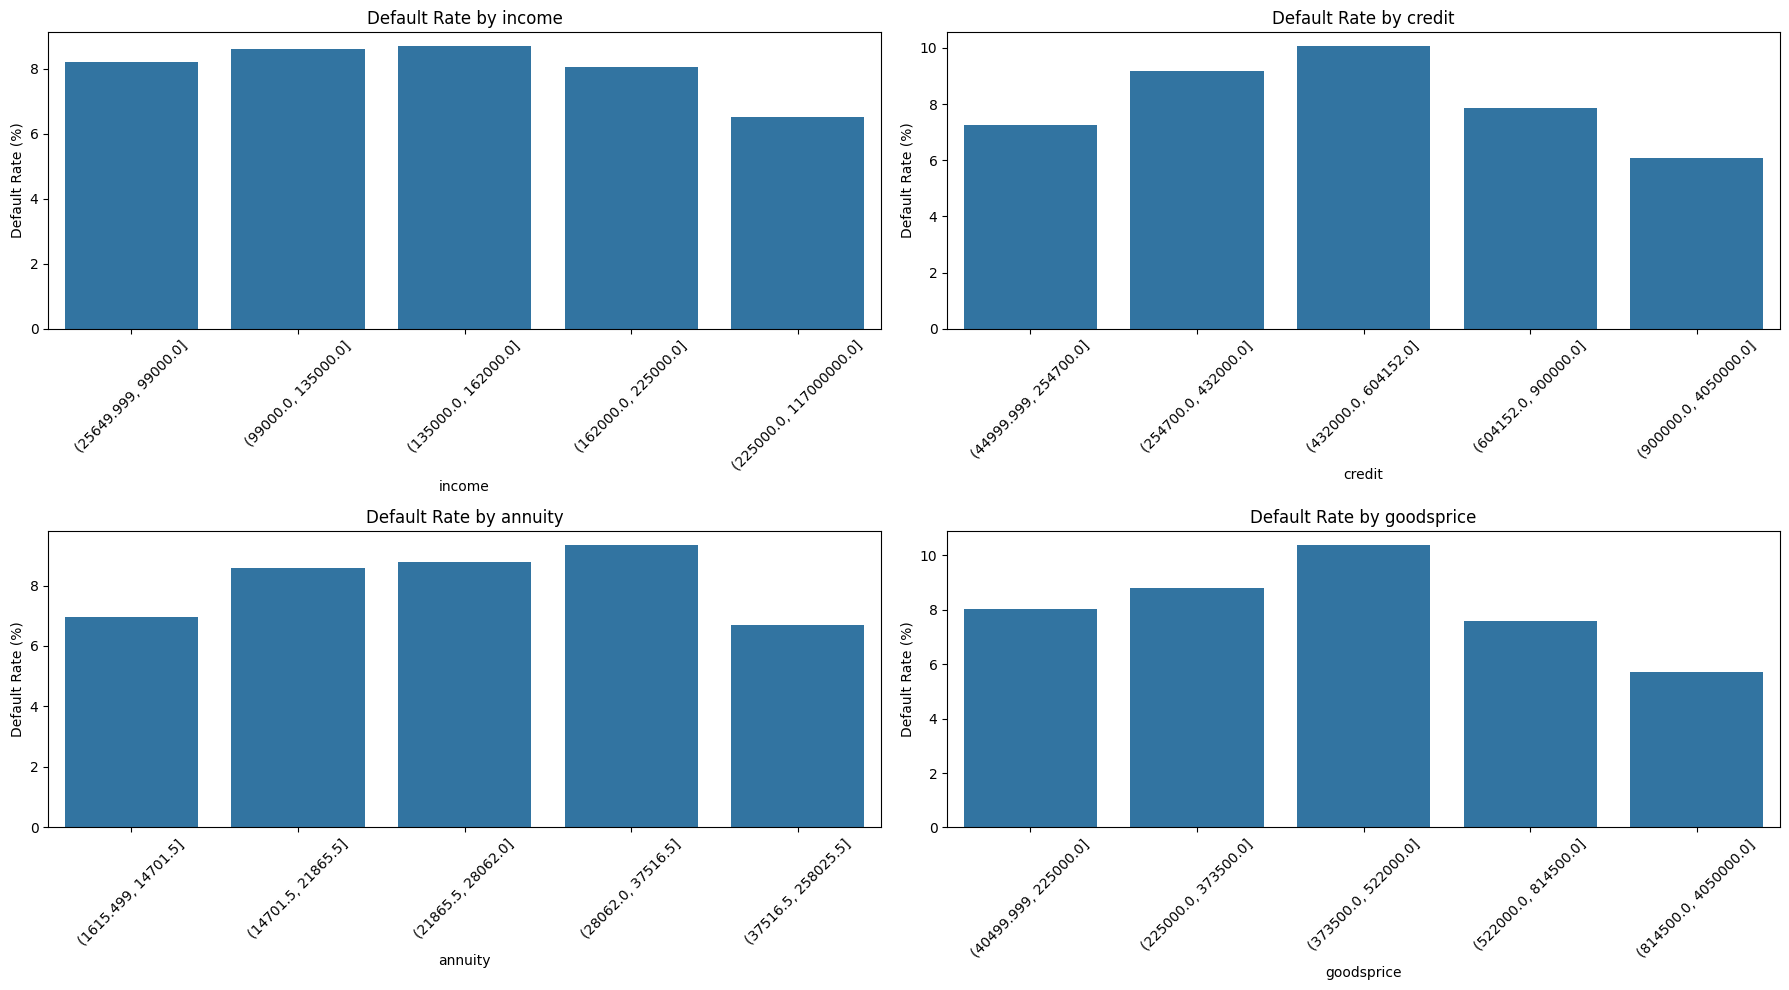

In [142]:
amt_related_group=[income_default_rate,credit_default_rate,annuity_default_rate,goodsprice_default_rate]
names=['income','credit','annuity','goodsprice']

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

for ax, group, name in zip(axes.flat, amt_related_group, names):

    sns.barplot(
        x=group.index,
        y=group.values,
        ax=ax
    )

    ax.set_title(f'Default Rate by {name}')
    ax.set_xlabel(name)
    ax.set_ylabel('Default Rate (%)')
    ax.tick_params(axis='x', rotation=45)


plt.tight_layout()
plt.show()

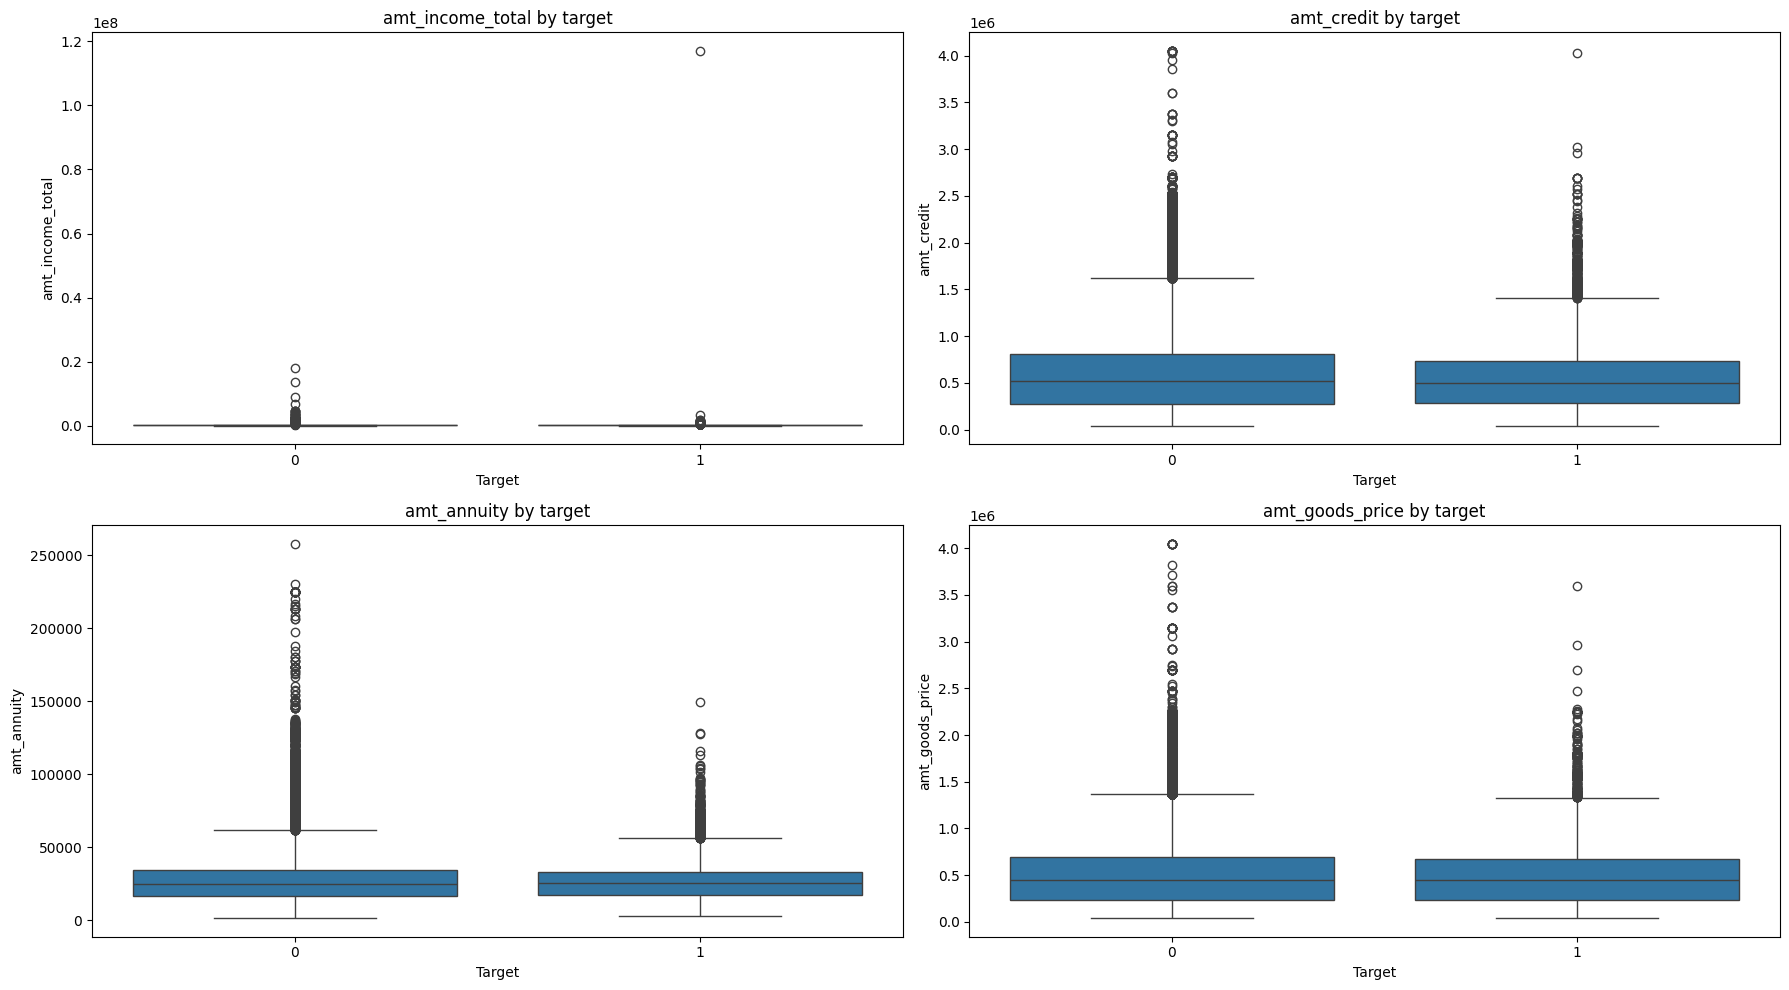

In [143]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

for ax, feature in zip(axes.flat, amt_related_features):
    sns.boxplot(
        data=application_df,
        x='target',
        y=feature,
        ax=ax
    )

    ax.set_title(f'{feature} by target')
    ax.set_xlabel('Target')
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()

## EDA: Amount-Related Features

### Features Analyzed
- `amt_income_total`
- `amt_credit`
- `amt_annuity`
- `amt_goods_price`

### 1. Data Quality & Missing Values

The amount-related features contain negligible missing values:

| Feature | Missing Values | Missing % |
|---|---:|---:|
| `amt_income_total` | 0 | 0.00% |
| `amt_credit` | 0 | 0.00% |
| `amt_annuity` | 12 | ~0.004% |
| `amt_goods_price` | 278 | ~0.09% |

Missingness is extremely low and is not a major data-quality concern for this feature group.

### 2. Distribution Analysis

All four amount-related variables are **right-skewed** and contain upper-tail observations.

- `amt_income_total` shows the most severe skewness, with a maximum value of `117,000,000`, compared with a median of `147,150`.
- `amt_credit` is right-skewed, with values extending up to `4,050,000`.
- `amt_annuity` is right-skewed, with values extending up to `258,025.5`.
- `amt_goods_price` is right-skewed, with values extending up to `4,050,000`.
- `amt_credit` and `amt_goods_price` also show several repeated/discrete values, resulting in visible peaks in their distributions.

The 99th-percentile analysis confirmed that approximately 1% of observations lie in the extreme upper tail for most features:

| Feature | 99th Percentile | Observations ≥ 99th Percentile | Percentage |
|---|---:|---:|---:|
| `amt_income_total` | 472,500 | 3,094 | 1.01% |
| `amt_credit` | 1,854,000 | 3,077 | 1.00% |
| `amt_annuity` | 70,006.5 | 3,081 | 1.00% |
| `amt_goods_price` | 1,800,000 | 3,577 | 1.16% |

The extreme values were retained during EDA because they may represent legitimate customers rather than data errors.

### 3. Default Rate Analysis

Quantile-based analysis was performed using `qcut()` to investigate how default risk changes across different ranges of each feature.

#### `amt_income_total`

Default rates across income bands:

- ₹25.6K–₹99K → **8.21%**
- ₹99K–₹135K → **8.59%**
- ₹135K–₹162K → **8.68%**
- ₹162K–₹225K → **8.06%**
- ₹225K+ → **6.52%**

Default rates are relatively stable across the lower and middle income ranges. However, default risk declines among higher-income customers.

Further investigation of the upper-income range showed a consistent decline:

- ₹225K–₹300K → **7.05%**
- ₹300K–₹500K → **6.02%**
- ₹500K–₹1M → **5.42%**
- ₹1M+ → **5.20%**

This suggests that higher income is associated with lower observed default risk, particularly in the upper-income range.

#### `amt_credit`

Default rates:

- ₹45K–₹254.7K → **7.24%**
- ₹254.7K–₹432K → **9.17%**
- ₹432K–₹604.2K → **10.05%**
- ₹604.2K–₹900K → **7.85%**
- ₹900K+ → **6.08%**

Default risk increases through the middle credit ranges, reaches its maximum at approximately ₹432K–₹604K, and then declines substantially at higher credit amounts.

This indicates a **non-linear relationship** between credit amount and default risk.

#### `amt_annuity`

Default rates:

- ₹1.6K–₹14.7K → **6.95%**
- ₹14.7K–₹21.9K → **8.58%**
- ₹21.9K–₹28.1K → **8.79%**
- ₹28.1K–₹37.5K → **9.34%**
- ₹37.5K+ → **6.70%**

Default risk generally increases with annuity amount through the first four bands, reaching a peak of **9.34%**, followed by a substantial decline in the highest band.

This also indicates a **non-linear relationship**.

#### `amt_goods_price`

Default rates:

- ₹40.5K–₹225K → **8.01%**
- ₹225K–₹373.5K → **8.79%**
- ₹373.5K–₹522K → **10.38%**
- ₹522K–₹814.5K → **7.58%**
- ₹814.5K+ → **5.73%**

Default risk increases up to the ₹373.5K–₹522K range, where it reaches the highest default rate of **10.38%**, and then declines substantially at higher goods prices.

This indicates another **non-linear relationship**.

### 4. Boxplot Analysis

Boxplots comparing `target = 0` and `target = 1` showed substantial overlap between defaulters and non-defaulters for all four amount-related variables.

Therefore:

- The overall distributions do not show strong separation between the two target classes.
- All variables contain substantial upper-tail observations.
- `amt_income_total` is particularly affected by extreme values.
- The boxplots alone do not fully capture the non-linear default-rate patterns identified through quantile-based analysis.

### 5. Overall Insights

1. All amount-related variables are **right-skewed** and contain extreme upper-tail observations.
2. Missingness is negligible for this feature group.
3. `amt_income_total` shows a relatively stable default rate across lower/middle income groups but lower default risk at higher income levels.
4. `amt_credit`, `amt_annuity`, and `amt_goods_price` show **non-linear relationships** with default risk.
5. For these three variables, default risk generally increases through the middle ranges and then declines at higher values.
6. The lower default rates observed at very high credit/annuity/goods-price levels should not be interpreted as causation. They may reflect differences in customer characteristics or credit selection.
7. Boxplots show substantial overlap between target classes, suggesting that these features alone do not provide strong class separation.
8. Extreme observations should **not be removed solely because they appear as boxplot outliers**. Their treatment will be decided later based on data validation, transformation requirements, and model performance.
9. The non-linear patterns suggest that tree-based models may be able to capture relationships that a simple linear model may not capture effectively.

### EDA Conclusion

The amount-related feature group contains potentially informative variables, particularly because several features exhibit clear non-linear relationships with default risk. Further analysis should investigate the interaction between these variables and other customer characteristics before making final feature-treatment decisions.

In [144]:
flag_related_features=[  'flag_own_car','flag_own_realty','flag_mobil','flag_emp_phone','flag_work_phone',
                         'flag_cont_mobile','flag_phone','flag_email']

In [145]:
for col in flag_related_features:
    print(f"\n{col}")
    print(application_df[col].value_counts(dropna=False))
    print(application_df[col].value_counts(normalize=True, dropna=False) * 100)


flag_own_car
flag_own_car
N    202924
Y    104587
Name: count, dtype: int64
flag_own_car
N    65.989184
Y    34.010816
Name: proportion, dtype: float64

flag_own_realty
flag_own_realty
Y    213312
N     94199
Name: count, dtype: int64
flag_own_realty
Y    69.367275
N    30.632725
Name: proportion, dtype: float64

flag_mobil
flag_mobil
1    307510
0         1
Name: count, dtype: int64
flag_mobil
1    99.999675
0     0.000325
Name: proportion, dtype: float64

flag_emp_phone
flag_emp_phone
1    252125
0     55386
Name: count, dtype: int64
flag_emp_phone
1    81.988937
0    18.011063
Name: proportion, dtype: float64

flag_work_phone
flag_work_phone
0    246203
1     61308
Name: count, dtype: int64
flag_work_phone
0    80.063152
1    19.936848
Name: proportion, dtype: float64

flag_cont_mobile
flag_cont_mobile
1    306937
0       574
Name: count, dtype: int64
flag_cont_mobile
1    99.81334
0     0.18666
Name: proportion, dtype: float64

flag_phone
flag_phone
0    221080
1     86431
Name: c

In [146]:
df=application_df.groupby('flag_own_car')['target'].agg(['count','sum'])
df['default_rate']=round((df['sum']/df['count'])*100,2)
df

,count,sum,default_rate
flag_own_car,,,
N,202924,17249,8.50
Y,104587,7576,7.24


In [147]:
for col in flag_related_features:
    print(f"\n{'='*50}")
    print(col)

    result = (
        application_df.groupby(col)['target']
          .agg(['count', 'sum'])
    )

    result['default_rate'] = result['sum'] / result['count'] * 100

    print(result)


flag_own_car
               count    sum  default_rate
flag_own_car                             
N             202924  17249      8.500227
Y             104587   7576      7.243730

flag_own_realty
                  count    sum  default_rate
flag_own_realty                             
N                 94199   7842      8.324929
Y                213312  16983      7.961577

flag_mobil
             count    sum  default_rate
flag_mobil                             
0                1      0      0.000000
1           307510  24825      8.072908

flag_emp_phone
                 count    sum  default_rate
flag_emp_phone                             
0                55386   2991      5.400282
1               252125  21834      8.659990

flag_work_phone
                  count    sum  default_rate
flag_work_phone                             
0                246203  18921      7.685122
1                 61308   5904      9.630065

flag_cont_mobile
                   count    sum  default_r

In [148]:
pd.crosstab(
    application_df['flag_emp_phone'],
    application_df['flag_work_phone'],
    values=application_df['target'],
    aggfunc='mean'
) *100

flag_work_phone,0,1
flag_emp_phone,,
0,5.400672,0.000000
1,8.348138,9.630693


In [149]:
pd.crosstab(
    application_df['flag_emp_phone'],
    application_df['flag_work_phone']
)

flag_work_phone,0,1
flag_emp_phone,,
0,55382,4
1,190821,61304


In [150]:
(application_df.groupby(['flag_emp_phone','flag_work_phone'])['target'].mean()*100).reset_index()

,flag_emp_phone,flag_work_phone,target
0,0,0,5.400672
1,0,1,0.000000
2,1,0,8.348138
3,1,1,9.630693


In [151]:
pd.crosstab(
    application_df['flag_emp_phone'],
    application_df['flag_work_phone'],
    normalize='index'
) * 100

flag_work_phone,0,1
flag_emp_phone,,
0,99.992778,0.007222
1,75.685077,24.314923


In [152]:
pd.crosstab(application_df['flag_own_car'],
            application_df['flag_own_realty'],
            values=application_df['target'],
            aggfunc='mean')*100

flag_own_realty,N,Y
flag_own_car,,
N,8.991157,8.284380
Y,7.043783,7.332781


In [153]:
pd.crosstab(application_df['flag_own_car'],
            application_df['flag_own_realty'])

flag_own_realty,N,Y
flag_own_car,,
N,61972,140952
Y,32227,72360


In [154]:
pd.crosstab(application_df['flag_phone'],
            application_df['flag_email'],
            values=application_df['target'],
            aggfunc='mean')*100

flag_email,0,1
flag_phone,,
0,8.489108,8.292602
1,7.041698,6.944703


In [155]:
pd.crosstab(application_df['flag_phone'],
            application_df['flag_email'])

flag_email,0,1
flag_phone,,
0,209009,12071
1,81060,5371


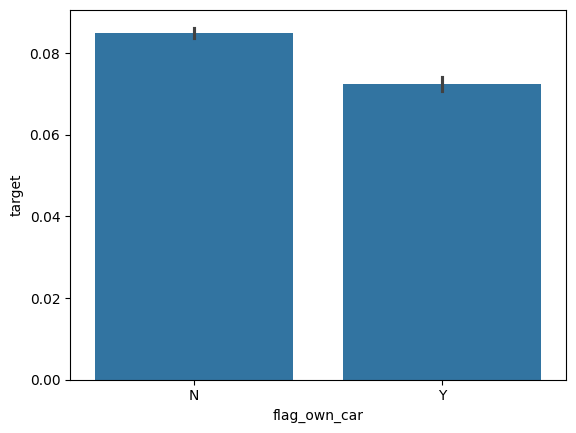

In [156]:
sns.barplot(x=application_df['flag_own_car'],y=application_df['target'],estimator='mean')
plt.show()

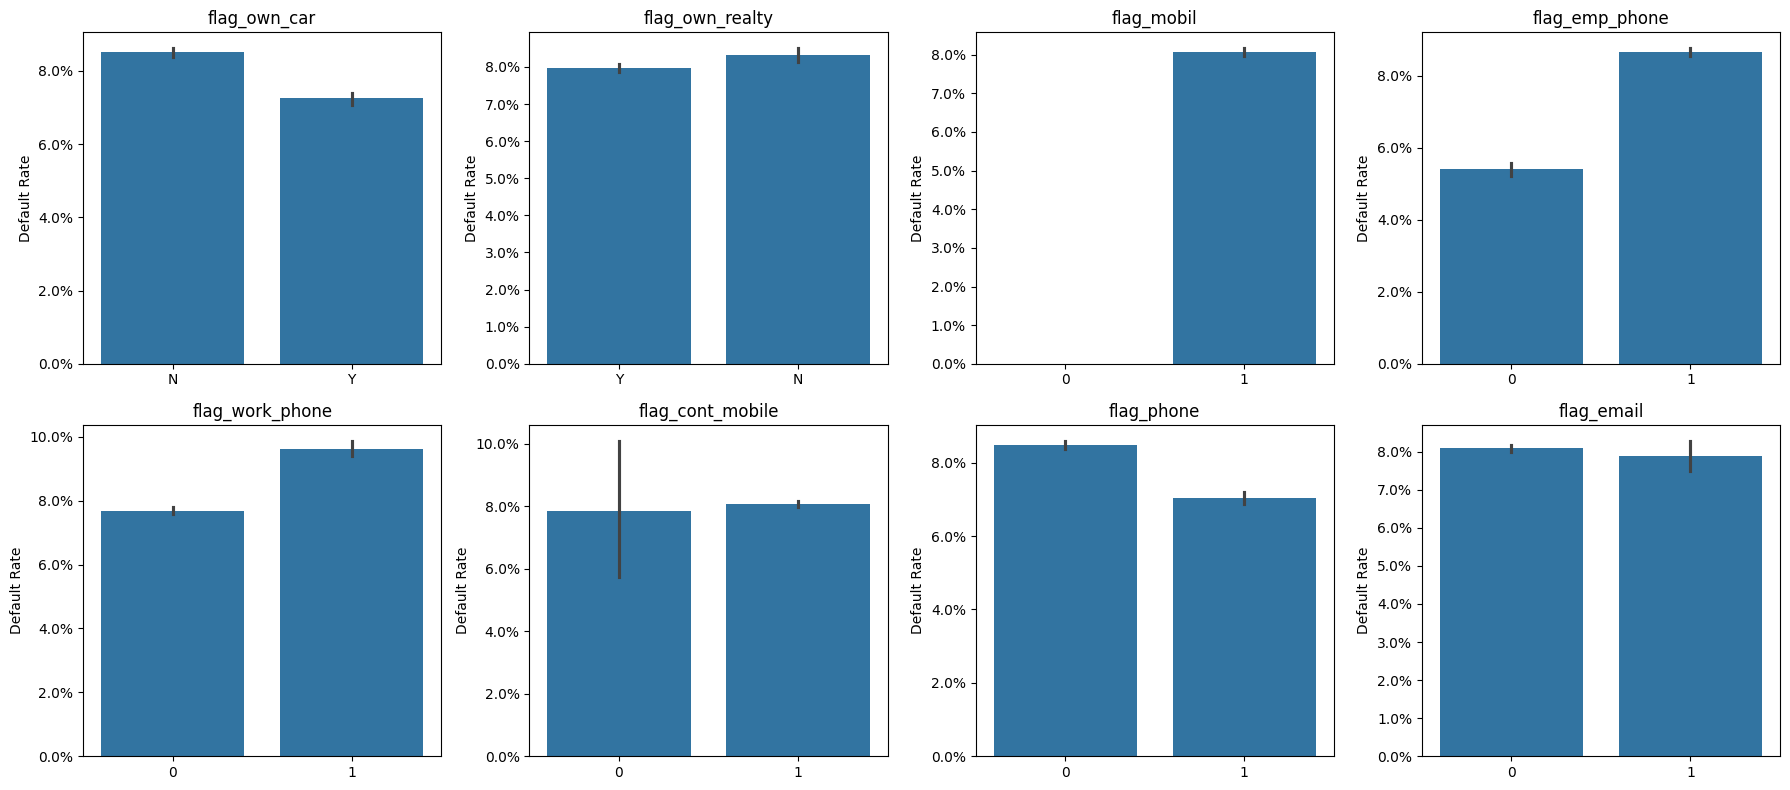

In [157]:
from matplotlib.ticker import PercentFormatter

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

axes = axes.flatten()

for ax, col in zip(axes, flag_related_features):

    sns.barplot(
        data=application_df,
        x=col,
        y='target',
        estimator='mean',
        ax=ax
    )

    ax.set_title(col)
    ax.set_xlabel('')
    ax.set_ylabel('Default Rate')
    ax.yaxis.set_major_formatter(PercentFormatter(1))

plt.tight_layout()
plt.show()

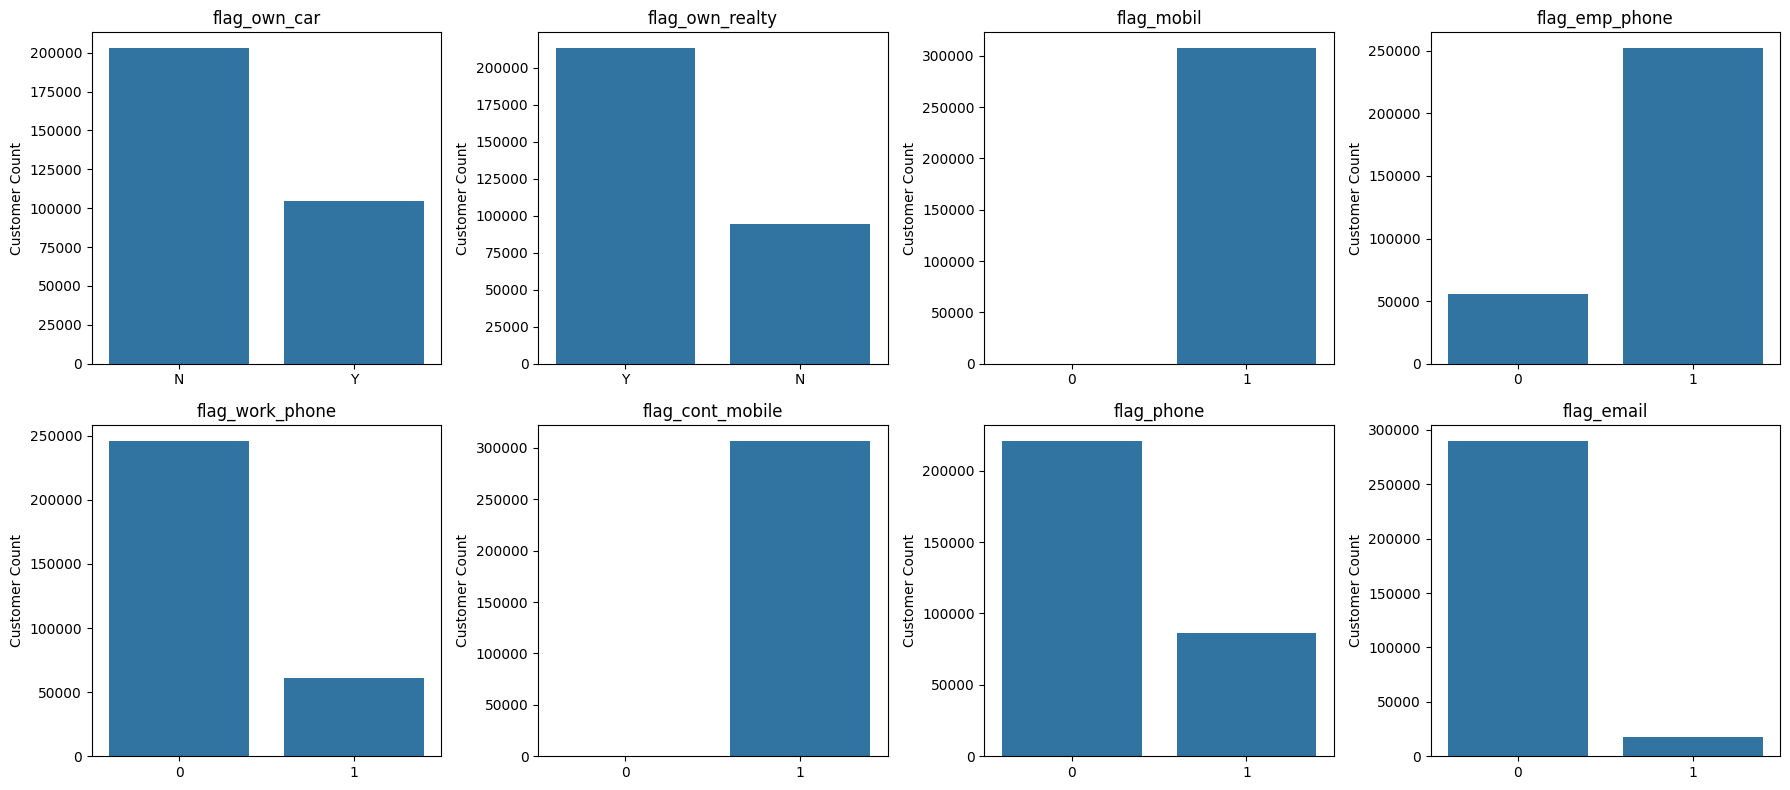

In [158]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

axes = axes.flatten()

for ax, col in zip(axes, flag_related_features):

    sns.countplot(
        data=application_df,
        x=col,
        ax=ax
    )

    ax.set_title(col)
    ax.set_xlabel('')
    ax.set_ylabel('Customer Count')

plt.tight_layout()
plt.show()

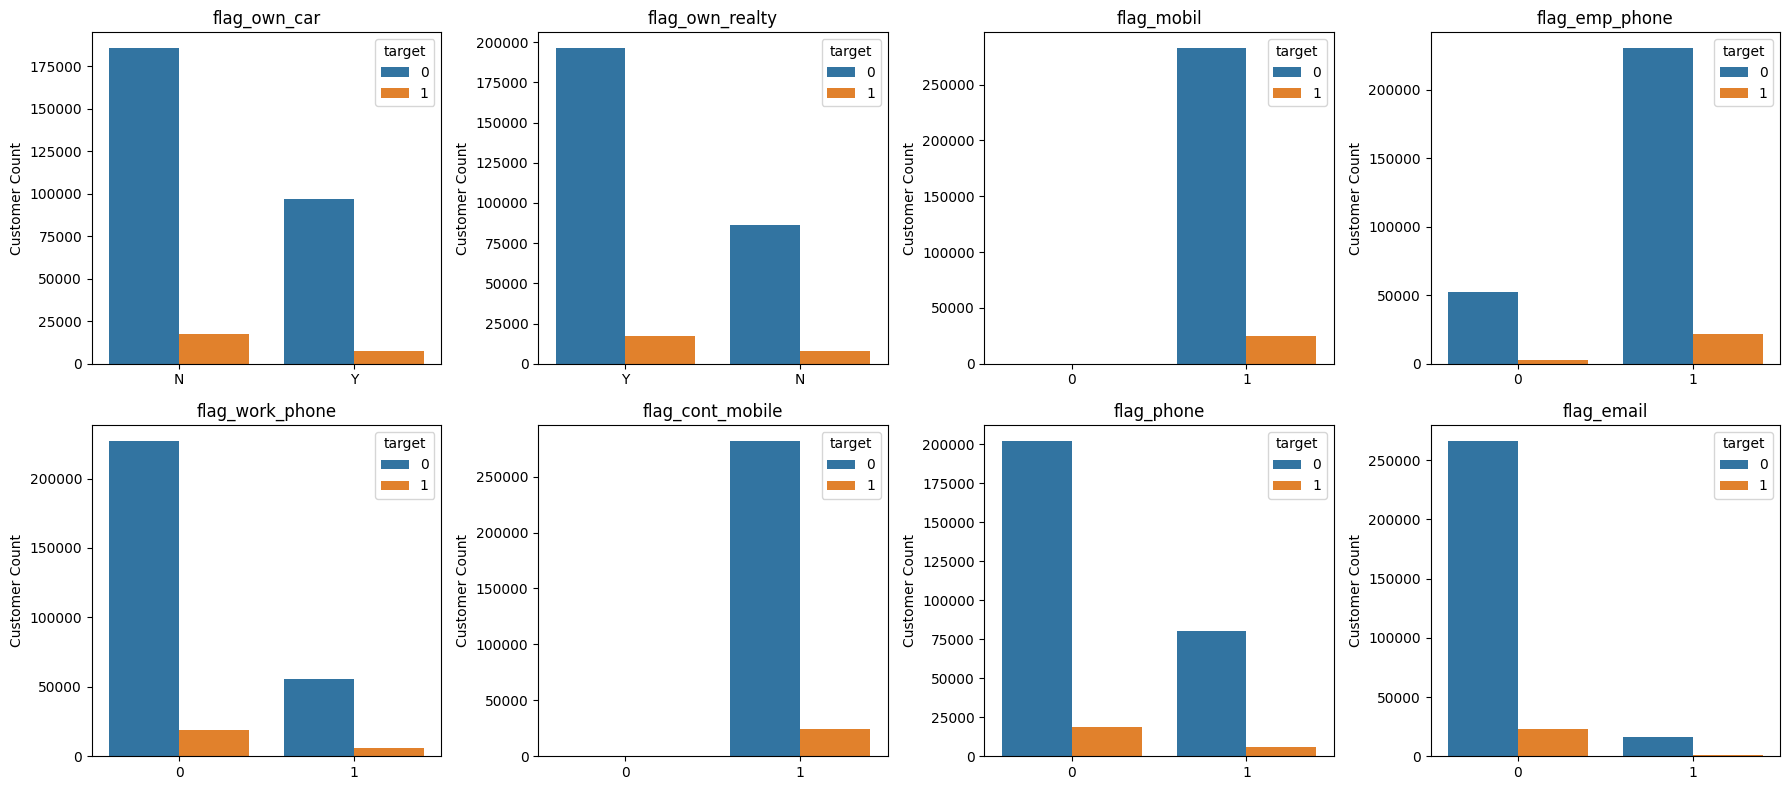

In [159]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

axes = axes.flatten()

for ax, col in zip(axes, flag_related_features):

    sns.countplot(
        data=application_df,
        x=col,
        hue='target',
        ax=ax
    )

    ax.set_title(col)
    ax.set_xlabel('')
    ax.set_ylabel('Customer Count')

plt.tight_layout()
plt.show()

## Flag-Related Features — EDA Findings

The flag-related features were analyzed using category distributions, default-rate comparisons, and selected interaction analysis.

### Key Findings

- **`flag_own_car`**
  - Car ownership shows a noticeable association with default risk.
  - Customers without a car have a higher default rate (~8.50%) compared with car owners (~7.24%).
  - Both categories have sufficient observations.
  - **Conclusion:** Potentially useful predictive feature.

- **`flag_own_realty`**
  - Realty ownership shows only a weak association with default.
  - Default rates are relatively close between non-owners (~8.32%) and owners (~7.96%).
  - **Conclusion:** Weak standalone signal; retain for further modeling evaluation.

- **`flag_mobil`**
  - Extremely imbalanced: almost every customer has the flag set to 1, with only one observation having value 0.
  - The feature has virtually no variation.
  - **Conclusion:** Near-constant feature and a strong candidate for removal during feature selection.

- **`flag_emp_phone`**
  - Shows the strongest default-rate separation within this feature group.
  - Default rate is substantially higher for customers with `flag_emp_phone = 1` (~8.66%) than for those with `0` (~5.40%).
  - Although imbalanced, both categories contain sufficient observations.
  - **Conclusion:** Strong candidate for retention.

- **`flag_work_phone`**
  - Customers with a work phone have a higher default rate (~9.63%) than those without one (~7.69%).
  - Both categories have sufficient observations.
  - **Conclusion:** Potentially useful predictive feature.

- **`flag_cont_mobile`**
  - Extremely imbalanced, with more than 99% of observations having value 1.
  - Default rates are almost identical between the two categories (~7.84% vs ~8.07%).
  - **Conclusion:** Very weak signal combined with extreme imbalance; strong candidate for removal.

- **`flag_phone`**
  - Shows a meaningful association with default risk.
  - Customers with the phone flag set to 1 have a lower default rate (~7.04%) compared with those having 0 (~8.48%).
  - Both categories have substantial observations.
  - **Conclusion:** Potentially useful predictive feature.

- **`flag_email`**
  - Highly imbalanced, with approximately 94% of customers having value 0.
  - Default rates are almost identical (~8.08% vs ~7.88%).
  - **Conclusion:** Weak standalone signal; retain for now and allow later feature selection/modeling to determine its usefulness.

### Interaction Analysis

- **`flag_emp_phone` × `flag_work_phone`**
  - The combination shows increasing default rates from customers having neither flag to customers having both.
  - The `emp_phone=0, work_phone=1` group contains only 4 customers, so its 0% default rate is not statistically reliable.
  - The remaining groups have substantial sample sizes, with the `emp_phone=1, work_phone=1` group showing the highest meaningful default rate (~9.63%).

- **`flag_own_car` × `flag_own_realty`**
  - Customers with neither car nor realty ownership have the highest default rate (~8.99%).
  - Car ownership appears to provide a stronger risk separation than realty ownership.
  - The interaction between the two features appears relatively weak.

- **`flag_phone` × `flag_email`**
  - Phone status shows a substantially stronger relationship with default than email status.
  - Adding the email flag produces only a small change in default rate within either phone category.
  - No strong interaction effect was observed.

### Overall Conclusion

The most promising features in this group based on EDA are:

`flag_emp_phone`, `flag_work_phone`, `flag_phone`, and `flag_own_car`.

`flag_own_realty` and `flag_email` show weaker standalone signals but will be retained for further modeling evaluation.

`flag_mobil` and `flag_cont_mobile` show extremely low variation and weak/no risk separation, making them strong candidates for removal during the feature-selection stage.

> **Note:** These conclusions are based on univariate and selected bivariate EDA. Final feature removal will be decided later using feature selection, model performance, and business considerations.

In [160]:
application_df.shape

(307511, 127)

In [161]:
col_list=application_df.columns.tolist()
col_list

['sk_id_curr',
 'target',
 'name_contract_type',
 'code_gender',
 'flag_own_car',
 'flag_own_realty',
 'cnt_children',
 'amt_income_total',
 'amt_credit',
 'amt_annuity',
 'amt_goods_price',
 'name_type_suite',
 'name_income_type',
 'name_education_type',
 'name_family_status',
 'name_housing_type',
 'region_population_relative',
 'days_birth',
 'days_employed',
 'days_registration',
 'days_id_publish',
 'own_car_age',
 'flag_mobil',
 'flag_emp_phone',
 'flag_work_phone',
 'flag_cont_mobile',
 'flag_phone',
 'flag_email',
 'occupation_type',
 'cnt_fam_members',
 'region_rating_client',
 'region_rating_client_w_city',
 'weekday_appr_process_start',
 'hour_appr_process_start',
 'reg_region_not_live_region',
 'reg_region_not_work_region',
 'live_region_not_work_region',
 'reg_city_not_live_city',
 'reg_city_not_work_city',
 'live_city_not_work_city',
 'organization_type',
 'ext_source_1',
 'ext_source_2',
 'ext_source_3',
 'apartments_avg',
 'basementarea_avg',
 'years_beginexpluatation_a

In [162]:
application_df.drop(['income_bands',
 'income_high_bands',
 'credit_bands',
 'annuity_bands',
 'goodsprice_bands'],axis=1,inplace=True)

In [163]:
application_df.shape

(307511, 122)

In [164]:
family_features=['cnt_children','cnt_fam_members']

In [165]:
application_df[family_features].isnull().sum()

cnt_children       0
cnt_fam_members    2
dtype: int64

In [166]:
application_df[family_features].describe().T

,count,mean,std,min,25%,50%,75%,max
cnt_children,307511.0,0.417052,0.722121,0.0,0.0,0.0,1.0,19.0
cnt_fam_members,307509.0,2.152665,0.910682,1.0,2.0,2.0,3.0,20.0


In [167]:
for col in family_features:
    print(f"\n{'='*50}")
    print(col)
    print(application_df[col].value_counts(dropna=False).sort_index())


cnt_children
cnt_children
0     215371
1      61119
2      26749
3       3717
4        429
5         84
6         21
7          7
8          2
9          2
10         2
11         1
12         2
14         3
19         2
Name: count, dtype: int64

cnt_fam_members
cnt_fam_members
1.0      67847
2.0     158357
3.0      52601
4.0      24697
5.0       3478
6.0        408
7.0         81
8.0         20
9.0          6
10.0         3
11.0         1
12.0         2
13.0         1
14.0         2
15.0         1
16.0         2
20.0         2
NaN          2
Name: count, dtype: int64


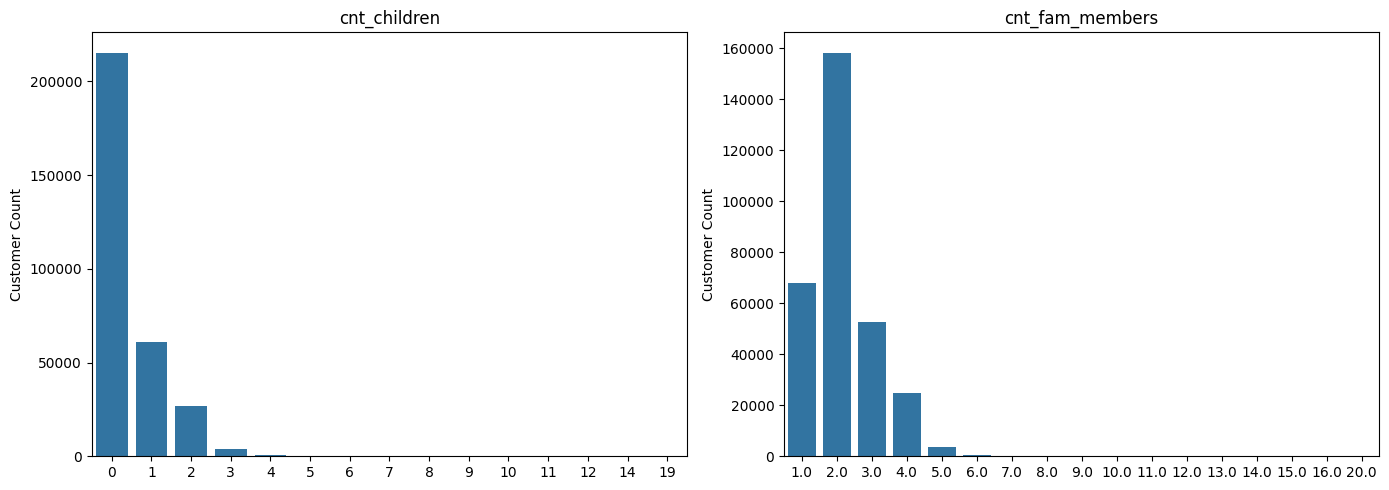

In [168]:
family_features = ['cnt_children', 'cnt_fam_members']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, family_features):

    sns.countplot(
        data=application_df,
        x=col,
        ax=ax
    )

    ax.set_title(col)
    ax.set_xlabel('')
    ax.set_ylabel('Customer Count')

plt.tight_layout()
plt.show()

In [169]:
for col in family_features:
    print(f"\n{'='*50}")
    print(col)

    result = (
        application_df.groupby(col)['target']
          .agg(['count', 'sum'])
    )

    result['default_rate'] = result['sum'] / result['count'] * 100

    print(result)


cnt_children
               count    sum  default_rate
cnt_children                             
0             215371  16609      7.711809
1              61119   5454      8.923575
2              26749   2333      8.721821
3               3717    358      9.631423
4                429     55     12.820513
5                 84      7      8.333333
6                 21      6     28.571429
7                  7      0      0.000000
8                  2      0      0.000000
9                  2      2    100.000000
10                 2      0      0.000000
11                 1      1    100.000000
12                 2      0      0.000000
14                 3      0      0.000000
19                 2      0      0.000000

cnt_fam_members
                  count    sum  default_rate
cnt_fam_members                             
1.0               67847   5675      8.364408
2.0              158357  12009      7.583498
3.0               52601   4608      8.760290
4.0               24697   2136

In [170]:
application_df['children_group'] = pd.cut(
    application_df['cnt_children'],
    bins=[-1, 0, 1, 2, 3, float('inf')],
    labels=['0', '1', '2', '3', '4+']
)

In [171]:
application_df['family_group'] = pd.cut(
    application_df['cnt_fam_members'],
    bins=[0, 1, 2, 3, 4, float('inf')],
    labels=['1', '2', '3', '4', '5+']
)

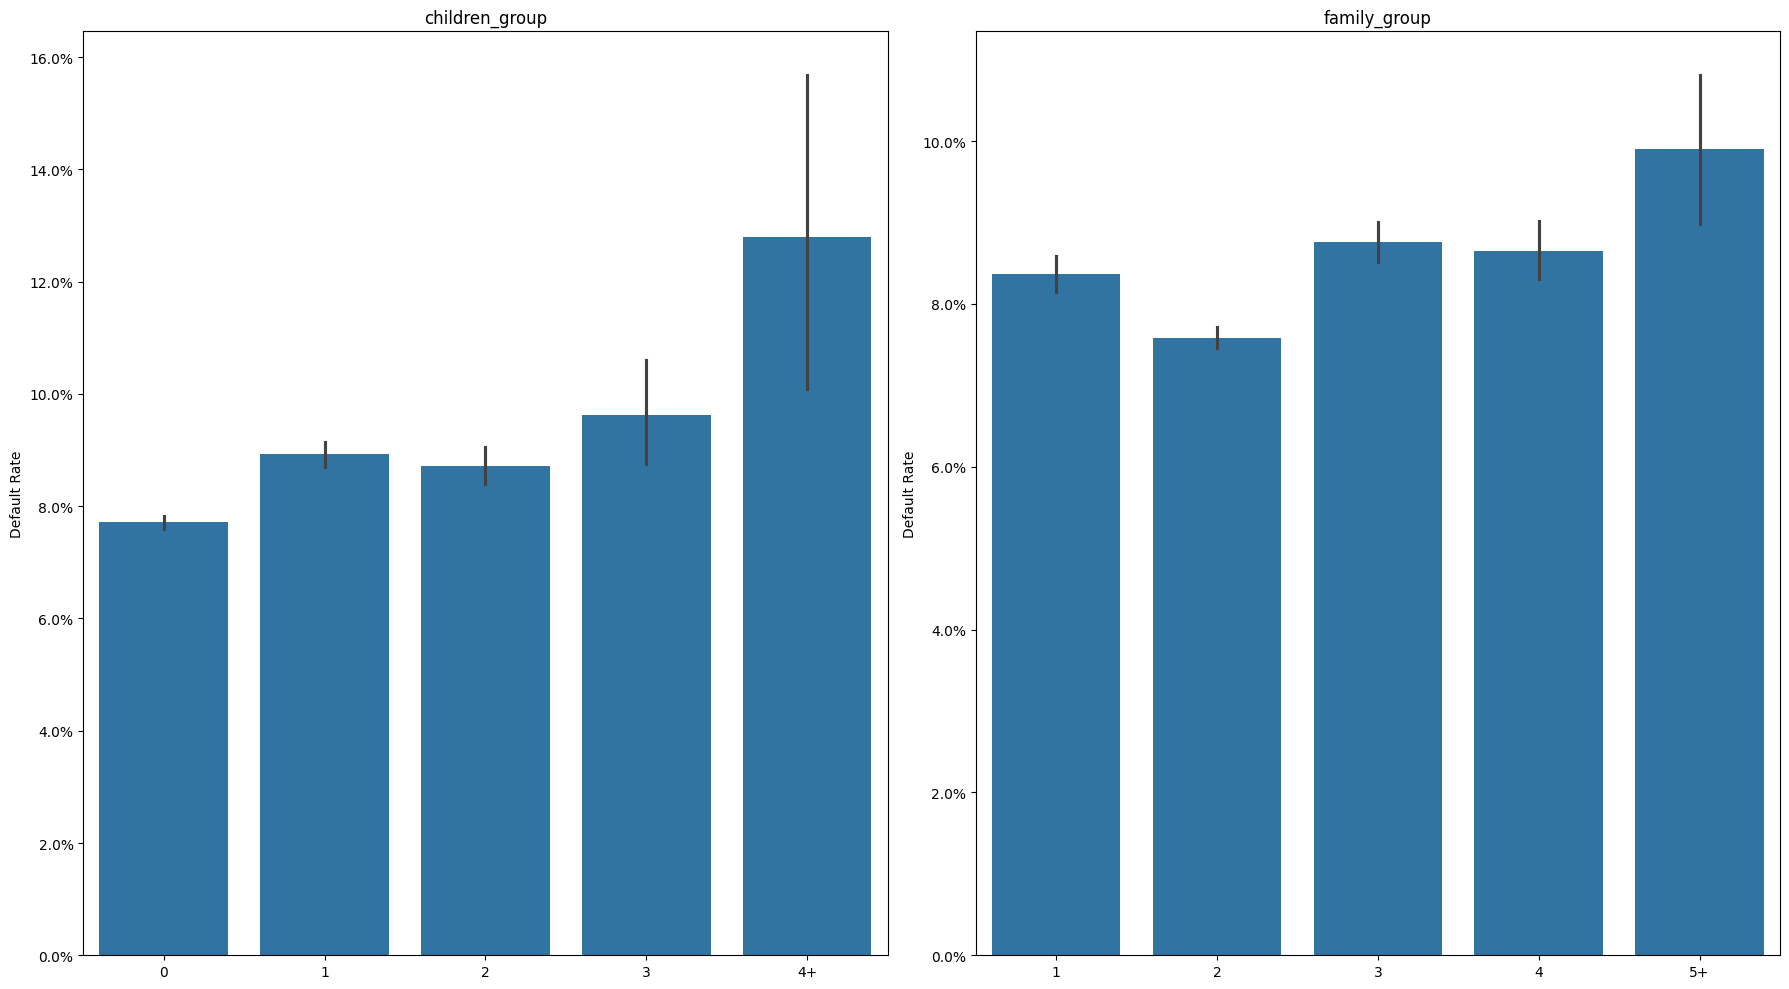

In [172]:
family_group=['children_group','family_group']
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

axes = axes.flatten()

for ax, col in zip(axes, family_group):

    sns.barplot(
        data=application_df,
        x=col,
        y='target',
        estimator='mean',
        ax=ax
    )

    ax.set_title(col)
    ax.set_xlabel('')
    ax.set_ylabel('Default Rate')
    ax.yaxis.set_major_formatter(PercentFormatter(1))

plt.tight_layout()
plt.show()

In [173]:
application_df[family_features].corr()

,cnt_children,cnt_fam_members
cnt_children,1.000000,0.879161
cnt_fam_members,0.879161,1.000000


## Family-Related Features — EDA Findings

- `cnt_children` is strongly right-skewed, with approximately 70% of customers having no children. Higher child-count groups generally show higher default rates, with the `4+` group showing the highest stable observed default rate.
- `cnt_fam_members` is also right-skewed, with 2-member families being the dominant group. Larger family sizes generally show somewhat higher default rates, although the pattern is less consistent than for `cnt_children`.
- Rare high-count categories produce unstable default-rate estimates due to very small sample sizes; therefore, grouped categories were used for EDA interpretation.
- `cnt_children` has no missing values.
- `cnt_fam_members` has only 2 missing values, which is negligible relative to the dataset size.
- `cnt_children` and `cnt_fam_members` have a strong positive correlation of **0.879**, indicating substantial overlap in the information captured by the two variables.
- Both features appear potentially useful for predicting default, but their individual and combined contribution should be evaluated during feature selection/modeling because of their high correlation.

### Overall Conclusion

The family-related features show a meaningful relationship with default risk, particularly `cnt_children`. However, the strong correlation between `cnt_children` and `cnt_fam_members` suggests that they capture overlapping household information. No significant missing-value issue was identified.

In [174]:
flag_document_features=[col for col in application_df.columns if col.startswith('flag_document')]
print(len(flag_document_features))

20


In [175]:
flag_document_features

['flag_document_2',
 'flag_document_3',
 'flag_document_4',
 'flag_document_5',
 'flag_document_6',
 'flag_document_7',
 'flag_document_8',
 'flag_document_9',
 'flag_document_10',
 'flag_document_11',
 'flag_document_12',
 'flag_document_13',
 'flag_document_14',
 'flag_document_15',
 'flag_document_16',
 'flag_document_17',
 'flag_document_18',
 'flag_document_19',
 'flag_document_20',
 'flag_document_21']

In [176]:
application_df[flag_document_features].isnull().sum()

flag_document_2     0
flag_document_3     0
flag_document_4     0
flag_document_5     0
flag_document_6     0
flag_document_7     0
flag_document_8     0
flag_document_9     0
flag_document_10    0
flag_document_11    0
flag_document_12    0
flag_document_13    0
flag_document_14    0
flag_document_15    0
flag_document_16    0
flag_document_17    0
flag_document_18    0
flag_document_19    0
flag_document_20    0
flag_document_21    0
dtype: int64

In [177]:
application_df['flag_document_2'].isna().sum()

np.int64(0)

In [178]:
document_summary=pd.DataFrame({'count1':[application_df[col].sum() for col in flag_document_features],
                               'count0':[(application_df[col]==0).sum() for col in flag_document_features],
                               'percentage1':[application_df[col].mean()*100 for col in flag_document_features],
                               'defaultrate0':[application_df.loc[application_df[col]==0,'target'].mean()*100
                                               for col in flag_document_features],
                               'defaultrate1':[application_df.loc[application_df[col]==1,'target'].mean()*100
                                               for col in flag_document_features]},index=flag_document_features)
document_summary
                               

,count1,count0,percentage1,defaultrate0,defaultrate1
flag_document_2,13,307498,0.004227,8.071922,30.769231
flag_document_3,218340,89171,71.002338,6.182503,8.844921
flag_document_4,25,307486,0.008130,8.073538,0.000000
flag_document_5,4648,302863,1.511491,8.073948,8.003442
flag_document_6,27078,280433,8.805539,8.314999,5.565404
flag_document_7,59,307452,0.019186,8.073455,5.084746
flag_document_8,25024,282487,8.137595,8.138074,7.336957
flag_document_9,1198,306313,0.389580,8.080297,6.176962
flag_document_10,7,307504,0.002276,8.073066,0.000000
flag_document_11,1203,306308,0.391206,8.080102,6.234414


In [179]:
document_summary['default_count1'] = [
    application_df.loc[
        application_df[col] == 1, 'target'
    ].sum()
    for col in flag_document_features
]

document_summary['default_count0'] = [
    application_df.loc[
        application_df[col] == 0, 'target'
    ].sum()
    for col in flag_document_features
]
document_summary

,count1,count0,percentage1,defaultrate0,defaultrate1,default_count1,default_count0
flag_document_2,13,307498,0.004227,8.071922,30.769231,4,24821
flag_document_3,218340,89171,71.002338,6.182503,8.844921,19312,5513
flag_document_4,25,307486,0.008130,8.073538,0.000000,0,24825
flag_document_5,4648,302863,1.511491,8.073948,8.003442,372,24453
flag_document_6,27078,280433,8.805539,8.314999,5.565404,1507,23318
flag_document_7,59,307452,0.019186,8.073455,5.084746,3,24822
flag_document_8,25024,282487,8.137595,8.138074,7.336957,1836,22989
flag_document_9,1198,306313,0.389580,8.080297,6.176962,74,24751
flag_document_10,7,307504,0.002276,8.073066,0.000000,0,24825
flag_document_11,1203,306308,0.391206,8.080102,6.234414,75,24750


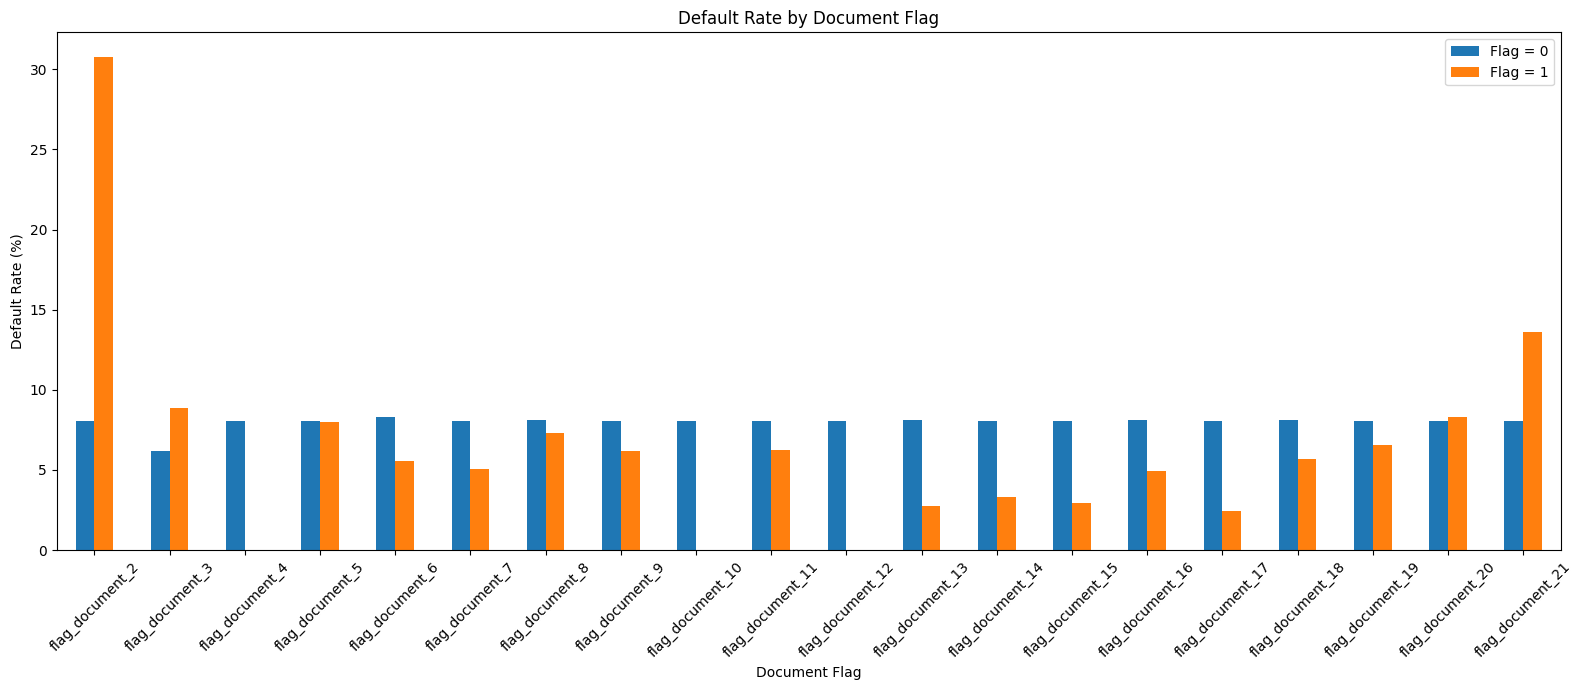

In [180]:
document_default_rates = document_summary[
    ['defaultrate0', 'defaultrate1']
]

document_default_rates.plot(
    kind='bar',
    figsize=(16, 7)
)

plt.ylabel('Default Rate (%)')
plt.xlabel('Document Flag')
plt.title('Default Rate by Document Flag')
plt.xticks(rotation=45)
plt.legend(['Flag = 0', 'Flag = 1'])
plt.tight_layout()
plt.show()

## Document Flag Features — EDA Findings

### Features Analyzed
The following document-related binary flags were analyzed:

`flag_document_2` to `flag_document_21`

The analysis focused on:
- Frequency of applicants with each document flag = 1
- Default rate for flag = 0 vs. flag = 1
- Number of defaulters supporting each observed rate
- Visual comparison of default rates

### Key Findings

1. **Most document flags are highly imbalanced**
   - Several document flags are extremely rare, with fewer than 100 applicants having a value of 1.
   - Therefore, apparently high or low default rates for these features should not be considered reliable based solely on the observed percentage.

2. **`flag_document_3` shows meaningful predictive potential**
   - Present for approximately **71% of applicants**.
   - Default rate:
     - Flag = 0 → **6.18%**
     - Flag = 1 → **8.84%**
   - The relationship is supported by a large number of observations and defaults.
   - **Decision: KEEP**

3. **`flag_document_6` shows a potentially useful risk-reducing relationship**
   - Present for approximately **8.81% of applicants**.
   - Default rate:
     - Flag = 0 → **8.31%**
     - Flag = 1 → **5.57%**
   - The difference is supported by more than 27,000 applicants in the flag = 1 group.
   - **Decision: KEEP**

4. **`flag_document_8` shows only a weak relationship**
   - Default rate:
     - Flag = 0 → **8.14%**
     - Flag = 1 → **7.34%**
   - Although the sample size is sufficient, the separation is relatively small.
   - **Decision: Weak candidate / investigate further if required**

5. **`flag_document_5`, `flag_document_9`, and `flag_document_11` show weak univariate relationships**
   - Their default rates between flag = 0 and flag = 1 are relatively close.
   - **Decision: Weak candidates for predictive value**

6. **`flag_document_13`, `flag_document_14`, `flag_document_15`, `flag_document_16`, and `flag_document_18` show lower default rates when the document flag is present**
   - These features show potentially interesting negative associations with default.
   - However, their flag = 1 groups are much smaller than `flag_document_3` and `flag_document_6`.
   - **Decision: Potential candidates; validate during modeling/feature selection**

7. **Extremely rare document flags should not be considered reliable based on their default rates**
   - Features such as `flag_document_2`, `flag_document_4`, `flag_document_7`, `flag_document_10`, `flag_document_12`, `flag_document_17`, `flag_document_19`, `flag_document_20`, and `flag_document_21` have very small flag = 1 populations.
   - Some show apparently large differences in default rate, but these are based on very few observations.
   - Example: `flag_document_2` has a 30.77% default rate, but this comes from only **13 applicants and 4 defaulters**.
   - **Decision: Strong drop candidates due to extreme rarity, subject to final feature-selection validation**

### Overall Conclusion

The document flag group contains substantial redundancy and severe class imbalance.

The strongest candidates identified during EDA are:

- `flag_document_3`
- `flag_document_6`

Several moderately populated features (`flag_document_8`, `flag_document_13`, `flag_document_14`, `flag_document_15`, `flag_document_16`, and `flag_document_18`) may contain additional predictive information and can be validated during subsequent feature selection/modeling.

Extremely rare document flags are unlikely to provide stable predictive information and are strong candidates for removal.

> **Important:** EDA findings represent univariate associations and do not establish causation. Final feature inclusion/removal will be confirmed through model-based feature selection and validation.

In [183]:
social_features=['obs_30_cnt_social_circle','def_30_cnt_social_circle','obs_60_cnt_social_circle',
 'def_60_cnt_social_circle']



In [185]:
application_df[social_features].head(10)

,obs_30_cnt_social_circle,def_30_cnt_social_circle,obs_60_cnt_social_circle,def_60_cnt_social_circle
0,2.0,2.0,2.0,2.0
1,1.0,0.0,1.0,0.0
2,0.0,0.0,0.0,0.0
3,2.0,0.0,2.0,0.0
4,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0
6,1.0,0.0,1.0,0.0
7,2.0,0.0,2.0,0.0
8,1.0,0.0,1.0,0.0
9,2.0,0.0,2.0,0.0


In [186]:
application_df[social_features].describe().T

,count,mean,std,min,25%,50%,75%,max
obs_30_cnt_social_circle,306490.0,1.422245,2.400989,0.0,0.0,0.0,2.0,348.0
def_30_cnt_social_circle,306490.0,0.143421,0.446698,0.0,0.0,0.0,0.0,34.0
obs_60_cnt_social_circle,306490.0,1.405292,2.379803,0.0,0.0,0.0,2.0,344.0
def_60_cnt_social_circle,306490.0,0.100049,0.362291,0.0,0.0,0.0,0.0,24.0


In [187]:
application_df[social_features].isnull().sum()

obs_30_cnt_social_circle    1021
def_30_cnt_social_circle    1021
obs_60_cnt_social_circle    1021
def_60_cnt_social_circle    1021
dtype: int64

In [188]:
application_df.shape

(307511, 124)

In [191]:
application_df.drop(['children_group','family_group'],axis=1,inplace=True)

In [192]:
application_df.shape

(307511, 122)

In [194]:
application_df['def_30_group']=pd.cut(application_df['def_30_cnt_social_circle'],
                                      bins=[-1,0,1,2,float('inf')],
                                      labels=['0','1','2','2 and above'])
application_df['def_30_group'].head()
                                            
                                            

0    2
1    0
2    0
3    0
4    0
Name: def_30_group, dtype: category
Categories (4, object): ['0' < '1' < '2' < '2 and above']

In [195]:
application_df.groupby('def_30_group')['target'].agg(['count','mean'])

C:\Users\HomePC\AppData\Local\Temp\ipykernel_22004\3226563169.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  application_df.groupby('def_30_group')['target'].agg(['count','mean'])


,count,mean
def_30_group,,
0,271324,0.077759
1,28328,0.101454
2,5323,0.116476
2 and above,1515,0.130033


In [196]:
application_df['def_60_group']=pd.cut(application_df['def_60_cnt_social_circle'],
                                      bins=[-1,0,float('inf')],
                                      labels=['0','above 0'])
application_df['def_60_group'].head()
                                      

0    above 0
1          0
2          0
3          0
4          0
Name: def_60_group, dtype: category
Categories (2, object): ['0' < 'above 0']

In [197]:
application_df.groupby('def_60_group')['target'].agg(['count','mean'])

C:\Users\HomePC\AppData\Local\Temp\ipykernel_22004\2123278292.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  application_df.groupby('def_60_group')['target'].agg(['count','mean'])


,count,mean
def_60_group,,
0,280721,0.078348
above 0,25769,0.108464


In [198]:
application_df['obs_30_group']=pd.cut(application_df['obs_30_cnt_social_circle'],
                                      bins=[-1,0,1,2,float('inf')],
                                      labels=['0','1','2','2 and above'])
application_df['obs_30_group'].head()
                                            

0    2
1    1
2    0
3    2
4    0
Name: obs_30_group, dtype: category
Categories (4, object): ['0' < '1' < '2' < '2 and above']

In [199]:
application_df.groupby('obs_30_group')['target'].agg(['count','mean'])

C:\Users\HomePC\AppData\Local\Temp\ipykernel_22004\3030826509.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  application_df.groupby('obs_30_group')['target'].agg(['count','mean'])


,count,mean
obs_30_group,,
0,163910,0.079007
1,48783,0.079843
2,29808,0.082461
2 and above,63989,0.085733


In [200]:
application_df['obs_60_group']=pd.cut(application_df['obs_60_cnt_social_circle'],
                                      bins=[-1,0,1,2,float('inf')],
                                      labels=['0','1','2','2 and above'])
application_df['obs_60_group'].head()
                                            

0    2
1    1
2    0
3    2
4    0
Name: obs_60_group, dtype: category
Categories (4, object): ['0' < '1' < '2' < '2 and above']

In [201]:
application_df.groupby('obs_60_group')['target'].agg(['count','mean'])

C:\Users\HomePC\AppData\Local\Temp\ipykernel_22004\3365916177.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  application_df.groupby('obs_60_group')['target'].agg(['count','mean'])


,count,mean
obs_60_group,,
0,164666,0.079075
1,48870,0.079681
2,29766,0.082241
2 and above,63188,0.085871


In [203]:
application_df[social_features].corr()

,obs_30_cnt_social_circle,def_30_cnt_social_circle,obs_60_cnt_social_circle,def_60_cnt_social_circle
obs_30_cnt_social_circle,1.000000,0.329338,0.998490,0.253499
def_30_cnt_social_circle,0.329338,1.000000,0.331571,0.860517
obs_60_cnt_social_circle,0.998490,0.331571,1.000000,0.255570
def_60_cnt_social_circle,0.253499,0.860517,0.255570,1.000000


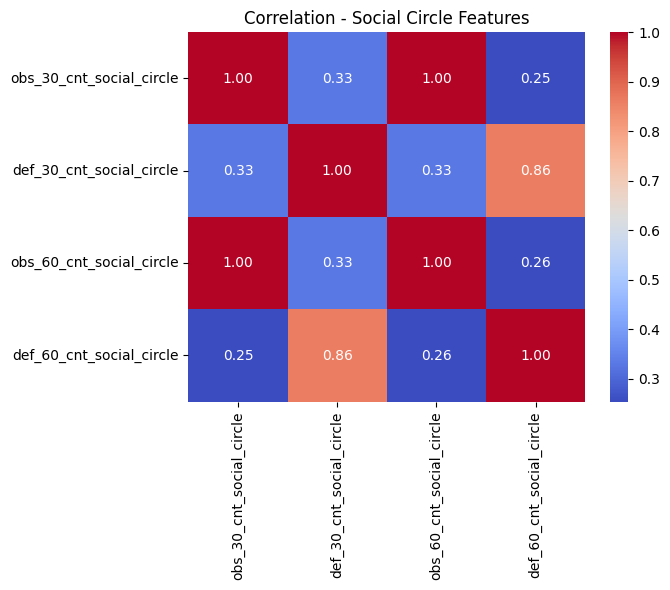

In [205]:
sns.heatmap(
    application_df[social_features].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Correlation - Social Circle Features')
plt.show()

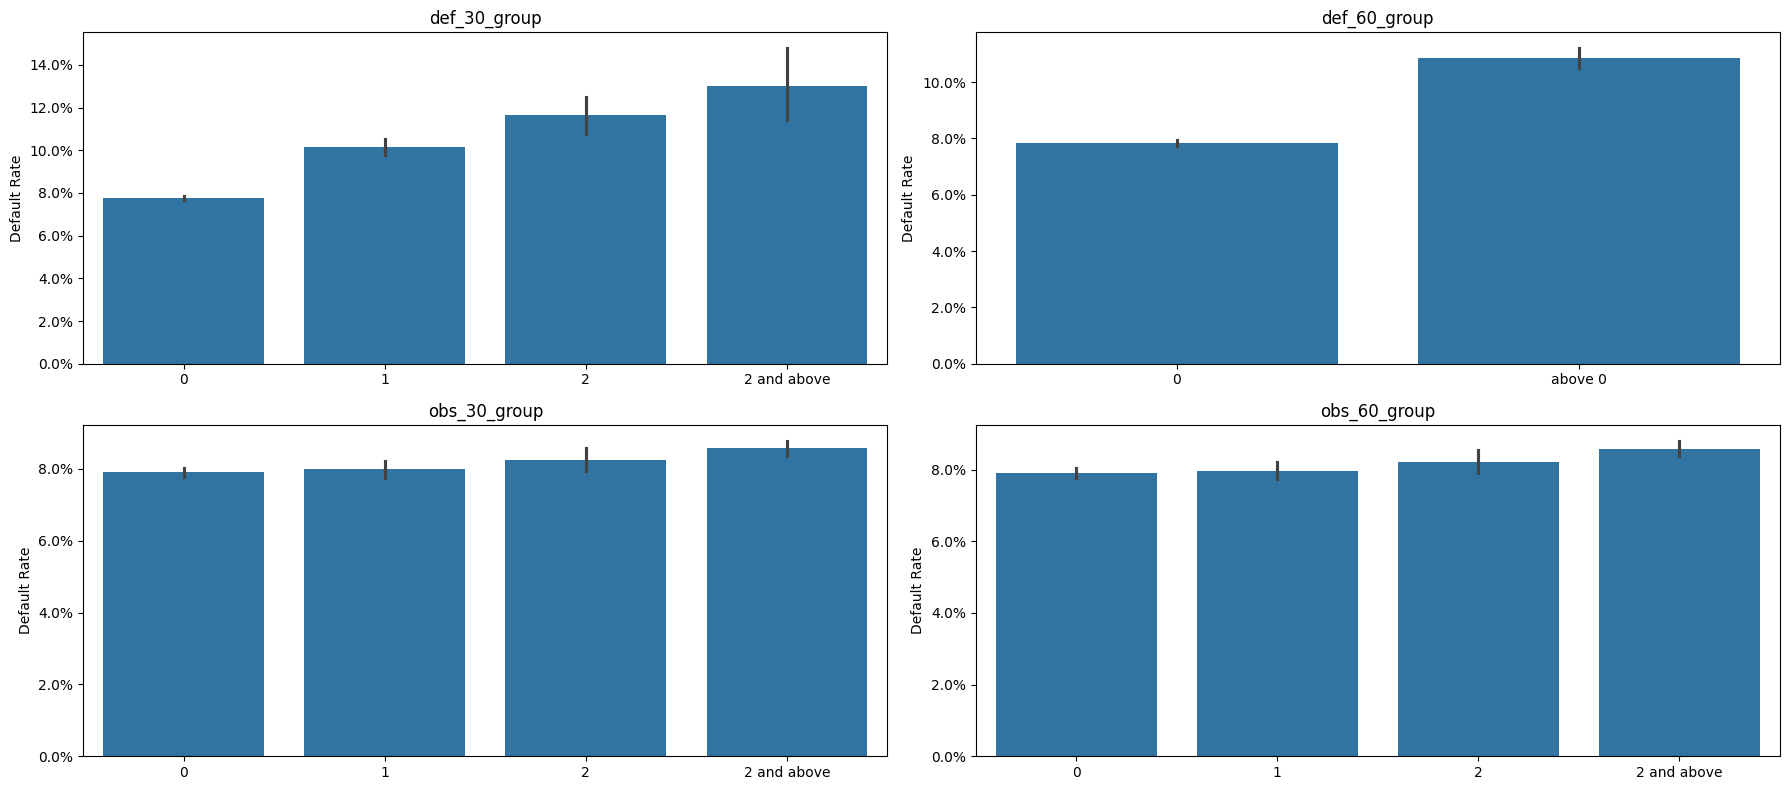

In [208]:
social_group=['def_30_group','def_60_group','obs_30_group','obs_60_group']
fig, axes = plt.subplots(2, 2, figsize=(18, 8))

axes = axes.flatten()

for ax, col in zip(axes, social_group):

    sns.barplot(
        data=application_df,
        x=col,
        y='target',
        estimator='mean',
        ax=ax
    )

    ax.set_title(col)
    ax.set_xlabel('')
    ax.set_ylabel('Default Rate')
    ax.yaxis.set_major_formatter(PercentFormatter(1))

plt.tight_layout()
plt.show()

## Social Circle Features — EDA Findings

The social-circle feature group consists of:

- `obs_30_cnt_social_circle`
- `def_30_cnt_social_circle`
- `obs_60_cnt_social_circle`
- `def_60_cnt_social_circle`

### Missing Values
All four features contain **1,021 missing values**, representing approximately **0.33%** of the dataset. Therefore, missingness is relatively low and can be handled during the data-preprocessing stage.

### Distribution
The features are highly right-skewed, with most customers having zero or very few social-circle observations/defaults. The observed-count variables have particularly large maximum values compared with their median values.

### Target Relationship

#### `def_30_cnt_social_circle`
Default rate increases consistently with the number of 30-day defaults in the applicant's social circle:

- 0 → **7.78%**
- 1 → **10.15%**
- 2 → **11.65%**
- 2+ → **13.00%**

This indicates a strong and monotonic relationship with applicant default risk.

**Assessment: KEEP**

#### `def_60_cnt_social_circle`
Customers with at least one 60-day default in their social circle have a higher default rate:

- 0 → **7.83%**
- Above 0 → **10.85%**

This indicates a meaningful relationship with default risk.

**Assessment: KEEP CANDIDATE**

#### `obs_30_cnt_social_circle`
Default rate shows only a weak increase:

- 0 → **7.90%**
- 1 → **7.98%**
- 2 → **8.25%**
- 2+ → **8.57%**

The feature provides a weak but monotonic signal.

**Assessment: KEEP CANDIDATE**

#### `obs_60_cnt_social_circle`
Default rate is very similar to `obs_30_cnt_social_circle`:

- 0 → **7.91%**
- 1 → **7.97%**
- 2 → **8.22%**
- 2+ → **8.59%**

The feature provides only a weak signal.

**Assessment: REMOVE**

### Correlation Analysis

Correlation analysis identified substantial redundancy:

- `obs_30_cnt_social_circle` ↔ `obs_60_cnt_social_circle` = **0.9985**
- `def_30_cnt_social_circle` ↔ `def_60_cnt_social_circle` = **0.8605**

The two `obs_*` variables are almost identical and provide nearly the same target relationship. Therefore, retaining both would introduce unnecessary redundancy.

The two `def_*` variables are highly correlated but represent different delinquency windows and show meaningful relationships with the target. `def_30_cnt_social_circle` shows the stronger univariate signal.

### Final EDA Decision

| Feature | EDA Finding | Decision |
|---|---|---|
| `def_30_cnt_social_circle` | Strong monotonic relationship | **KEEP** |
| `def_60_cnt_social_circle` | Strong relationship | **KEEP CANDIDATE** |
| `obs_30_cnt_social_circle` | Weak monotonic relationship | **KEEP CANDIDATE** |
| `obs_60_cnt_social_circle` | Weak + highly redundant | **REMOVE** |

### Key Business Insight

> Social-circle delinquency/default behavior appears to be more informative for predicting applicant default than the number of observed social-circle records. In particular, applicants associated with a higher number of delinquent/defaulting individuals in their social circle show higher default rates.

**Conclusion:** The social-circle feature group contains useful risk information, with the strongest signal coming from the `def_*` variables. Redundant features will be handled during the final feature-selection/preprocessing stage.

In [209]:
application_df.drop(['def_30_group','def_60_group','obs_30_group','obs_60_group'],axis=1,inplace=True)

In [210]:
application_df.shape

(307511, 122)

In [211]:
ext_features=['ext_source_1','ext_source_2','ext_source_3']

In [212]:
application_df[ext_features].head()

,ext_source_1,ext_source_2,ext_source_3
0,0.083037,0.262949,0.139376
1,0.311267,0.622246,NaN
2,NaN,0.555912,0.729567
3,NaN,0.650442,NaN
4,NaN,0.322738,NaN


In [214]:
application_df[ext_features].isnull().sum()

ext_source_1    173378
ext_source_2       660
ext_source_3     60965
dtype: int64

In [215]:
application_df[ext_features].describe().T

,count,mean,std,min,25%,50%,75%,max
ext_source_1,134133.0,0.502130,0.211062,1.456813e-02,0.334007,0.505998,0.675053,0.962693
ext_source_2,306851.0,0.514393,0.191060,8.173617e-08,0.392457,0.565961,0.663617,0.855000
ext_source_3,246546.0,0.510853,0.194844,5.272652e-04,0.370650,0.535276,0.669057,0.896010


In [218]:
application_df['ext_source_1_group'] = pd.qcut(
    application_df['ext_source_1'],
    q=5,
    duplicates='drop'
)

In [219]:
application_df.groupby('ext_source_1_group', observed=True)['target'].agg(
    ['count', 'mean']
)

,count,mean
ext_source_1_group,,
"(0.013600000000000001, 0.296]",26827,0.145786
"(0.296, 0.438]",26826,0.087378
"(0.438, 0.573]",26827,0.063593
"(0.573, 0.71]",26826,0.047603
"(0.71, 0.963]",26827,0.030417


In [220]:
application_df['ext_source_2_group'] = pd.qcut(
    application_df['ext_source_2'],
    q=5,
    duplicates='drop'
)

In [221]:
application_df.groupby('ext_source_2_group', observed=True)['target'].agg(
    ['count', 'mean']
)

,count,mean
ext_source_2_group,,
"(-0.0009999183, 0.34]",61371,0.152140
"(0.34, 0.512]",61371,0.091607
"(0.512, 0.608]",61371,0.070392
"(0.608, 0.682]",61377,0.053652
"(0.682, 0.855]",61361,0.035870


In [222]:
application_df['ext_source_3_group'] = pd.qcut(
    application_df['ext_source_3'],
    q=5,
    duplicates='drop'
)

In [223]:
application_df.groupby('ext_source_3_group', observed=True)['target'].agg(
    ['count', 'mean']
)

,count,mean
ext_source_3_group,,
"(-0.000473, 0.33]",49445,0.163758
"(0.33, 0.476]",49746,0.087505
"(0.476, 0.592]",49578,0.057505
"(0.592, 0.694]",49470,0.044795
"(0.694, 0.896]",48307,0.033763


In [224]:
application_df[ext_features].corr()

,ext_source_1,ext_source_2,ext_source_3
ext_source_1,1.000000,0.213982,0.186846
ext_source_2,0.213982,1.000000,0.109167
ext_source_3,0.186846,0.109167,1.000000


In [225]:
for col in ['ext_source_1', 'ext_source_2', 'ext_source_3']:
    print(f'\n{col}')
    print(
        application_df.groupby(application_df[col].isna())['target']
        .agg(['count', 'mean'])
    )


ext_source_1
               count      mean
ext_source_1                  
False         134133  0.074955
True          173378  0.085195

ext_source_2
               count      mean
ext_source_2                  
False         306851  0.080733
True             660  0.078788

ext_source_3
               count      mean
ext_source_3                  
False         246546  0.077665
True           60965  0.093119


## External Source Features — EDA Findings

The external-source feature group consists of:

- `ext_source_1`
- `ext_source_2`
- `ext_source_3`

These features represent external risk scores and have values approximately between 0 and 1.

### Missing Values

The features have different levels of missingness:

| Feature | Missing Count | Approx. Missing % |
|---|---:|---:|
| `ext_source_1` | 173,378 | **56.4%** |
| `ext_source_2` | 660 | **0.2%** |
| `ext_source_3` | 60,965 | **19.8%** |

`ext_source_1` and `ext_source_3` have substantial missingness, while `ext_source_2` is almost complete.

### Distribution

All three features are continuous scores between approximately 0 and 1.

| Feature | Mean | Median | Std |
|---|---:|---:|---:|
| `ext_source_1` | 0.502 | 0.506 | 0.211 |
| `ext_source_2` | 0.514 | 0.566 | 0.191 |
| `ext_source_3` | 0.511 | 0.535 | 0.195 |

### Target Relationship

All three external-source features show a **strong and consistent inverse relationship** with applicant default risk.

#### `ext_source_1`

Default rate decreases from **14.58%** in the lowest score group to **3.04%** in the highest score group.

This represents a very strong monotonic relationship.

**Assessment: KEEP**

#### `ext_source_2`

Default rate decreases from **15.21%** in the lowest score group to **3.59%** in the highest score group.

This also shows a very strong monotonic relationship.

**Assessment: KEEP**

#### `ext_source_3`

Default rate decreases from **16.38%** in the lowest score group to **3.38%** in the highest score group.

This is an extremely strong monotonic relationship and one of the strongest univariate signals observed during EDA.

**Assessment: KEEP**

### Missingness vs Target

Missingness itself was also investigated:

| Feature | Non-Missing Default Rate | Missing Default Rate |
|---|---:|---:|
| `ext_source_1` | 7.50% | **8.52%** |
| `ext_source_2` | 8.07% | 7.88% |
| `ext_source_3` | 7.77% | **9.31%** |

`ext_source_1` and `ext_source_3` show higher default rates when their values are missing, indicating that missingness may itself contain predictive information.

`ext_source_2` shows almost no difference between missing and non-missing observations.

### Correlation Analysis

The correlations between the three external-source features are low:

| Feature Pair | Correlation |
|---|---:|
| `ext_source_1` ↔ `ext_source_2` | 0.214 |
| `ext_source_1` ↔ `ext_source_3` | 0.187 |
| `ext_source_2` ↔ `ext_source_3` | 0.109 |

Despite all three features having strong relationships with the target, they are only weakly correlated with each other. Therefore, they are likely providing complementary information rather than being highly redundant.

### Final EDA Decision

| Feature | Target Signal | Missingness Signal | Correlation Concern | Decision |
|---|---|---|---|---|
| `ext_source_1` | Very strong inverse | Meaningful | Low | **KEEP** |
| `ext_source_2` | Very strong inverse | Negligible | Low | **KEEP** |
| `ext_source_3` | Very strong inverse | Meaningful | Low | **KEEP** |

### Key Business Insight

> Higher external-source scores are strongly associated with lower applicant default risk. All three external-source features provide strong and complementary predictive information, with no major redundancy between them.

### Preprocessing Consideration

During the preprocessing stage, missing values in `ext_source_1` and `ext_source_3` should be handled carefully because their missingness may itself contain predictive information. Missingness indicators may therefore be considered alongside imputation.

**Conclusion:** The complete External Source feature group is considered highly valuable and all three features will be retained as candidate modeling features.

In [226]:
application_df.drop(['ext_source_1_group','ext_source_2_group','ext_source_3_group'],axis=1,
                    inplace=True)

In [227]:
application_df.shape

(307511, 122)

In [228]:
application_eda_df=application_df.copy()

In [229]:
application_eda_df.head()

,sk_id_curr,target,name_contract_type,code_gender,flag_own_car,flag_own_realty,cnt_children,amt_income_total,amt_credit,amt_annuity,...,flag_document_18,flag_document_19,flag_document_20,flag_document_21,amt_req_credit_bureau_hour,amt_req_credit_bureau_day,amt_req_credit_bureau_week,amt_req_credit_bureau_mon,amt_req_credit_bureau_qrt,amt_req_credit_bureau_year
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [230]:
application_eda_df.shape

(307511, 122)